<a href="https://colab.research.google.com/github/kanokwan-hongsopa/SC663402-Data-Warehouse/blob/main/673020487-7_pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SC 663 402 Data Warehouse and Big Data Analytics
## แบบฝึกทบทวน pandas

**ผู้สอน:** อ.ดร.พิชญา วิรัชโชติเสถียร (Pitchaya Wiratchotisatian)
**ภาควิชาสถิติ คณะวิทยาศาสตร์ มหาวิทยาลัยขอนแก่น**

---

### วัตถุประสงค์

การบ้านชุดนี้มีวัตถุประสงค์เพื่อทบทวนความรู้ pandas ที่นักศึกษาเคยศึกษามาแล้ว ให้อยู่ในระดับที่พร้อมสำหรับการวิเคราะห์ข้อมูลขนาดใหญ่ในรายวิชานี้
เนื้อหาครอบคลุมตั้งแต่โครงสร้างข้อมูลพื้นฐาน การเลือกและกรองข้อมูล การสรุปข้อมูลด้วย `groupby` การรวมตารางหลายตาราง จนถึงการสร้างกราฟจาก DataFrame

### รูปแบบ

แต่ละหัวข้อประกอบด้วยสองส่วน

1. **ตัวอย่าง** เป็นเซลล์โค้ดที่รันได้ทันที มีไว้เพื่อทบทวนรูปแบบการเรียกใช้คำสั่ง นักศึกษาควรรันและสังเกตผลลัพธ์ก่อนทำโจทย์
2. **โจทย์** เป็นแบบฝึกหัดที่มีระดับความยากสูงกว่าตัวอย่าง ไม่มีเฉลย นักศึกษาต้องเขียนคำตอบเองในเซลล์ที่เตรียมไว้

### ข้อกำหนดในการทำและการส่ง

1. เขียนคำตอบในเซลล์ที่เตรียมไว้ใต้โจทย์แต่ละข้อ
2. โจทย์ที่ระบุคำว่า **อธิบาย** ต้องตอบเป็นข้อความ การส่งเฉพาะโค้ดจะไม่ได้คะแนนในส่วนนั้น
3. ห้ามกำหนดคำตอบเป็นค่าคงที่ ทุกตัวเลขที่รายงานต้องคำนวณจากข้อมูล
4. ให้เขียนโปรแกรมในรูปแบบ vectorized เป็นหลัก หากจำเป็นต้องใช้การวนซ้ำทีละแถว ให้ระบุเหตุผลกำกับ
5. ก่อนส่งให้เลือกคำสั่ง Restart & Run All และตรวจสอบว่าไฟล์ทำงานได้ตลอดทั้งไฟล์
6. ส่งไฟล์ในรูปแบบ `.ipynb` ด้วยลิ้งก์ใน GitHub ของตนเอง

### เกณฑ์การประเมิน

* ความเรียบร้อย ครบถ้วน และความสามารถในการรันซ้ำได้

---
## ส่วนที่ 0 import libraries และ เตรียมข้อมูล

ชุดข้อมูลที่ใช้ประกอบด้วย 3 ตาราง ได้แก่ ข้อมูลสภาพอากาศรายวัน ข้อมูลเมือง และข้อมูลภูมิภาค
ให้รันเซลล์ต่อไปนี้เพื่อโหลดข้อมูลก่อนเริ่มทำการบ้าน

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fonts-tlwg-purisa
  fonts-tlwg-purisa-ttf fonts-tlwg-sawasdee fonts-tlwg-sawasdee-ttf
  fonts-tlwg-typewriter fonts-tlwg-typewriter-ttf fonts-tlwg-typist
  fonts-tlwg-typist-ttf fonts-tlwg-typo fonts-tlwg-typo-ttf fonts-tlwg-umpush
  fonts-tlwg-umpush-ttf fonts-tlwg-waree fonts-tlwg-waree-ttf
The following NEW packages will be installed:
  fonts-thai-tlwg fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fo

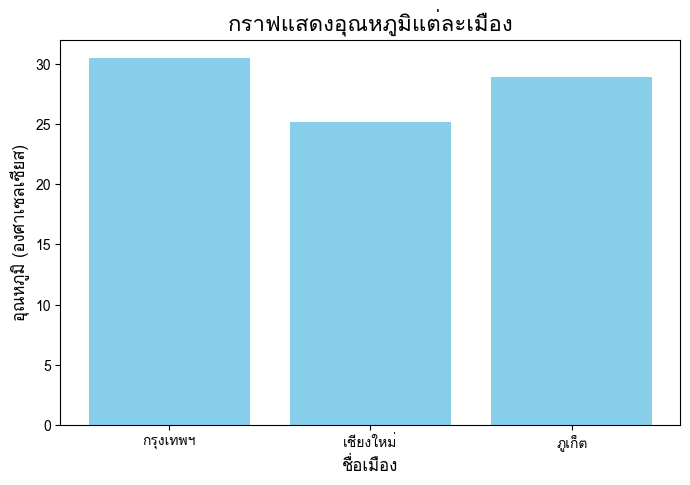

In [1]:
import pandas as pd
import numpy as np
import os, shutil
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 1. ติดตั้งฟอนต์ภาษาไทย
!apt-get -y install fonts-thai-tlwg

# 2. ล้าง cache ของ matplotlib เพื่ออัปเดตฟอนต์ใหม่
cache_dir = matplotlib.get_cachedir()
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)

# 3. ลงทะเบียนฟอนต์ใหม่เข้ากับ FontManager
font_path = '/usr/share/fonts/truetype/tlwg/Loma.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)

# 4. ตั้งค่าฟอนต์หลัก
plt.rcParams['font.family'] = 'Loma'
plt.rcParams['axes.unicode_minus'] = False

# 5. สร้างข้อมูลจำลองและแสดงผล
data = {
    'เมือง': ['กรุงเทพฯ', 'เชียงใหม่', 'ภูเก็ต'],
    'อุณหภูมิ': [30.5, 25.2, 28.9]
}
df_thai = pd.DataFrame(data)

print("ตั้งค่าระบบฟอนต์ภาษาไทยสำเร็จ!")

plt.figure(figsize=(8, 5))
plt.bar(df_thai['เมือง'], df_thai['อุณหภูมิ'], color='skyblue')
plt.title('กราฟแสดงอุณหภูมิแต่ละเมือง', fontsize=16)
plt.xlabel('ชื่อเมือง', fontsize=12)
plt.ylabel('อุณหภูมิ (องศาเซลเซียส)', fontsize=12)
plt.show()

In [2]:
import pandas as pd
import numpy as np

BASE = ("https://raw.githubusercontent.com/PitchayaW/"
        "SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/")

df = pd.read_csv(BASE + "world_weather_sample.csv")
city_info = pd.read_csv(BASE + "city_info.csv")
region_info = pd.read_csv(BASE + "region_info.csv")

print("weather:", df.shape, " city_info:", city_info.shape, " region_info:", region_info.shape)
df.head()

weather: (2075, 10)  city_info: (23, 5)  region_info: (6, 3)


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa
0,983,2025-03-24,New York,USA,North America,15.7,72.6,6.3,15.9,1005.4
1,220,2025-02-09,Tokyo,Japan,Asia,18.3,60.6,0.0,20.5,1015.1
2,1022,2025-02-01,Los Angeles,USA,North America,20.6,46.8,1.2,8.6,1013.5
3,469,2025-01-19,Mumbai,India,Asia,31.0,73.4,8.0,11.8,1000.1
4,1834,2025-02-03,Cape Town,South Africa,Africa,19.1,55.0,0.0,16.6,1015.1


---
## ข้อ 1 การเปรียบเทียบคำสั่งที่มีลักษณะใกล้เคียงกัน

**คำสั่ง:** ให้นักศึกษารันเซลล์โค้ดทั้ง 6 เซลล์ต่อไปนี้ สังเกตผลลัพธ์ที่ได้ แล้วอธิบายกับตนเองให้เข้าใจความแตกต่างของคำสั่งในแต่ละเซลล์ พร้อมระบุว่าในทางปฏิบัติควรเลือกใช้คำสั่งใดในสถานการณ์ใด

การอธิบายควรครอบคลุมทั้ง **ชนิดของผลลัพธ์** **รูปร่างของผลลัพธ์** และ **ความหมายของค่าที่ได้**

In [3]:
# เซลล์ 1.1
s = pd.Series([10, 20, 30], index=["a", "b", "c"])
print(s["a"])
print(s.iloc[0])
print(s[["a", "c"]])

10
10
a    10
c    30
dtype: int64


**เซลล์ 1.1**


*   `s["a"]` ได้ผลลัพธ์เป็น ค่าหนึ่งค่า (scalar) คือ `10` โดยเลือกจาก ชื่อ index หรือ label คือ `"a"`


*   `s.iloc[0]` ได้ผลลัพธ์เป็น ค่าหนึ่งค่า (scalar) คือ `10` เช่นกัน แต่เลือกจาก ตำแหน่ง โดยตำแหน่งแรกคือ 0
*   `s[["a", "c"]]` ได้ผลลัพธ์เป็น Series ที่มี 2 ค่า คือ index `"a"` และ `"c"` ดังนั้นรูปร่างเป็น (2,)

ความแตกต่าง คือ `s["a"]` เลือกข้อมูลโดยใช้ชื่อ index ส่วน iloc เลือกตามตำแหน่ง และการส่งหลาย label ในรูป list จะได้ผลกลับมาเป็น Series ไม่ใช่ค่าเดี่ยว

การเลือกใช้ : ถ้ารู้ชื่อ index ให้เลือกด้วย label เช่น `s["a"]` แต่ถ้าต้องการเลือกตามตำแหน่งให้ใช้ `iloc` และถ้าต้องการหลายค่าให้ส่งรายงานของ label

In [4]:
# เซลล์ 1.2
print(type(df["city"]), df["city"].shape)
print(type(df[["city"]]), df[["city"]].shape)

<class 'pandas.core.series.Series'> (2075,)
<class 'pandas.core.frame.DataFrame'> (2075, 1)


**เซลล์ 1.2**

*   `df["city"]` ได้ผลลัพธ์เป็น series ซึ่งเป็นข้อมูล 1 มิติ รูปรางเป็น `(จำนวนแถว,)`

*   `df[["city"]]` ได้ผลลัพธ์เป็น DataFrame ซึ่งเป็นข้อมูล 2 มิติ รูปร่าง `(จำนวณแถว,1)`

แม้ว่าทั้งสองคำสั่งจะเลือกคอลัมน์ city เหมือนกัน แต่ชนิดและมิติของผลลัพธ์ต่างกัน

การเลือกใช้: ถ้าต้องการนำคอลัมน์เดียวไปคำนวณในลักษณะ Series เช่น `.mean()`, `.value_counts()` หรือเปรียบเทียบค่า ใช้ `df["city"]` ได้สะดวกกว่า แต่ถ้าต้องการให้ผลลัพธ์ยังคงเป็น DataFrame เช่น จะนำไป `merge`, เลือกหลายคอลัมน์ต่อ หรือส่งเข้า pipeline ที่คาดหวังข้อมูล 2 มิติ ให้ใช้ `df[["city"]]`



In [5]:
# เซลล์ 1.3
print(df.loc[0:3].shape)
print(df.iloc[0:3].shape)

(4, 10)
(3, 10)


**เซลล์ 1.3**

ทั้งสองคำสั่งได้ผลลัพธ์เป็น DataFrame แต่จำนวนแถวต่างกัน

*   `df.loc[0:3]` ใช้ label ของ index และรวมค่าปลายทางด้วย ดังนั้นถ้า index เป็น 0,1,2,3 จะได้ทั้งหมด 4 แถว
*  `df.iloc[0:3]` ใช้ ตำแหน่งของแถว และทำงานเหมือน slicing ของ Python คือไม่รวมตำแหน่งสุดท้าย จึงได้ตำแหน่ง 0,1,2 รวม 3 แถว


ดังนั้นรูปร่างจะต่างกันที่จำนวนแถว เช่น ถ้ามีจำนวนคอลัมน์เท่ากัน `loc` จะได้ `(4, จำนวนคอลัมน์)` ส่วน `iloc` ได้ `(3, จำนวนคอลัมน์)`
การเลือกใช้: ใช้ `loc` เมื่อต้องการเลือกข้อมูลตามชื่อ index หรือ label และใช้ `iloc` เมื่อต้องการเลือกตามลำดับตำแหน่งของแถว



In [6]:
# เซลล์ 1.4
print(df.groupby("city")["temperature_c"].count().head(3))
print(df.groupby("city").size().head(3))

city
Auckland    90
Bangkok     91
Beijing     89
Name: temperature_c, dtype: int64
city
Auckland    90
Bangkok     91
Beijing     90
dtype: int64


**เซลล์ 1.4**

ทั้งสองคำสั่งได้ผลลัพธ์เป็น Series โดย index คือชื่อเมือง แต่ค่าที่นับมีความหมายต่างกัน


*  `count()` นับจำนวนค่าของ `temperature_c` ที่ ไม่เป็นค่าว่าง (non-null) ในแต่ละเมือง

*  `size()` นับ จำนวนแถวทั้งหมด ของแต่ละเมือง ไม่สนว่าคอลัมน์ใดจะมีค่าว่างหรือไม่
ถ้า temperature_c ไม่มี missing value ทั้งสองคำสั่งอาจให้ค่าเท่ากัน แต่ถ้ามี missing value ค่า `count()` จะน้อยกว่า `size()`

การเลือกใช้: ถ้าต้องการทราบจำนวนข้อมูลที่มีค่าจริงในคอลัมน์ใดคอลัมน์หนึ่ง ให้ใช้ `count()` แต่ถ้าต้องการนับจำนวน record ทั้งหมดในแต่ละกลุ่ม ให้ใช้ `size()`


In [7]:
# เซลล์ 1.5
print(df.groupby("city")["temperature_c"].mean().head(3))
print(df.groupby("city")[["temperature_c"]].mean().head(3))

city
Auckland    17.804444
Bangkok     32.453846
Beijing     15.598876
Name: temperature_c, dtype: float64
          temperature_c
city                   
Auckland      17.804444
Bangkok       32.453846
Beijing       15.598876


**เซลล์ 1.5**

ทั้งสองคำสั่งคำนวณ ค่าเฉลี่ยอุณหภูมิของแต่ละเมืองเหมือนกัน แต่ชนิดของผลลัพธ์ต่างกัน

*   `["temperature_c"]` หลัง `groupby` ได้ผลลัพธ์เป็น Series จึงมี 1 มิติ
รูปร่างประมาณ `(จำนวนเมือง,)`
*   `[["temperature_c"]]` ได้ผลลัพธ์เป็น DataFrame จึงมี 2 มิติ รูปร่างประมาณ `(จำนวนเมือง, 1)`

ค่าทางตัวเลขที่ได้เหมือนกัน ต่างกันเพียงโครงสร้างข้อมูล

การเลือกใช้: ถ้าต้องการค่าชุดเดียวเพื่อคำนวณต่อแบบ Series ใช้แบบวงเล็บชั้นเดียว แต่ถ้าต้องการรักษาโครงสร้าง DataFrame หรือจะ merge/join ต่อ ให้ใช้วงเล็บสองชั้น

In [8]:
# เซลล์ 1.6
a = pd.Series([1, 2, 3], index=["x", "y", "z"])
b = pd.Series([10, 20, 30], index=["z", "y", "x"])
print(a + b)
print(a.to_numpy() + b.to_numpy())

x    31
y    22
z    13
dtype: int64
[11 22 33]


**เซลล์ 1.6**

*  `x` ของ `a` คือ 1 จะไปบวกกับ `x` ของ `b` คือ 30 → ได้ 31
*  `y` คือ 2 + 20 → ได้ 22
*  `z` คือ 3 + 10 → ได้ 13

แต่ `a.to_numpy() + b.to_numpy()` จะเปลี่ยนข้อมูลเป็น NumPy array ซึ่งไม่มี index label แล้ว จึงบวกตาม ตำแหน่ง
*   ตำแหน่งที่ 1: 1 + 10 = 11
*   ตำแหน่งที่ 2: 2 + 20 = 22
*   ตำแหน่งที่ 3: 3 + 30 = 33

ดังนั้นผลที่ได้มีความหมายต่างกัน แม้จะใช้เครื่องหมาย `+` เหมือนกัน

การเลือกใช้: ถ้าข้อมูลมี index ที่มีความหมายและต้องการให้ค่าที่มี label เดียวกันจับคู่กัน ควรคำนวณด้วย Series โดยตรง แต่ถ้ามั่นใจว่าต้องการคำนวณตามตำแหน่งและไม่ต้องการใช้ index ให้แปลงเป็น NumPy array ก่อน

---
## ข้อ 2 Series และ DataFrame

### ตัวอย่าง

In [9]:
# การสร้าง DataFrame จากโครงสร้างข้อมูลสองรูปแบบ
d1 = pd.DataFrame({"city": ["Bangkok", "Tokyo"], "temp": [30.5, 16.2]})
d2 = pd.DataFrame([{"city": "Bangkok", "temp": 30.5}, {"city": "Tokyo", "temp": 16.2}])
print(d1.equals(d2))

# การเข้าถึงองค์ประกอบของ DataFrame
print(df.columns.tolist())
print(df.index[:5].tolist())
print(df["temperature_c"].nlargest(3).tolist())

True
['record_id', 'date', 'city', 'country', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'pressure_hpa']
[0, 1, 2, 3, 4]
[999.0, 999.0, 999.0]


### โจทย์ 2.1
สร้าง Series ชื่อ `rain_by_city` ซึ่งเก็บปริมาณฝนรวมของแต่ละเมือง โดยกำหนดให้ index เป็นชื่อเมือง จากนั้นตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก
2. สัดส่วนปริมาณฝนของแต่ละเมืองเทียบกับปริมาณฝนรวมทั้งหมด แสดงเป็นร้อยละทศนิยม 2 ตำแหน่ง
3. จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ยของทุกเมือง

In [10]:
# คำตอบข้อ 2.1

rain_by_city = df.groupby("city")["rainfall_mm"].sum()

print("1) เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก")
display(rain_by_city.nlargest(3).rename("total_rain").to_frame())

print("2) สัดส่วนปริมาณฝนของแต่ละเมือง (%)")
rain_pct = (rain_by_city / rain_by_city.sum() * 100).round(2)
display(rain_pct.sort_values(ascending=False).rename("rain_pct").to_frame())

print("3) จำนวนเมืองที่มีฝนรวมสูงกว่าค่าเฉลี่ย:",
      int((rain_by_city > rain_by_city.mean()).sum()))

1) เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก


,total_rain
city,
Singapore,870.4
Bangkok,685.6
Lagos,652.8


2) สัดส่วนปริมาณฝนของแต่ละเมือง (%)


,rain_pct
city,
Singapore,10.43
Bangkok,8.21
Lagos,7.82
Mumbai,5.84
Chiang Mai,5.22
Sao Paulo,5.07
Nairobi,4.74
Tokyo,4.61
Auckland,4.22


3) จำนวนเมืองที่มีฝนรวมสูงกว่าค่าเฉลี่ย: 8


### โจทย์ 2.2
สร้าง DataFrame ชื่อ `city_profile` ที่มีหนึ่งแถวต่อหนึ่งเมือง ประกอบด้วยคอลัมน์
`city`, `country`, `region`, `n_records`, `avg_temp`, `total_rain`
โดยกำหนดให้ใช้ `groupby`

In [11]:
# คำตอบข้อ 2.2

city_profile = (df.groupby("city", as_index=False)
                  .agg(country=("country", "first"),
                       region=("region", "first"),
                       n_records=("city", "size"),
                       avg_temp=("temperature_c", "mean"),
                       total_rain=("rainfall_mm", "sum")))
city_profile["avg_temp"] = city_profile["avg_temp"].round(2)
display(city_profile)


,city,country,region,n_records,avg_temp,total_rain
0,Auckland,New Zealand,Oceania,90,17.80,351.9
1,Bangkok,Thailand,Asia,91,32.45,685.6
2,Beijing,China,Asia,90,15.60,250.1
3,Berlin,Germany,Europe,90,12.38,268.4
4,Buenos Aires,Argentina,South America,90,19.17,305.1
5,Cairo,Egypt,Africa,91,26.09,123.0
6,Cape Town,South Africa,Africa,90,30.16,239.3
7,Chiang Mai,Thailand,Asia,91,29.68,435.6
8,Lagos,Nigeria,Africa,90,29.49,652.8
9,Lima,Peru,South America,90,21.49,180.3


---
## ข้อ 3 การนำเข้าข้อมูลด้วย `read_csv()`

### ตัวอย่าง

In [12]:
# พารามิเตอร์ที่ใช้บ่อย ได้แก่ usecols, nrows, parse_dates, dtype, na_values
preview = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=["city", "date", "temperature_c"],
    parse_dates=["date"],
    nrows=5,
)
print(preview.dtypes)
preview

date             datetime64[ns]
city                     object
temperature_c           float64
dtype: object


,date,city,temperature_c
0,2025-03-24,New York,15.7
1,2025-02-09,Tokyo,18.3
2,2025-02-01,Los Angeles,20.6
3,2025-01-19,Mumbai,31.0
4,2025-02-03,Cape Town,19.1


In [13]:
# การอ่านข้อมูลทีละก้อนด้วย chunksize ซึ่งคืนค่าเป็น iterator
total_rows = 0
for chunk in pd.read_csv(BASE + "world_weather_sample.csv", chunksize=500):
    total_rows += len(chunk)
print("จำนวนแถวรวม:", total_rows)

จำนวนแถวรวม: 2075


### โจทย์ 3.1
เขียนคำสั่ง `pd.read_csv()` เพียงคำสั่งเดียวที่ดำเนินการทุกข้อต่อไปนี้ให้เสร็จสิ้นตั้งแต่ขั้นตอนการนำเข้า

1. อ่านเฉพาะคอลัมน์ `date`, `city`, `region`, `temperature_c`, `humidity_pct`, `rainfall_mm`
2. แปลงคอลัมน์ `date` เป็นชนิด datetime
3. กำหนดให้ค่า `999` และ `-999` ถูกอ่านเป็นค่าว่าง
4. กำหนดชนิดข้อมูลของ `city` และ `region` เป็น `category`
5. กำหนดให้ `city` เป็น index

ให้ตรวจสอบผลด้วย `.dtypes` และ `.info()`

In [14]:
# คำตอบข้อ 3.1

weather_opt = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=["date", "city", "region", "temperature_c", "humidity_pct", "rainfall_mm"],
    parse_dates=["date"],
    na_values=[999, -999],
    dtype={"city": "category", "region": "category"},
    index_col="city"
)
print(weather_opt.dtypes)
weather_opt.info()


date             datetime64[ns]
region                 category
temperature_c           float64
humidity_pct            float64
rainfall_mm             float64
dtype: object
<class 'pandas.core.frame.DataFrame'>
CategoricalIndex: 2075 entries, New York to Paris
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           2075 non-null   datetime64[ns]
 1   region         2075 non-null   category      
 2   temperature_c  2052 non-null   float64       
 3   humidity_pct   1993 non-null   float64       
 4   rainfall_mm    2013 non-null   float64       
dtypes: category(1), datetime64[ns](1), float64(3)
memory usage: 69.8 KB


### โจทย์ 3.2
เปรียบเทียบปริมาณหน่วยความจำที่ใช้ระหว่างตารางที่นำเข้าตามปกติกับตารางจากโจทย์ 3.1 ด้วย `.memory_usage(deep=True)`
รายงานผลเป็นร้อยละที่ลดลง และ **อธิบาย** ว่าคอลัมน์ใดมีผลต่อการลดลงมากที่สุด เพราะเหตุใด

In [15]:
# คำตอบข้อ 3.2

weather_normal = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=["date", "city", "region", "temperature_c", "humidity_pct", "rainfall_mm"]
)

mem_normal = weather_normal.memory_usage(deep=True).sum()
mem_opt = weather_opt.memory_usage(deep=True).sum()
pct_reduced = (1 - mem_opt / mem_normal) * 100

compare_mem = pd.DataFrame({
    "normal_bytes": weather_normal.memory_usage(deep=True),
    "optimized_bytes": weather_opt.reset_index().memory_usage(deep=True)
}).fillna(0)
compare_mem["saved_bytes"] = compare_mem["normal_bytes"] - compare_mem["optimized_bytes"]

print(f"หน่วยความจำเดิม: {mem_normal:,} bytes")
print(f"หน่วยความจำหลังปรับ: {mem_opt:,} bytes")
print(f"ลดลง: {pct_reduced:.2f}%")
display(compare_mem.sort_values("saved_bytes", ascending=False))
print("อธิบาย: คอลัมน์ข้อความ city และ region มีผลต่อการลดหน่วยความจำมาก เพราะ category เก็บค่าที่ซ้ำกันเป็นรหัสหมวดหมู่ แทนการเก็บ string ซ้ำทุกแถว ส่วนการเลือกเฉพาะคอลัมน์ที่จำเป็นก็ช่วยลดหน่วยความจำเพิ่มเติม")


หน่วยความจำเดิม: 406,908 bytes
หน่วยความจำหลังปรับ: 72,917 bytes
ลดลง: 82.08%


,normal_bytes,optimized_bytes,saved_bytes
region,117631,2590,115041
city,116920,3927,112993
date,122425,16600,105825
Index,132,132,0
humidity_pct,16600,16600,0
rainfall_mm,16600,16600,0
temperature_c,16600,16600,0


อธิบาย: คอลัมน์ข้อความ city และ region มีผลต่อการลดหน่วยความจำมาก เพราะ category เก็บค่าที่ซ้ำกันเป็นรหัสหมวดหมู่ แทนการเก็บ string ซ้ำทุกแถว ส่วนการเลือกเฉพาะคอลัมน์ที่จำเป็นก็ช่วยลดหน่วยความจำเพิ่มเติม


### โจทย์ 3.3
ใช้การอ่านข้อมูลแบบ `chunksize` เพื่อคำนวณค่าต่อไปนี้ โดยห้ามโหลดข้อมูลทั้งไฟล์เข้าหน่วยความจำพร้อมกัน และห้ามใช้ `pd.concat`

1. อุณหภูมิสูงสุดและต่ำสุดของทั้งไฟล์
2. อุณหภูมิเฉลี่ยรายเมือง

**อธิบาย:** เหตุใดการนำค่าเฉลี่ยของแต่ละก้อนมาเฉลี่ยกันอีกครั้งจึงให้ผลไม่ถูกต้อง และควรสะสมค่าใดแทนจึงจะได้ผลที่ถูกต้อง

In [16]:
# คำตอบข้อ 3.3

min_temp = np.inf
max_temp = -np.inf
sum_by_city = pd.Series(dtype="float64")
count_by_city = pd.Series(dtype="int64")

for chunk in pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=["city", "temperature_c"],
    na_values=[999, -999],
    chunksize=500
):
    min_temp = min(min_temp, chunk["temperature_c"].min(skipna=True))
    max_temp = max(max_temp, chunk["temperature_c"].max(skipna=True))
    g_sum = chunk.groupby("city")["temperature_c"].sum(min_count=1)
    g_count = chunk.groupby("city")["temperature_c"].count()
    sum_by_city = sum_by_city.add(g_sum, fill_value=0)
    count_by_city = count_by_city.add(g_count, fill_value=0)

avg_by_city_chunk = (sum_by_city / count_by_city).sort_values(ascending=False)
print("อุณหภูมิต่ำสุด:", min_temp)
print("อุณหภูมิสูงสุด:", max_temp)
display(avg_by_city_chunk.rename("avg_temp").to_frame())
print("อธิบาย: ค่าเฉลี่ยของแต่ละ chunk อาจมีจำนวนข้อมูลไม่เท่ากัน จึงนำ mean ของแต่ละ chunk มาเฉลี่ยตรง ๆ ไม่ได้ ต้องสะสมผลรวม (sum) และจำนวนค่าที่ไม่ว่าง (count) ของแต่ละเมือง แล้วคำนวณ sum/count หลังอ่านครบทุก chunk")


อุณหภูมิต่ำสุด: -88.0
อุณหภูมิสูงสุด: 39.2


,avg_temp
city,
Bangkok,32.453846
Mumbai,30.872222
Chiang Mai,29.680220
Lagos,29.494253
Singapore,29.308989
Cairo,26.089888
Sao Paulo,22.841573
Lima,21.490000
Nairobi,21.440000


อธิบาย: ค่าเฉลี่ยของแต่ละ chunk อาจมีจำนวนข้อมูลไม่เท่ากัน จึงนำ mean ของแต่ละ chunk มาเฉลี่ยตรง ๆ ไม่ได้ ต้องสะสมผลรวม (sum) และจำนวนค่าที่ไม่ว่าง (count) ของแต่ละเมือง แล้วคำนวณ sum/count หลังอ่านครบทุก chunk


---
## ข้อ 4 การสำรวจข้อมูลและการตรวจสอบคุณภาพข้อมูล

### ตัวอย่าง

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075 entries, 0 to 2074
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   record_id       2075 non-null   int64  
 1   date            2075 non-null   object 
 2   city            2075 non-null   object 
 3   country         2075 non-null   object 
 4   region          2075 non-null   object 
 5   temperature_c   2055 non-null   float64
 6   humidity_pct    1993 non-null   float64
 7   rainfall_mm     2013 non-null   float64
 8   wind_speed_kmh  2034 non-null   float64
 9   pressure_hpa    2043 non-null   float64
dtypes: float64(5), int64(1), object(4)
memory usage: 162.2+ KB


In [18]:
print(df.describe().round(2))
print(df.describe(include="all").iloc[:4])

       record_id  temperature_c  humidity_pct  rainfall_mm  wind_speed_kmh  \
count    2075.00        2055.00       1993.00      2013.00         2034.00   
mean     1035.15          21.84         66.82         4.15           14.78   
std       598.02          38.22         13.09         3.85            5.88   
min         1.00         -88.00         21.50         0.00           -5.00   
25%       517.50          15.40         58.60         0.30           10.80   
50%      1035.00          20.00         67.10         3.50           15.00   
75%      1553.50          25.70         75.50         6.60           18.70   
max      2070.00         999.00        150.00        17.60           33.70   

       pressure_hpa  
count       2043.00  
mean        1013.13  
std            5.86  
min          993.90  
25%         1009.30  
50%         1013.10  
75%         1017.20  
max         1030.60  
        record_id        date        city   country region  temperature_c  \
count      2075.0     

In [19]:
print(df.isna().sum())
print("จำนวนแถวที่มีค่าว่างอย่างน้อยหนึ่งคอลัมน์:", df.isna().any(axis=1).sum())
print("จำนวนแถวที่ซ้ำกันทุกคอลัมน์:", df.duplicated().sum())

record_id          0
date               0
city               0
country            0
region             0
temperature_c     20
humidity_pct      82
rainfall_mm       62
wind_speed_kmh    41
pressure_hpa      32
dtype: int64
จำนวนแถวที่มีค่าว่างอย่างน้อยหนึ่งคอลัมน์: 229
จำนวนแถวที่ซ้ำกันทุกคอลัมน์: 5


### โจทย์ 4.1
สร้าง DataFrame ชื่อ `summary` ที่มีหนึ่งแถวต่อหนึ่งคอลัมน์ของ `df` ประกอบด้วย
`dtype`, `n_missing`, `pct_missing`, `n_unique`, `example_value`
โดยห้ามใช้การวนซ้ำทีละคอลัมน์ และให้เรียงลำดับจากคอลัมน์ที่มีค่าว่างมากที่สุด

In [20]:
# คำตอบข้อ 4.1

example_value = df.bfill().iloc[0]
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(dropna=True),
    "example_value": example_value
}).sort_values(["n_missing", "pct_missing"], ascending=False)
display(summary)


,dtype,n_missing,pct_missing,n_unique,example_value
humidity_pct,float64,82,3.95,544,72.6
rainfall_mm,float64,62,2.99,164,6.3
wind_speed_kmh,float64,41,1.98,278,15.9
pressure_hpa,float64,32,1.54,294,1005.4
temperature_c,float64,20,0.96,331,15.7
record_id,int64,0,0.00,2070,983
date,object,0,0.00,90,2025-03-24
city,object,0,0.00,23,New York
country,object,0,0.00,28,USA
region,object,0,0.00,6,North America


### โจทย์ 4.2
ผลลัพธ์ของ `.describe()` แสดงค่าสูงสุดของ `temperature_c` และ `humidity_pct` ที่เป็นไปไม่ได้ในทางกายภาพ ให้เขียนโปรแกรมหาค่าต่อไปนี้

1. จำนวนแถวที่ `temperature_c` อยู่นอกช่วง -60 ถึง 60
2. จำนวนแถวที่ `humidity_pct` อยู่นอกช่วง 0 ถึง 100
3. จำนวนแถวที่มีความผิดปกติอย่างน้อยหนึ่งคอลัมน์ โดยระวังการนับซ้ำ

In [21]:
# คำตอบข้อ 4.2

bad_temp = df["temperature_c"].notna() & ~df["temperature_c"].between(-60, 60)
bad_humidity = df["humidity_pct"].notna() & ~df["humidity_pct"].between(0, 100)

print("temperature_c ผิดช่วง:", int(bad_temp.sum()))
print("humidity_pct ผิดช่วง:", int(bad_humidity.sum()))
print("ผิดปกติอย่างน้อยหนึ่งคอลัมน์:", int((bad_temp | bad_humidity).sum()))


temperature_c ผิดช่วง: 5
humidity_pct ผิดช่วง: 3
ผิดปกติอย่างน้อยหนึ่งคอลัมน์: 8


### โจทย์ 4.3
คอลัมน์ `country` มีจำนวนค่าไม่ซ้ำมากกว่าจำนวนประเทศที่มีอยู่จริง เนื่องจากการใช้ตัวพิมพ์ไม่สม่ำเสมอ

1. แสดงว่าค่าใดบ้างที่หมายถึงประเทศเดียวกันแต่ถูกนับแยกจากกัน
2. ทดลองใช้ `df["country"].str.title()` แล้ว **อธิบาย** ว่าวิธีนี้ทำให้ข้อมูลของประเทศใดเสียหาย และเพราะเหตุใด
3. เสนอและเขียนวิธี normalize ที่ถูกต้อง โดยต้องรองรับกรณีที่มีช่องว่างหัวท้ายด้วย

> **การตรวจสอบคำตอบ:** จำนวนประเทศที่ถูกต้องคือ 21 ประเทศ จากทั้งหมด 23 เมือง

In [22]:
# คำตอบข้อ 4.3

raw_country = df["country"].astype("string")
key = raw_country.str.strip().str.casefold()

# 1) แสดงค่าที่ต่างรูปแบบแต่เมื่อ normalize เบื้องต้นแล้วหมายถึงประเทศเดียวกัน
country_variants = (pd.DataFrame({"raw": raw_country, "key": key})
                    .dropna()
                    .drop_duplicates()
                    .groupby("key")["raw"].agg(list))
country_variants = country_variants[country_variants.map(len) > 1]
print("ค่าที่หมายถึงประเทศเดียวกันแต่เขียนต่างกัน")
display(country_variants.to_frame("variants"))

# 2) ตรวจผลของ title()
titled = raw_country.str.strip().str.title()
changed_acronyms = (pd.DataFrame({"original": raw_country.str.strip(), "after_title": titled})
                    .drop_duplicates())
changed_acronyms = changed_acronyms[
    changed_acronyms["original"].str.fullmatch(r"[A-Z]{2,4}", na=False) &
    changed_acronyms["original"].ne(changed_acronyms["after_title"])
]
print("ค่าที่ .str.title() ทำให้รูปแบบ acronym เสียหาย")
display(changed_acronyms)
print("อธิบาย: .str.title() เปลี่ยนตัวย่อที่ควรเป็นตัวพิมพ์ใหญ่ทั้งหมด เช่น USA/UK ให้เป็น Usa/Uk จึงทำให้รูปแบบชื่อประเทศเสียความหมายเชิงมาตรฐาน")

# 3) normalize: ตัดช่องว่าง + ใช้ case-insensitive key + คืนชื่อ canonical
special = {"usa": "USA", "uk": "UK", "uae": "UAE"}
country_clean = key.map(special).fillna(key.str.title())
df["country_clean"] = country_clean
print("จำนวนประเทศหลัง normalize:", df["country_clean"].nunique())
display(df[["country", "country_clean"]].drop_duplicates().sort_values("country_clean"))


ค่าที่หมายถึงประเทศเดียวกันแต่เขียนต่างกัน


,variants
key,
argentina,"[Argentina, ARGENTINA]"
canada,"[Canada, CANADA]"
germany,"[Germany, GERMANY]"
japan,"[Japan, JAPAN]"
kenya,"[Kenya, KENYA]"
new zealand,"[New Zealand, NEW ZEALAND]"
singapore,"[Singapore, SINGAPORE]"


ค่าที่ .str.title() ทำให้รูปแบบ acronym เสียหาย


,original,after_title
0,USA,Usa
44,UK,Uk


อธิบาย: .str.title() เปลี่ยนตัวย่อที่ควรเป็นตัวพิมพ์ใหญ่ทั้งหมด เช่น USA/UK ให้เป็น Usa/Uk จึงทำให้รูปแบบชื่อประเทศเสียความหมายเชิงมาตรฐาน
จำนวนประเทศหลัง normalize: 21


,country,country_clean
1371,ARGENTINA,Argentina
6,Argentina,Argentina
17,Australia,Australia
60,Brazil,Brazil
433,CANADA,Canada
92,Canada,Canada
12,China,China
43,Egypt,Egypt
22,France,France
366,GERMANY,Germany


---
## ข้อ 5 การเลือกข้อมูลด้วย `loc` และ `iloc`

### ตัวอย่าง

In [23]:
# iloc อ้างอิงตามตำแหน่ง ส่วน loc อ้างอิงตาม label และรวมค่าปลายช่วง
print(df.iloc[0:3, 0:3].shape, df.loc[0:3, ["city", "region"]].shape)

# loc ใช้ร่วมกับเงื่อนไขและเลือกคอลัมน์ได้ในคำสั่งเดียว
print(df.loc[df["temperature_c"] > 35, ["city", "date", "temperature_c"]].head(3))

(3, 3) (4, 2)
          city        date  temperature_c
78   Cape Town  2025-02-10          999.0
161    Bangkok  2025-02-14           38.6
325     Mumbai  2025-03-31           35.6


In [24]:
# การกำหนด index หลายระดับ และการเลือกข้อมูลจาก index หลายระดับ
multi = df.set_index(["region", "city"]).sort_index()
print(multi.loc["Asia"].shape)
print(multi.loc[("Asia", "Tokyo"), ["date", "temperature_c"]].head(3))

(542, 9)
                    date  temperature_c
region city                            
Asia   Tokyo  2025-02-09           18.3
       Tokyo  2025-03-21           19.7
       Tokyo  2025-03-23           17.7


### โจทย์ 5.1
ใช้ `.iloc[]` เท่านั้น โดยห้ามอ้างอิงชื่อคอลัมน์ เพื่อดึงข้อมูลต่อไปนี้

1. แถวที่อยู่ในตำแหน่งเลขคู่ 10 แถวแรก เฉพาะสามคอลัมน์สุดท้าย
2. ห้าแถวสุดท้าย โดยเรียงลำดับจากแถวล่างสุดขึ้นไป
3. ค่าเดี่ยวที่อยู่ในแถวกึ่งกลางตารางและคอลัมน์สุดท้าย โดยต้องคำนวณตำแหน่งกึ่งกลางจากจำนวนแถว

In [25]:
# คำตอบข้อ 5.1

# 1) ตำแหน่งเลขคู่ 10 แถวแรก = 0,2,...,18 และสามคอลัมน์สุดท้าย
display(df.iloc[0:20:2, -3:])

# 2) ห้าแถวสุดท้าย เรียงจากล่างสุดขึ้นบน
display(df.iloc[:-6:-1])

# 3) ค่าเดี่ยวแถวกึ่งกลางและคอลัมน์สุดท้าย
middle_pos = len(df) // 2
middle_value = df.iloc[middle_pos, -1]
print("ตำแหน่งกึ่งกลาง:", middle_pos, "ค่า:", middle_value)


,wind_speed_kmh,pressure_hpa,country_clean
0,15.9,1005.4,USA
2,8.6,1013.5,USA
4,16.6,1015.1,South Africa
6,14.6,1018.0,Argentina
8,9.8,1007.7,Argentina
10,15.6,1010.1,Russia
12,13.6,1015.8,China
14,24.6,1000.5,Argentina
16,9.3,1019.4,Argentina
18,23.3,1020.6,Nigeria


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa,country_clean
2074,642,2025-01-12,Paris,France,Europe,11.1,65.8,6.3,20.4,1015.7,France
2073,1210,2025-02-09,Toronto,Canada,North America,NaN,65.0,9.1,6.9,1007.8,Canada
2072,1738,2025-01-28,Nairobi,Kenya,Africa,21.7,51.0,9.5,27.2,1013.9,Kenya
2071,1769,2025-02-28,Nairobi,Kenya,Africa,20.6,65.8,3.7,13.3,1015.6,Kenya
2070,1093,2025-01-13,Mexico City,Mexico,North America,17.8,63.3,7.4,10.5,1001.2,Mexico


ตำแหน่งกึ่งกลาง: 1037 ค่า: Peru


### โจทย์ 5.2
จาก DataFrame ที่กำหนด index เป็นคู่ `(region, city)` ให้ดึงข้อมูลต่อไปนี้ด้วย `.loc[]`

1. ข้อมูลทั้งหมดของภูมิภาค Asia เฉพาะคอลัมน์ `date` และ `temperature_c`
2. ข้อมูลของเมือง Tokyo และ Bangkok พร้อมกันในคำสั่งเดียว
3. ข้อมูลของทุกภูมิภาค แต่เฉพาะเมืองที่ชื่อขึ้นต้นด้วยตัวอักษร B

**อธิบาย:** เหตุใดจึงควรเรียงลำดับ index ด้วย `.sort_index()` ก่อนใช้งาน index หลายระดับ

In [26]:
# คำตอบข้อ 5.2

multi = df.set_index(["region", "city"]).sort_index()

# 1)
asia = multi.loc["Asia", ["date", "temperature_c"]]
display(asia.head())

# 2)
idx = pd.IndexSlice
cities_two = multi.loc[idx[:, ["Tokyo", "Bangkok"]], :]
display(cities_two.head())

# 3)
b_cities = multi.index.get_level_values("city").unique()
b_cities = b_cities[b_cities.str.startswith("B")]
all_b = multi.loc[idx[:, b_cities], :]
display(all_b.head())

print("อธิบาย: MultiIndex ควร sort_index() ก่อน เพราะ pandas สามารถค้นหาและ slice ตามลำดับชั้นได้ถูกต้องและมีประสิทธิภาพกว่า หาก index ไม่เรียง การเลือกแบบช่วงหรือหลายระดับอาจช้า หรือเกิด UnsortedIndexError ได้")


,date,temperature_c
city,,
Bangkok,2025-02-22,30.8
Bangkok,2025-01-10,28.9
Bangkok,2025-01-27,27.9
Bangkok,2025-01-03,29.0
Bangkok,2025-03-28,31.0


record_id        date country  temperature_c  humidity_pct  \
region city                                                                
Asia   Tokyo        220  2025-02-09   Japan           18.3          60.6   
       Tokyo        260  2025-03-21   Japan           19.7          67.4   
       Tokyo        262  2025-03-23   Japan           17.7          60.2   
       Tokyo        203  2025-01-23   Japan           20.8          61.6   
       Tokyo        218  2025-02-07   Japan           19.5          68.2   

              rainfall_mm  wind_speed_kmh  pressure_hpa country_clean  
region city                                                            
Asia   Tokyo          0.0            20.5        1015.1         Japan  
       Tokyo          2.8            16.6        1014.9         Japan  
       Tokyo          4.0            21.5        1015.8         Japan  
       Tokyo         12.3            10.9        1023.4         Japan  
       Tokyo          5.0            13.4        1011.8         Japan

record_id        date   country  temperature_c  humidity_pct  \
region city                                                                    
Asia   Bangkok         53  2025-02-22  Thailand           30.8          74.5   
       Bangkok         10  2025-01-10  Thailand           28.9          71.3   
       Bangkok         27  2025-01-27  Thailand           27.9          75.5   
       Bangkok          3  2025-01-03  Thailand           29.0          71.3   
       Bangkok         87  2025-03-28  Thailand           31.0          58.7   

                rainfall_mm  wind_speed_kmh  pressure_hpa country_clean  
region city                                                              
Asia   Bangkok          0.0             8.9        1011.5      Thailand  
       Bangkok         12.2            17.1        1002.4      Thailand  
       Bangkok          3.8            17.8        1007.5      Thailand  
       Bangkok          9.0             3.5        1002.7      Thailand  
       Bangkok          6.9            19.3        1022.0      Thailand

อธิบาย: MultiIndex ควร sort_index() ก่อน เพราะ pandas สามารถค้นหาและ slice ตามลำดับชั้นได้ถูกต้องและมีประสิทธิภาพกว่า หาก index ไม่เรียง การเลือกแบบช่วงหรือหลายระดับอาจช้า หรือเกิด UnsortedIndexError ได้


### โจทย์ 5.3
ให้รันโปรแกรมต่อไปนี้ แล้วสังเกตผลที่เกิดขึ้นกับ `df`

```python
subset = df[df["city"] == "Bangkok"]
subset["temperature_c"] = 0
```

จากนั้นเขียนโปรแกรมที่ถูกต้องสองรูปแบบ ได้แก่ รูปแบบที่ต้องการแก้ไข `df` จริง และรูปแบบที่ต้องการทำงานกับสำเนาแยกต่างหาก
พร้อมสรุปเป็นแนวปฏิบัติของตนเองความยาว 2 ถึง 3 บรรทัด

In [27]:
# คำตอบข้อ 5.3

# วิธีที่ 1: ต้องการแก้ df จริง ใช้ .loc โดยตรง
mask_bkk = df["city"].eq("Bangkok")
df_edit_demo = df.copy()
df_edit_demo.loc[mask_bkk, "temperature_c"] = 0
print("Bangkok หลังแก้ในสำเนาสำหรับสาธิต:")
print(df_edit_demo.loc[mask_bkk, "temperature_c"].head())

# วิธีที่ 2: ต้องการทำงานกับสำเนาแยกต่างหาก ใช้ .copy()
subset_copy = df.loc[mask_bkk].copy()
subset_copy.loc[:, "temperature_c"] = 0
print("df ต้นฉบับไม่ถูกเปลี่ยน:", not df.loc[mask_bkk, "temperature_c"].eq(0).all())

print("แนวปฏิบัติ: ถ้าต้องการแก้ DataFrame ต้นฉบับจะใช้ df.loc[mask, col] = value โดยตรง หากต้องการชุดข้อมูลย่อยไว้แก้แยก จะสร้างด้วย .copy() ก่อน เพื่อหลีกเลี่ยง chained assignment และ SettingWithCopyWarning")


Bangkok หลังแก้ในสำเนาสำหรับสาธิต:
67     0.0
79     0.0
82     0.0
84     0.0
108    0.0
Name: temperature_c, dtype: float64
df ต้นฉบับไม่ถูกเปลี่ยน: True
แนวปฏิบัติ: ถ้าต้องการแก้ DataFrame ต้นฉบับจะใช้ df.loc[mask, col] = value โดยตรง หากต้องการชุดข้อมูลย่อยไว้แก้แยก จะสร้างด้วย .copy() ก่อน เพื่อหลีกเลี่ยง chained assignment และ SettingWithCopyWarning


---
## ข้อ 6 การกรองข้อมูลด้วยเงื่อนไข

### ตัวอย่าง

In [28]:
# การใช้ตัวดำเนินการ & | ~ ต้องครอบวงเล็บทุกเงื่อนไข
print(len(df[(df["temperature_c"] > 28) & (df["humidity_pct"] > 70)]))
print(len(df[~df["city"].isin(["Bangkok", "Tokyo"])]))
print(len(df[df["temperature_c"].between(20, 30)]))
print(len(df.query("region == 'Asia' and rainfall_mm > 5")))

237
1894
757
295


In [29]:
# where และ mask ไม่ลดจำนวนแถว แต่แทนค่าที่ไม่ตรงเงื่อนไขด้วยค่าที่กำหนด
temp_valid = df["temperature_c"].where(df["temperature_c"].between(-60, 60))
rain_capped = df["rainfall_mm"].mask(df["rainfall_mm"] > 15, 15)
print(temp_valid.isna().sum(), df["temperature_c"].isna().sum())
print(rain_capped.max(), df["rainfall_mm"].max())

25 20
15.0 17.6


In [30]:
# pipe ใช้ต่อขั้นตอนการประมวลผลหลายขั้นให้เป็นลำดับเดียว
def add_flag(data, threshold):
    return data.assign(is_hot=data["temperature_c"] > threshold)

result = (df
          .query("region == 'Asia'")
          .pipe(add_flag, threshold=30)
          .loc[:, ["city", "temperature_c", "is_hot"]])
print(result.head(3))

       city  temperature_c  is_hot
1     Tokyo           18.3   False
3    Mumbai           31.0    True
12  Beijing           14.3   False


### โจทย์ 6.1
เขียนเงื่อนไขสำหรับกรองข้อมูลต่อไปนี้

1. ข้อมูลในภูมิภาคเอเชียที่ปริมาณฝนมากกว่า 5 มิลลิเมตร และความเร็วลมมากกว่า 20 กิโลเมตรต่อชั่วโมง
2. ข้อมูลที่ไม่ใช่เมือง Bangkok, Tokyo และ London และมีความชื้นระหว่าง 40 ถึง 60
3. แถวที่มีค่าว่างตั้งแต่ 2 คอลัมน์ขึ้นไป
4. แถวที่ชื่อเมืองมีคำว่า New หรือ San ประกอบอยู่ โดยใช้ `.str.contains` ร่วมกับ regular expression

In [31]:
# คำตอบข้อ 6.1

q1 = df[(df["region"] == "Asia") & (df["rainfall_mm"] > 5) & (df["wind_speed_kmh"] > 20)]
q2 = df[~df["city"].isin(["Bangkok", "Tokyo", "London"]) & df["humidity_pct"].between(40, 60)]
q3 = df[df.isna().sum(axis=1) >= 2]
q4 = df[df["city"].str.contains(r"New|San", case=False, na=False, regex=True)]

print("1)", q1.shape); display(q1.head())
print("2)", q2.shape); display(q2.head())
print("3)", q3.shape); display(q3.head())
print("4)", q4.shape); display(q4.head())


1) (54, 11)


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa,country_clean
38,517,2025-03-08,Mumbai,India,Asia,32.6,73.1,5.8,22.3,1019.6,India
49,525,2025-03-16,Mumbai,India,Asia,33.6,76.3,6.3,23.5,1015.5,India
178,51,2025-02-20,Bangkok,Thailand,Asia,29.9,82.3,16.5,21.2,1003.9,Thailand
234,330,2025-03-01,Singapore,Singapore,Asia,32.5,78.5,12.9,22.1,1028.5,Singapore
286,465,2025-01-15,Mumbai,India,Asia,30.1,76.2,7.8,25.0,1013.0,India


2) (470, 11)


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa,country_clean
2,1022,2025-02-01,Los Angeles,USA,North America,20.6,46.8,1.2,8.6,1013.5,USA
4,1834,2025-02-03,Cape Town,South Africa,Africa,19.1,55.0,0.0,16.6,1015.1,South Africa
8,1382,2025-02-01,Buenos Aires,Argentina,South America,20.8,58.7,1.6,9.8,1007.7,Argentina
11,1776,2025-03-07,Nairobi,Kenya,Africa,21.8,57.8,0.0,18.4,1009.1,Kenya
15,863,2025-02-22,Moscow,Russia,Europe,8.3,54.0,4.0,17.3,1010.5,Russia


3) (8, 11)


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa,country_clean
43,1582,2025-02-21,Cairo,Egypt,Africa,NaN,45.7,NaN,19.6,1017.7,Egypt
420,1943,2025-02-22,Sydney,Australia,Oceania,18.5,70.4,0.0,NaN,NaN,Australia
438,1684,2025-03-05,Lagos,Nigeria,Africa,31.3,NaN,7.4,NaN,1009.9,Nigeria
1315,349,2025-03-20,Singapore,Singapore,Asia,31.7,78.6,9.3,NaN,NaN,Singapore
1491,514,2025-03-05,Mumbai,India,Asia,30.5,NaN,8.6,NaN,1011.6,India


4) (90, 11)


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa,country_clean
0,983,2025-03-24,New York,USA,North America,15.7,72.6,6.3,15.9,1005.4,USA
47,979,2025-03-20,New York,USA,North America,14.9,52.2,0.7,14.3,1006.6,USA
63,917,2025-01-17,New York,USA,North America,14.7,54.1,3.0,19.7,1011.9,USA
98,960,2025-03-01,New York,USA,North America,13.3,65.9,0.0,2.7,1017.4,USA
123,908,2025-01-08,New York,USA,North America,12.0,63.7,1.8,13.7,1017.6,USA


### โจทย์ 6.2
ใช้ `.where()` และ `.mask()` สร้างคอลัมน์ใหม่สองคอลัมน์ ได้แก่ คอลัมน์อุณหภูมิที่แทนค่าผิดปกติด้วยค่าว่าง และคอลัมน์ปริมาณฝนที่จำกัดค่าสูงสุดไว้ที่ค่าเปอร์เซ็นไทล์ที่ 99
**อธิบาย:** แนวทางนี้แตกต่างจากการลบแถวทิ้งอย่างไรในแง่ของการวิเคราะห์ในขั้นถัดไป

In [32]:
# คำตอบข้อ 6.2

df["temperature_valid"] = df["temperature_c"].where(df["temperature_c"].between(-60, 60))
rain_p99 = df["rainfall_mm"].quantile(0.99)
df["rainfall_capped"] = df["rainfall_mm"].mask(df["rainfall_mm"] > rain_p99, rain_p99)

print("ค่าว่าง temperature ก่อน/หลัง:", df["temperature_c"].isna().sum(), df["temperature_valid"].isna().sum())
print("rainfall p99:", rain_p99, "max หลัง cap:", df["rainfall_capped"].max())
print("อธิบาย: where/mask รักษาจำนวนแถวและข้อมูลคอลัมน์อื่นไว้ ทำให้วิเคราะห์ตัวแปรอื่นหรือเติมค่าในภายหลังได้ ส่วนการลบแถวทิ้งจะทำให้ข้อมูลทั้งแถวหาย และอาจลดขนาดตัวอย่างหรือทำให้การกระจายของข้อมูลเกิดอคติ")


ค่าว่าง temperature ก่อน/หลัง: 20 25
rainfall p99: 14.687999999999988 max หลัง cap: 14.687999999999988
อธิบาย: where/mask รักษาจำนวนแถวและข้อมูลคอลัมน์อื่นไว้ ทำให้วิเคราะห์ตัวแปรอื่นหรือเติมค่าในภายหลังได้ ส่วนการลบแถวทิ้งจะทำให้ข้อมูลทั้งแถวหาย และอาจลดขนาดตัวอย่างหรือทำให้การกระจายของข้อมูลเกิดอคติ


### โจทย์ 6.3
หาวันที่มีอุณหภูมิห่างจากค่าเฉลี่ยของเมืองตนเองมากที่สุดของแต่ละเมือง
ผลลัพธ์ต้องมีหนึ่งแถวต่อหนึ่งเมือง ประกอบด้วยคอลัมน์ `city`, `date`, `temperature_c`, `deviation`

In [33]:
# คำตอบข้อ 6.3

city_mean = df.groupby("city")["temperature_c"].transform("mean")
dev = (df["temperature_c"] - city_mean).abs()
idx_max_dev = dev.groupby(df["city"]).idxmax()

most_deviated = (df.loc[idx_max_dev, ["city", "date", "temperature_c"]]
                   .assign(deviation=dev.loc[idx_max_dev].to_numpy())
                   .sort_values("city")
                   .reset_index(drop=True))
display(most_deviated)


,city,date,temperature_c,deviation
0,Auckland,2025-02-27,25.6,7.795556
1,Bangkok,2025-03-26,39.1,6.646154
2,Beijing,2025-03-06,22.6,7.001124
3,Berlin,2025-03-26,19.4,7.016854
4,Buenos Aires,2025-01-19,-88.0,107.171910
5,Cairo,2025-03-31,33.6,7.510112
6,Cape Town,2025-02-10,999.0,968.837079
7,Chiang Mai,2025-03-28,37.3,7.619780
8,Lagos,2025-01-01,21.1,8.394253
9,Lima,2025-01-22,12.9,8.590000


---
## ข้อ 7 การจัดการข้อมูลวันที่และเวลา

### ตัวอย่าง

In [34]:
df["date"] = pd.to_datetime(df["date"])
print(df["date"].dt.month.head(3).tolist())
print(df["date"].dt.day_name().head(3).tolist())
print(df["date"].min(), df["date"].max())

# assign ใช้สร้างหลายคอลัมน์ในคำสั่งเดียวและคืนค่าเป็น DataFrame ใหม่
tmp = df.assign(
    year_month=df["date"].dt.to_period("M").astype(str),
    is_weekend=df["date"].dt.dayofweek >= 5,
)
print(tmp[["date", "year_month", "is_weekend"]].head(3))

[3, 2, 2]
['Monday', 'Sunday', 'Saturday']
2025-01-01 00:00:00 2025-03-31 00:00:00
        date year_month  is_weekend
0 2025-03-24    2025-03       False
1 2025-02-09    2025-02        True
2 2025-02-01    2025-02        True


In [35]:
# resample สรุปข้อมูลตามช่วงเวลา โดยต้องกำหนด index เป็น datetime ก่อน
bkk = df[df["city"] == "Bangkok"].set_index("date").sort_index()
print(bkk["temperature_c"].resample("7D").mean().head(4).round(2))

date
2025-01-01    30.36
2025-01-08    31.09
2025-01-15    30.39
2025-01-22    32.29
Freq: 7D, Name: temperature_c, dtype: float64


### โจทย์ 7.1
ใช้ `.assign()` เพียงคำสั่งเดียวสร้างคอลัมน์ `year_month`, `week_of_year`, `day_name` และ `is_weekend`

In [36]:
# คำตอบข้อ 7.1

df = df.assign(
    year_month=df["date"].dt.to_period("M").astype(str),
    week_of_year=df["date"].dt.isocalendar().week.astype("Int64"),
    day_name=df["date"].dt.day_name(),
    is_weekend=df["date"].dt.dayofweek >= 5
)
display(df[["date", "year_month", "week_of_year", "day_name", "is_weekend"]].head())


,date,year_month,week_of_year,day_name,is_weekend
0,2025-03-24,2025-03,13,Monday,False
1,2025-02-09,2025-02,6,Sunday,True
2,2025-02-01,2025-02,5,Saturday,True
3,2025-01-19,2025-01,3,Sunday,True
4,2025-02-03,2025-02,6,Monday,False


### โจทย์ 7.2
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. ข้อมูลครอบคลุมทั้งหมดกี่วัน และมีวันใดในช่วงดังกล่าวที่ไม่มีข้อมูลเลยหรือไม่ โดยใช้ `pd.date_range` ประกอบการตรวจสอบ
2. อุณหภูมิเฉลี่ยของวันหยุดสุดสัปดาห์เปรียบเทียบกับวันธรรมดา จำแนกตามภูมิภาค
3. เดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง

In [37]:
# คำตอบข้อ 7.2

# 1)
full_dates = pd.date_range(df["date"].min(), df["date"].max(), freq="D")
observed_dates = pd.DatetimeIndex(df["date"].dropna().unique())
missing_dates = full_dates.difference(observed_dates)
print("ช่วงข้อมูลทั้งหมด:", len(full_dates), "วัน")
print("วันที่ไม่มีข้อมูลเลย:", missing_dates.tolist())

# 2)
weekend_compare = (df.groupby(["region", "is_weekend"])["temperature_c"].mean()
                     .unstack()
                     .rename(columns={False: "weekday_avg", True: "weekend_avg"})
                     .round(2))
display(weekend_compare)

# 3)
monthly_rain = df.groupby(["city", df["date"].dt.month.rename("month")])["rainfall_mm"].sum()
best_idx = monthly_rain.groupby(level="city").idxmax()
wettest_month = monthly_rain.loc[best_idx].rename("total_rain").reset_index()
display(wettest_month)


ช่วงข้อมูลทั้งหมด: 90 วัน
วันที่ไม่มีข้อมูลเลย: []


is_weekend,weekday_avg,weekend_avg
region,,
Africa,27.94,23.88
Asia,28.49,26.53
Europe,15.82,11.95
North America,16.72,16.84
Oceania,18.94,19.40
South America,21.70,19.84


,city,month,total_rain
0,Auckland,3,150.0
1,Bangkok,2,243.9
2,Beijing,2,87.4
3,Berlin,3,100.1
4,Buenos Aires,2,121.2
5,Cairo,2,48.0
6,Cape Town,1,98.3
7,Chiang Mai,3,188.0
8,Lagos,3,233.0
9,Lima,1,88.0


### โจทย์ 7.3
ใช้ `.resample()` สรุปข้อมูลของเมือง Bangkok เป็นราย 7 วัน โดยแสดงอุณหภูมิเฉลี่ยและปริมาณฝนรวมในตารางเดียวกัน
**อธิบาย:** `.resample()` แตกต่างจาก `groupby(df["date"].dt.month)` อย่างไร และกรณีใดที่จำเป็นต้องใช้ `.resample()` เท่านั้น

In [38]:
# คำตอบข้อ 7.3

bkk_7d = (df[df["city"] == "Bangkok"]
          .set_index("date")
          .sort_index()
          .resample("7D")
          .agg(avg_temp=("temperature_c", "mean"), total_rain=("rainfall_mm", "sum"))
          .round(2))
display(bkk_7d)
print("อธิบาย: resample แบ่งข้อมูลตามช่วงเวลาจริงบน DatetimeIndex เช่น ทุก 7 วัน ทุกสัปดาห์ หรือทุกชั่วโมง และรักษาลำดับเวลา ส่วน groupby(date.dt.month) เพียงรวมค่าที่มีหมายเลขเดือนเดียวกัน โดยไม่สร้างช่วงเวลาต่อเนื่อง ดังนั้นงาน time-series ที่ต้องใช้หน้าต่างเวลาคงที่/ความถี่เฉพาะ เช่น ทุก 7 วัน ต้องใช้ resample")


,avg_temp,total_rain
date,,
2025-01-01,30.36,65.7
2025-01-08,31.09,47.6
2025-01-15,30.39,58.7
2025-01-22,32.29,50.0
2025-01-29,31.76,55.4
2025-02-05,33.03,65.1
2025-02-12,34.21,60.2
2025-02-19,32.30,42.5
2025-02-26,32.34,61.7


อธิบาย: resample แบ่งข้อมูลตามช่วงเวลาจริงบน DatetimeIndex เช่น ทุก 7 วัน ทุกสัปดาห์ หรือทุกชั่วโมง และรักษาลำดับเวลา ส่วน groupby(date.dt.month) เพียงรวมค่าที่มีหมายเลขเดือนเดียวกัน โดยไม่สร้างช่วงเวลาต่อเนื่อง ดังนั้นงาน time-series ที่ต้องใช้หน้าต่างเวลาคงที่/ความถี่เฉพาะ เช่น ทุก 7 วัน ต้องใช้ resample


---
## ข้อ 8 การจัดการค่าว่างและข้อมูลซ้ำ

### ตัวอย่าง

In [39]:
# การเติมค่าว่างด้วยค่าสถิติของกลุ่มตนเอง โดยใช้ transform
filled_by_city = df["temperature_c"].fillna(
    df.groupby("city")["temperature_c"].transform("mean")
)
print(df["temperature_c"].isna().sum(), "->", filled_by_city.isna().sum())

# การเติมค่าด้วยค่าของวันก่อนหน้าภายในเมืองเดียวกัน
sorted_df = df.sort_values(["city", "date"])
ffilled = sorted_df.groupby("city")["temperature_c"].ffill()
print("หลังเติมแบบ ffill เหลือค่าว่าง:", ffilled.isna().sum())

20 -> 0
หลังเติมแบบ ffill เหลือค่าว่าง: 0


In [40]:
# การตรวจสอบข้อมูลซ้ำตามคีย์ที่กำหนด
print("ซ้ำทุกคอลัมน์:", df.duplicated().sum())
print("ซ้ำตามคีย์ (city, date):", df.duplicated(subset=["city", "date"]).sum())
print("จำนวนแถวหลังขจัดข้อมูลซ้ำ:", df.drop_duplicates().shape[0])

ซ้ำทุกคอลัมน์: 5
ซ้ำตามคีย์ (city, date): 5
จำนวนแถวหลังขจัดข้อมูลซ้ำ: 2070


### โจทย์ 8.1
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. คอลัมน์ใดมีค่าว่างมากที่สุด และคิดเป็นร้อยละเท่าใด
2. ค่าว่างกระจายตัวเท่ากันทุกเมืองหรือไม่ ให้สร้างตารางแสดงสัดส่วนค่าว่างของ `temperature_c` จำแนกตามเมือง
3. หากลบทุกแถวที่มีค่าว่างด้วย `dropna()` จะเหลือข้อมูลคิดเป็นร้อยละเท่าใดของข้อมูลเดิม และเมืองใดสูญเสียข้อมูลมากที่สุด

In [41]:
# คำตอบข้อ 8.1

# 1)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print("คอลัมน์ที่ว่างมากที่สุด:", missing_pct.index[0], f"{missing_pct.iloc[0]:.2f}%")

# 2)
city_temp_missing = (df["temperature_c"].isna()
                     .groupby(df["city"])
                     .mean().mul(100)
                     .sort_values(ascending=False)
                     .round(2))
display(city_temp_missing.rename("pct_missing_temperature").to_frame())

# 3)
complete = df.dropna()
remain_pct = len(complete) / len(df) * 100
before = df.groupby("city").size()
after = complete.groupby("city").size().reindex(before.index, fill_value=0)
loss_pct = ((before - after) / before * 100).sort_values(ascending=False)
print(f"หลัง dropna() เหลือ {remain_pct:.2f}% ของข้อมูลเดิม")
print("เมืองที่สูญเสียข้อมูลมากที่สุด:", loss_pct.index[0], f"{loss_pct.iloc[0]:.2f}%")
display(loss_pct.rename("pct_rows_lost").to_frame())


คอลัมน์ที่ว่างมากที่สุด: humidity_pct 3.95%


,pct_missing_temperature
city,
Lagos,3.33
London,2.22
Toronto,2.22
Tokyo,2.22
Cairo,2.20
Berlin,1.11
Beijing,1.11
Paris,1.11
Sao Paulo,1.11


หลัง dropna() เหลือ 88.72% ของข้อมูลเดิม
เมืองที่สูญเสียข้อมูลมากที่สุด: Auckland 15.56%


,pct_rows_lost
city,
Auckland,15.555556
London,14.444444
Bangkok,14.285714
Lagos,13.333333
Tokyo,13.333333
Cape Town,12.222222
Buenos Aires,12.222222
New York,12.222222
Los Angeles,12.222222


### โจทย์ 8.2
เติมค่าว่างของ `temperature_c` ด้วยสามวิธี ได้แก่ ค่าเฉลี่ยรวมทั้งตาราง ค่าเฉลี่ยของเมืองตนเอง และค่าของวันก่อนหน้าภายในเมืองเดียวกัน
จากนั้นเปรียบเทียบผลกระทบต่อค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐานรายเมืองในรูปตารางเดียว

**อธิบาย:** วิธีใดเหมาะสมที่สุดกับข้อมูลชุดนี้ และวิธีใดทำให้ความแปรปรวนของข้อมูลลดลงอย่างผิดธรรมชาติ

In [42]:
# คำตอบข้อ 8.2

base = df[["city", "temperature_c"]].copy()
base["global_mean"] = df["temperature_c"].fillna(df["temperature_c"].mean())
base["city_mean"] = df["temperature_c"].fillna(df.groupby("city")["temperature_c"].transform("mean"))

ff = (df.sort_values(["city", "date"])
        .groupby("city")["temperature_c"].ffill())
base["ffill"] = ff.reindex(df.index)
# ถ้าวันแรกของเมืองยังว่าง ให้ fallback เป็นค่าเฉลี่ยของเมือง
base["ffill"] = base["ffill"].fillna(df.groupby("city")["temperature_c"].transform("mean"))

comparison = pd.concat({
    "original": base.groupby("city")["temperature_c"].agg(["mean", "std"]),
    "global_mean": base.groupby("city")["global_mean"].agg(["mean", "std"]),
    "city_mean": base.groupby("city")["city_mean"].agg(["mean", "std"]),
    "ffill": base.groupby("city")["ffill"].agg(["mean", "std"]),
}, axis=1).round(3)
display(comparison)
print("อธิบาย: สำหรับข้อมูลรายวันภายในเมือง การเติมด้วยค่าของเมืองตนเองหรือค่าก่อนหน้าภายในเมืองเหมาะกว่าค่าเฉลี่ยรวม เพราะรักษาความแตกต่างระหว่างเมืองได้ ค่าเฉลี่ย (โดยเฉพาะ global mean) มักดึงค่าที่หายไปเข้าใกล้ค่ากลางและทำให้ส่วนเบี่ยงเบนมาตรฐานลดลงอย่างผิดธรรมชาติ ส่วน ffill เหมาะเมื่อข้อมูลมีความต่อเนื่องตามเวลา แต่ควรระวังช่องว่างที่ยาวเกินไป")


original          global_mean          city_mean           \
                 mean      std        mean      std      mean      std   
city                                                                     
Auckland       17.804    2.799      17.804    2.799    17.804    2.799   
Bangkok        32.454    2.481      32.454    2.481    32.454    2.481   
Beijing        15.599    2.875      15.668    2.933    15.599    2.859   
Berlin         12.383    2.596      12.488    2.767    12.383    2.581   
Buenos Aires   19.172   11.818      19.202   11.755    19.172   11.751   
Cairo          26.090    2.734      25.996    2.775    26.090    2.703   
Cape Town      30.163  103.899      30.070  103.318    30.163  103.314   
Chiang Mai     29.680    2.858      29.680    2.858    29.680    2.858   
Lagos          29.494    2.838      29.239    3.114    29.494    2.790   
Lima           21.490    3.112      21.490    3.112    21.490    3.112   
London         13.491    3.018      13.676    3.230    13.491    2.984   
Los Angeles    20.657    3.016      20.670    3.001    20.657    2.999   
Mexico City    19.188    2.740      19.188    2.740    19.188    2.740   
Moscow          7.233    2.888       7.394    3.254     7.233    2.872   
Mumbai         30.872    2.545      30.872    2.545    30.872    2.545   
Nairobi        21.440    2.839      21.444    2.823    21.440    2.823   
New York       15.477    3.017      15.477    3.017    15.477    3.017   
Paris          25.811  104.374      25.767  103.786    25.811  103.786   
Sao Paulo      22.842    2.787      22.830    2.773    22.842    2.771   
Singapore      40.083  103.011      40.083  103.011    40.083  103.011   
Sydney         20.348    2.820      20.348    2.820    20.348    2.820   
Tokyo          18.415    2.518      18.491    2.541    18.415    2.490   
Toronto        11.614    2.710      11.841    3.079    11.614    2.680   

               ffill           
                mean      std  
city                           
Auckland      17.804    2.799  
Bangkok       32.454    2.481  
Beijing       15.624    2.869  
Berlin        12.342    2.610  
Buenos Aires  19.141   11.755  
Cairo         25.982    2.803  
Cape Town     30.023  103.322  
Chiang Mai    29.680    2.858  
Lagos         29.517    2.798  
Lima          21.490    3.112  
London        13.502    2.987  
Los Angeles   20.657    2.999  
Mexico City   19.188    2.740  
Moscow         7.262    2.884  
Mumbai        30.872    2.545  
Nairobi       21.460    2.829  
New York      15.477    3.017  
Paris         25.718  103.789  
Sao Paulo     22.801    2.798  
Singapore     40.083  103.011  
Sydney        20.348    2.820  
Tokyo         18.357    2.522  
Toronto       11.598    2.719

อธิบาย: สำหรับข้อมูลรายวันภายในเมือง การเติมด้วยค่าของเมืองตนเองหรือค่าก่อนหน้าภายในเมืองเหมาะกว่าค่าเฉลี่ยรวม เพราะรักษาความแตกต่างระหว่างเมืองได้ ค่าเฉลี่ย (โดยเฉพาะ global mean) มักดึงค่าที่หายไปเข้าใกล้ค่ากลางและทำให้ส่วนเบี่ยงเบนมาตรฐานลดลงอย่างผิดธรรมชาติ ส่วน ffill เหมาะเมื่อข้อมูลมีความต่อเนื่องตามเวลา แต่ควรระวังช่องว่างที่ยาวเกินไป


### โจทย์ 8.3
ข้อมูลชุดนี้ควรมีหนึ่งแถวต่อหนึ่งเมืองต่อหนึ่งวัน ให้ตรวจสอบว่าเป็นจริงหรือไม่

1. มีคู่ `(city, date)` ที่ซ้ำกันจำนวนกี่คู่
2. แถวที่ซ้ำเป็นการซ้ำทุกคอลัมน์ หรือซ้ำเฉพาะคีย์แต่ค่าที่วัดได้ต่างกัน ให้แสดงหลักฐานประกอบ
3. เขียนโปรแกรมขจัดข้อมูลซ้ำ พร้อมระบุนโยบายที่เลือกใช้ แล้วตรวจสอบว่าจำนวนแถวที่เหลือเท่ากับจำนวนเมืองคูณจำนวนวัน

> **การตรวจสอบคำตอบ:** หลังขจัดข้อมูลซ้ำต้องเหลือ 2070 แถว ซึ่งเท่ากับ 23 เมือง คูณ 90 วัน

In [43]:
# คำตอบข้อ 8.3


key_dups = df[df.duplicated(["city", "date"], keep=False)]
n_dup_pairs = key_dups[["city", "date"]].drop_duplicates().shape[0]
exact_dup_rows = df.duplicated(keep=False).sum()
print("จำนวนคู่ (city, date) ที่ซ้ำ:", n_dup_pairs)
print("จำนวนแถวที่เป็น duplicate ทุกคอลัมน์ (นับทั้งต้นฉบับและสำเนา):", int(exact_dup_rows))

print("ตัวอย่างแถวที่คีย์ซ้ำ")
display(key_dups.sort_values(["city", "date"]).head(20))

# นโยบาย: หนึ่งเมืองต่อหนึ่งวัน เก็บแถวแรกหลังเรียงลำดับ
# ถ้าพบค่าที่ต่างกันจริง ควรตรวจสอบแหล่งข้อมูลก่อน แต่สำหรับชุดฝึกนี้ใช้ keep='first'
df_dedup = (df.sort_values(["city", "date"])
              .drop_duplicates(subset=["city", "date"], keep="first")
              .copy())
expected = df_dedup["city"].nunique() * df_dedup["date"].nunique()
print("จำนวนแถวหลังขจัดซ้ำ:", len(df_dedup))
print("จำนวนเมือง x จำนวนวัน:", expected)
print("คีย์ยังซ้ำหรือไม่:", df_dedup.duplicated(["city", "date"]).any())


จำนวนคู่ (city, date) ที่ซ้ำ: 5
จำนวนแถวที่เป็น duplicate ทุกคอลัมน์ (นับทั้งต้นฉบับและสำเนา): 10
ตัวอย่างแถวที่คีย์ซ้ำ


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa,country_clean,temperature_valid,rainfall_capped,year_month,week_of_year,day_name,is_weekend
507,62,2025-03-03,Bangkok,Thailand,Asia,33.8,85.2,5.6,18.3,NaN,Thailand,33.8,5.6,2025-03,10,Monday,False
1304,62,2025-03-03,Bangkok,Thailand,Asia,33.8,85.2,5.6,18.3,NaN,Thailand,33.8,5.6,2025-03,10,Monday,False
1392,1586,2025-02-25,Cairo,Egypt,Africa,27.8,37.8,0.6,16.9,1004.1,Egypt,27.8,0.6,2025-02,9,Tuesday,False
1517,1586,2025-02-25,Cairo,Egypt,Africa,27.8,37.8,0.6,16.9,1004.1,Egypt,27.8,0.6,2025-02,9,Tuesday,False
569,155,2025-03-06,Chiang Mai,Thailand,Asia,32.4,60.5,7.5,20.8,1016.7,Thailand,32.4,7.5,2025-03,10,Thursday,False
1777,155,2025-03-06,Chiang Mai,Thailand,Asia,32.4,60.5,7.5,20.8,1016.7,Thailand,32.4,7.5,2025-03,10,Thursday,False
566,882,2025-03-13,Moscow,Russia,Europe,10.9,67.1,0.5,18.2,1018.3,Russia,10.9,0.5,2025-03,11,Thursday,False
1077,882,2025-03-13,Moscow,Russia,Europe,10.9,67.1,0.5,18.2,1018.3,Russia,10.9,0.5,2025-03,11,Thursday,False
1948,1764,2025-02-23,Nairobi,Kenya,Africa,22.4,57.9,4.3,17.9,1014.6,Kenya,22.4,4.3,2025-02,8,Sunday,True
2010,1764,2025-02-23,Nairobi,Kenya,Africa,22.4,57.9,4.3,17.9,1014.6,Kenya,22.4,4.3,2025-02,8,Sunday,True


จำนวนแถวหลังขจัดซ้ำ: 2070
จำนวนเมือง x จำนวนวัน: 2070
คีย์ยังซ้ำหรือไม่: False


---
## ข้อ 9 การสรุปข้อมูลด้วย `groupby()` และ `agg()`

ตั้งแต่ข้อนี้เป็นต้นไป ให้ใช้ตารางที่ขจัดข้อมูลซ้ำแล้วเป็นข้อมูลตั้งต้น

In [44]:
df = df.drop_duplicates().copy()
df["month"] = df["date"].dt.month
print(df.shape)

(2070, 18)


### ตัวอย่าง

In [45]:
# named aggregation ช่วยให้กำหนดชื่อคอลัมน์ผลลัพธ์ได้โดยตรง
summary = df.groupby("city").agg(
    avg_temp=("temperature_c", "mean"),
    total_rain=("rainfall_mm", "sum"),
    max_wind=("wind_speed_kmh", "max"),
    n_days=("temperature_c", "count"),
)
print(summary.head(3).round(2))

# การใช้ฟังก์ชันที่นิยามเองภายใน agg
heavy = df.groupby("city").agg(
    heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()),
)
print(heavy.head(3))

          avg_temp  total_rain  max_wind  n_days
city                                            
Auckland     17.80       351.9      26.0      90
Bangkok      32.44       680.0      29.8      90
Beijing      15.60       250.1      27.6      89
          heavy_rain_days
city                     
Auckland                6
Bangkok                23
Beijing                 2


### โจทย์ 9.1
สร้างตารางสรุปรายเมืองในคำสั่ง `agg()` เดียว ประกอบด้วยคอลัมน์ต่อไปนี้

| คอลัมน์ | ความหมาย |
|---|---|
| `avg_temp`, `median_temp`, `std_temp` | สถิติของอุณหภูมิ |
| `total_rain` | ปริมาณฝนรวม |
| `heavy_rain_days` | จำนวนวันที่ฝนมากกว่า 10 มิลลิเมตร |
| `pct_missing_temp` | สัดส่วนวันที่อุณหภูมิเป็นค่าว่าง |

In [46]:
# คำตอบข้อ 9.1

city_summary = df.groupby("city").agg(
    avg_temp=("temperature_c", "mean"),
    median_temp=("temperature_c", "median"),
    std_temp=("temperature_c", "std"),
    total_rain=("rainfall_mm", "sum"),
    heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()),
    pct_missing_temp=("temperature_c", lambda s: s.isna().mean() * 100)
).round(2)
display(city_summary)


,avg_temp,median_temp,std_temp,total_rain,heavy_rain_days,pct_missing_temp
city,,,,,,
Auckland,17.80,17.55,2.80,351.9,6,0.00
Bangkok,32.44,32.50,2.49,680.0,23,0.00
Beijing,15.60,15.50,2.87,250.1,2,1.11
Berlin,12.38,12.30,2.60,268.4,6,1.11
Buenos Aires,19.17,20.70,11.82,305.1,9,1.11
Cairo,26.07,25.80,2.74,122.4,1,2.22
Cape Town,30.16,18.90,103.90,239.3,0,1.11
Chiang Mai,29.65,29.50,2.86,428.1,9,0.00
Lagos,29.49,29.80,2.84,652.8,22,3.33


### โจทย์ 9.2
สร้างตารางสรุปที่จำแนกตาม `region` และ `month` พร้อมกัน แล้วจัดรูปผลลัพธ์ให้เป็นตารางปกติด้วย `.reset_index()`
จากนั้นหาว่าคู่ของภูมิภาคและเดือนใดมีอุณหภูมิเฉลี่ยสูงสุดและต่ำสุด

In [47]:
# คำตอบข้อ 9.2

region_month = (df.groupby(["region", "month"], as_index=False)
                  .agg(avg_temp=("temperature_c", "mean"),
                       total_rain=("rainfall_mm", "sum"),
                       n_records=("city", "size")))
region_month["avg_temp"] = region_month["avg_temp"].round(2)
display(region_month)

print("คู่ภูมิภาค-เดือนที่อุณหภูมิเฉลี่ยสูงสุด")
display(region_month.loc[[region_month["avg_temp"].idxmax()]])
print("คู่ภูมิภาค-เดือนที่อุณหภูมิเฉลี่ยต่ำสุด")
display(region_month.loc[[region_month["avg_temp"].idxmin()]])


,region,month,avg_temp,total_rain,n_records
0,Africa,1,22.64,506.8,124
1,Africa,2,32.74,450.6,112
2,Africa,3,25.41,448.1,124
3,Asia,1,24.20,1034.0,186
4,Asia,2,26.76,1043.2,168
5,Asia,3,32.68,1024.4,186
6,Europe,1,10.40,399.6,124
7,Europe,2,12.20,349.9,112
8,Europe,3,21.51,372.5,124
9,North America,1,15.17,422.2,124


คู่ภูมิภาค-เดือนที่อุณหภูมิเฉลี่ยสูงสุด


,region,month,avg_temp,total_rain,n_records
1,Africa,2,32.74,450.6,112


คู่ภูมิภาค-เดือนที่อุณหภูมิเฉลี่ยต่ำสุด


,region,month,avg_temp,total_rain,n_records
6,Europe,1,10.4,399.6,124


### โจทย์ 9.3
**อธิบาย:** ในตารางสรุปของโจทย์ 9.1 คอลัมน์ `n_days` ที่คำนวณจาก `count` กับที่คำนวณจาก `size` จะให้ผลต่างกันหรือไม่
ให้แสดงหลักฐานประกอบ และระบุว่าการเลือกใช้ผิดจะทำให้รายงานคลาดเคลื่อนอย่างไร

In [48]:
# คำตอบข้อ 9.3

count_vs_size = df.groupby("city").agg(
    n_days_count=("temperature_c", "count"),
    n_days_size=("temperature_c", "size"),
    missing_temp=("temperature_c", lambda s: s.isna().sum())
)
count_vs_size["difference"] = count_vs_size["n_days_size"] - count_vs_size["n_days_count"]
display(count_vs_size)
print("อธิบาย: count นับเฉพาะค่าที่ไม่เป็น NaN ในคอลัมน์ที่เลือก ส่วน size นับทุกแถวในกลุ่ม ดังนั้นเมืองที่ temperature_c มีค่าว่างจะได้ count < size หากใช้ count เพื่อรายงานจำนวนวันที่มี record จริง จะทำให้จำนวนวันต่ำกว่าความเป็นจริง แต่ถ้าต้องการจำนวนวันที่มีค่าอุณหภูมิใช้งานได้ count จะเหมาะกว่า")


,n_days_count,n_days_size,missing_temp,difference
city,,,,
Auckland,90,90,0,0
Bangkok,90,90,0,0
Beijing,89,90,1,1
Berlin,89,90,1,1
Buenos Aires,89,90,1,1
Cairo,88,90,2,2
Cape Town,89,90,1,1
Chiang Mai,90,90,0,0
Lagos,87,90,3,3


อธิบาย: count นับเฉพาะค่าที่ไม่เป็น NaN ในคอลัมน์ที่เลือก ส่วน size นับทุกแถวในกลุ่ม ดังนั้นเมืองที่ temperature_c มีค่าว่างจะได้ count < size หากใช้ count เพื่อรายงานจำนวนวันที่มี record จริง จะทำให้จำนวนวันต่ำกว่าความเป็นจริง แต่ถ้าต้องการจำนวนวันที่มีค่าอุณหภูมิใช้งานได้ count จะเหมาะกว่า


---
## ข้อ 10 `transform()` และ `filter()`

`agg()` ให้ผลลัพธ์หนึ่งแถวต่อหนึ่งกลุ่ม ในขณะที่ `transform()` คืนผลลัพธ์ที่มีจำนวนแถวเท่าเดิม
ส่วน `filter()` ใช้คัดเลือกทั้งกลุ่มตามเงื่อนไขระดับกลุ่ม

### ตัวอย่าง

In [49]:
# transform คืนค่าที่มีจำนวนแถวเท่าตารางเดิม จึงนำไปสร้างคอลัมน์ใหม่ได้ทันที
df["city_avg_temp"] = df.groupby("city")["temperature_c"].transform("mean")
df["temp_diff"] = df["temperature_c"] - df["city_avg_temp"]
print(df[["city", "temperature_c", "city_avg_temp", "temp_diff"]].head(3).round(2))

# เปรียบเทียบรูปร่างของผลลัพธ์ระหว่าง agg และ transform
print(df.groupby("city")["temperature_c"].mean().shape,
      df.groupby("city")["temperature_c"].transform("mean").shape)

          city  temperature_c  city_avg_temp  temp_diff
0     New York           15.7          15.48       0.22
1        Tokyo           18.3          18.41      -0.11
2  Los Angeles           20.6          20.66      -0.06
(23,) (2070,)


In [50]:
# transform ร่วมกับฟังก์ชันที่นิยามเอง เช่น การคำนวณ z-score ภายในกลุ่ม
z = df.groupby("city")["temperature_c"].transform(lambda s: (s - s.mean()) / s.std())
print(z.describe().round(3))

count    2050.000
mean        0.000
std         0.995
min        -9.069
25%        -0.521
50%        -0.079
75%         0.548
max         9.325
Name: temperature_c, dtype: float64


In [51]:
# filter คัดเลือกทั้งกลุ่มตามเงื่อนไขที่คำนวณจากกลุ่มนั้น
big_cities = df.groupby("city").filter(lambda g: g["temperature_c"].notna().sum() >= 88)
print("จำนวนเมืองก่อนคัด:", df["city"].nunique(), " หลังคัด:", big_cities["city"].nunique())

จำนวนเมืองก่อนคัด: 23  หลังคัด: 22


### โจทย์ 10.1
สร้างคอลัมน์ใหม่ใน `df` โดยไม่เปลี่ยนจำนวนแถว ได้แก่

- `rain_share` สัดส่วนปริมาณฝนของวันนั้นเทียบกับปริมาณฝนรวมของเมืองนั้น
- `temp_z` ค่ามาตรฐานของอุณหภูมิภายในเมืองตนเอง
- `city_rank_month` อันดับของเดือนตามอุณหภูมิเฉลี่ยภายในเมืองตนเอง

จากนั้นตรวจสอบด้วยโปรแกรมว่าผลรวมของ `rain_share` ในแต่ละเมืองมีค่าเท่ากับ 1

In [52]:
# คำตอบข้อ 10.1

city_rain_total = df.groupby("city")["rainfall_mm"].transform("sum")
df["rain_share"] = df["rainfall_mm"] / city_rain_total

df["temp_z"] = df.groupby("city")["temperature_c"].transform(
    lambda s: (s - s.mean()) / s.std()
)

month_avg_each_row = df.groupby(["city", "month"])["temperature_c"].transform("mean")
df["city_rank_month"] = month_avg_each_row.groupby(df["city"]).rank(method="dense", ascending=False)

rain_share_check = df.groupby("city")["rain_share"].sum(min_count=1)
display(rain_share_check.rename("sum_rain_share").to_frame())
print("ทุกเมืองรวมใกล้ 1:", np.allclose(rain_share_check.dropna(), 1.0))


,sum_rain_share
city,
Auckland,1.0
Bangkok,1.0
Beijing,1.0
Berlin,1.0
Buenos Aires,1.0
Cairo,1.0
Cape Town,1.0
Chiang Mai,1.0
Lagos,1.0


ทุกเมืองรวมใกล้ 1: True


### โจทย์ 10.2
ใช้ `groupby().filter()` คัดเลือกเฉพาะเมืองที่มีข้อมูลอุณหภูมิไม่ว่างอย่างน้อย 88 วัน แล้วระบุว่าเมืองใดถูกคัดออก
จากนั้นเขียนโปรแกรมที่ให้ผลลัพธ์เดียวกันโดยไม่ใช้ `filter()` และเปรียบเทียบความกระชับของทั้งสองวิธี

In [53]:
# คำตอบข้อ 10.2

filtered_a = df.groupby("city").filter(lambda g: g["temperature_c"].notna().sum() >= 88)
kept_a = set(filtered_a["city"].unique())
all_cities = set(df["city"].unique())
excluded = sorted(all_cities - kept_a)
print("เมืองที่ถูกคัดออก:", excluded)

valid_count = df.groupby("city")["temperature_c"].transform("count")
filtered_b = df[valid_count >= 88]
print("สองวิธีให้ index ชุดเดียวกัน:", filtered_a.index.equals(filtered_b.index))
print("อธิบาย: filter กระชับและสื่อความหมายว่าเรากรองทั้งกลุ่มโดยตรง ส่วน transform เหมาะเมื่ออยากเก็บค่าระดับกลุ่มไว้ใช้ต่อหรือสร้างเงื่อนไขหลายขั้น")


เมืองที่ถูกคัดออก: ['Lagos']
สองวิธีให้ index ชุดเดียวกัน: True
อธิบาย: filter กระชับและสื่อความหมายว่าเรากรองทั้งกลุ่มโดยตรง ส่วน transform เหมาะเมื่ออยากเก็บค่าระดับกลุ่มไว้ใช้ต่อหรือสร้างเงื่อนไขหลายขั้น


### โจทย์ 10.3
หา 5 วันที่มีค่ามาตรฐานของอุณหภูมิสูงสุดของทั้งตาราง โดยคิดเทียบกับเมืองของตนเอง
ผลลัพธ์ต้องประกอบด้วย `city`, `date`, `temperature_c`, `temp_z`

**อธิบาย:** เหตุใดการหาค่าผิดปกติโดยเทียบภายในกลุ่มจึงเหมาะสมกับข้อมูลชุดนี้มากกว่าการใช้เกณฑ์เดียวกันทั้งตาราง

In [54]:
# คำตอบข้อ 10.3

# หากยังไม่มี temp_z ให้สร้างใหม่เพื่อให้เซลล์นี้รันเดี่ยวได้
if "temp_z" not in df.columns:
    df["temp_z"] = df.groupby("city")["temperature_c"].transform(lambda s: (s - s.mean()) / s.std())

top5_temp_z = df.nlargest(5, "temp_z")[["city", "date", "temperature_c", "temp_z"]]
display(top5_temp_z)
print("อธิบาย: แต่ละเมืองมีภูมิอากาศพื้นฐานต่างกัน การเทียบกับค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐานของเมืองตนเองทำให้ตรวจวันร้อนผิดปกติเมื่อเทียบกับสภาพปกติของเมืองนั้นได้ยุติธรรมกว่าเกณฑ์เดียวทั้งโลก ซึ่งอาจมองเมืองร้อนเป็น outlier ตลอดเวลา")


,city,date,temperature_c,temp_z
78,Cape Town,2025-02-10,999.0,9.324775
712,Paris,2025-03-28,999.0,9.324085
1855,Singapore,2025-03-11,999.0,9.308847
747,London,2025-02-09,23.4,3.283188
1834,New York,2025-03-16,24.5,2.991056


อธิบาย: แต่ละเมืองมีภูมิอากาศพื้นฐานต่างกัน การเทียบกับค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐานของเมืองตนเองทำให้ตรวจวันร้อนผิดปกติเมื่อเทียบกับสภาพปกติของเมืองนั้นได้ยุติธรรมกว่าเกณฑ์เดียวทั้งโลก ซึ่งอาจมองเมืองร้อนเป็น outlier ตลอดเวลา


---
## ข้อ 11 การเรียงลำดับและการจัดอันดับ

### ตัวอย่าง

In [55]:
print(df.sort_values(["region", "temperature_c"], ascending=[True, False])
        [["region", "city", "temperature_c"]].head(3))
print(df.nlargest(3, "rainfall_mm")[["city", "date", "rainfall_mm"]])

      region       city  temperature_c
78    Africa  Cape Town          999.0
1065  Africa      Lagos           37.2
1152  Africa      Lagos           35.8
           city       date  rainfall_mm
1676  Singapore 2025-01-07         17.6
1628      Lagos 2025-02-18         17.3
85    Singapore 2025-02-19         17.2


In [56]:
# rank มีหลายวิธีในการจัดการค่าที่เท่ากัน
s = pd.Series([5, 3, 3, 1])
print(pd.DataFrame({
    "value": s,
    "average": s.rank(method="average"),
    "min": s.rank(method="min"),
    "dense": s.rank(method="dense"),
}))

   value  average  min  dense
0      5      4.0  4.0    3.0
1      3      2.5  2.0    2.0
2      3      2.5  2.0    2.0
3      1      1.0  1.0    1.0


### โจทย์ 11.1
หาสามวันที่มีอุณหภูมิสูงสุดของแต่ละภูมิภาค โดยผลลัพธ์ต้องมีไม่เกิน 18 แถว
ให้ทำสองวิธี ได้แก่ การเรียงลำดับแล้วใช้ `groupby().head()` และการใช้ `groupby().apply()` ร่วมกับ `nlargest`
จากนั้นวัดเวลาการทำงานเปรียบเทียบ

In [57]:
# คำตอบข้อ 11.1

import time

def method_sort_head(data):
    return (data.sort_values(["region", "temperature_c"], ascending=[True, False])
                .groupby("region", as_index=False, group_keys=False)
                .head(3))

def method_apply(data):
    return (data.groupby("region", group_keys=False)
                .apply(lambda g: g.nlargest(3, "temperature_c")))

start = time.perf_counter(); top_a = method_sort_head(df); t_a = time.perf_counter() - start
start = time.perf_counter(); top_b = method_apply(df); t_b = time.perf_counter() - start

print("วิธี sort + head:", len(top_a), "แถว", f"{t_a:.6f} s")
print("วิธี apply + nlargest:", len(top_b), "แถว", f"{t_b:.6f} s")
display(top_a[["region", "city", "date", "temperature_c"]])


วิธี sort + head: 18 แถว 0.007024 s
วิธี apply + nlargest: 18 แถว 0.015553 s


/tmp/ipykernel_5263/3704016588.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.nlargest(3, "temperature_c")))


,region,city,date,temperature_c
78,Africa,Cape Town,2025-02-10,999.0
1065,Africa,Lagos,2025-03-22,37.2
1152,Africa,Lagos,2025-03-31,35.8
1855,Asia,Singapore,2025-03-11,999.0
1767,Asia,Singapore,2025-02-23,39.2
877,Asia,Bangkok,2025-03-26,39.1
712,Europe,Paris,2025-03-28,999.0
747,Europe,London,2025-02-09,23.4
1352,Europe,Paris,2025-03-11,20.6
181,North America,Los Angeles,2025-02-27,26.5


### โจทย์ 11.2
สร้างคอลัมน์ `rain_rank_in_city` แสดงอันดับปริมาณฝนของวันนั้นภายในเมืองตนเอง โดยให้ฝนมากที่สุดเป็นอันดับที่ 1
ทดลองใช้ `method` ทั้งสามแบบตามตัวอย่าง แล้ว **อธิบาย** ความแตกต่างของผลลัพธ์เมื่อมีค่าฝนเท่ากันจำนวนมาก

In [58]:
# คำตอบข้อ 11.2

for method in ["average", "min", "dense"]:
    df[f"rain_rank_{method}"] = df.groupby("city")["rainfall_mm"].rank(method=method, ascending=False)

df["rain_rank_in_city"] = df["rain_rank_dense"]
display(df[["city", "rainfall_mm", "rain_rank_average", "rain_rank_min", "rain_rank_dense"]]
        .sort_values(["city", "rainfall_mm"], ascending=[True, False]).head(20))
print("อธิบาย: average ให้สมาชิกที่ค่าเท่ากันได้อันดับเฉลี่ยของตำแหน่งที่ครองร่วมกัน, min ให้ทุกค่าที่เสมอกันใช้อันดับต่ำสุดของกลุ่มนั้นและอันดับถัดไปอาจกระโดด, dense ให้ค่าเท่ากันอันดับเดียวกันและอันดับถัดไปไม่เว้นช่อง จึงเหมาะเมื่ออยากได้ลำดับกลุ่มค่าที่ชัดเจน")


,city,rainfall_mm,rain_rank_average,rain_rank_min,rain_rank_dense
1901,Auckland,13.3,1.0,1.0,1.0
372,Auckland,11.9,2.0,2.0,2.0
872,Auckland,11.6,3.5,3.0,3.0
962,Auckland,11.6,3.5,3.0,3.0
804,Auckland,10.5,5.0,5.0,4.0
932,Auckland,10.3,6.0,6.0,5.0
1238,Auckland,9.6,7.0,7.0,6.0
644,Auckland,9.4,8.0,8.0,7.0
32,Auckland,8.3,9.0,9.0,8.0
5,Auckland,8.2,10.0,10.0,9.0


อธิบาย: average ให้สมาชิกที่ค่าเท่ากันได้อันดับเฉลี่ยของตำแหน่งที่ครองร่วมกัน, min ให้ทุกค่าที่เสมอกันใช้อันดับต่ำสุดของกลุ่มนั้นและอันดับถัดไปอาจกระโดด, dense ให้ค่าเท่ากันอันดับเดียวกันและอันดับถัดไปไม่เว้นช่อง จึงเหมาะเมื่ออยากได้ลำดับกลุ่มค่าที่ชัดเจน


### โจทย์ 11.3
เรียงลำดับเมืองตามอุณหภูมิเฉลี่ยจากมากไปน้อย โดยกำหนดให้เมืองที่มีข้อมูลไม่ครบ 90 วันอยู่ท้ายตารางเสมอ ไม่ว่าค่าเฉลี่ยจะสูงเพียงใด

In [59]:
# คำตอบข้อ 11.3

city_order = (df.groupby("city")
                .agg(avg_temp=("temperature_c", "mean"),
                     n_valid_temp=("temperature_c", "count"))
                .assign(is_complete=lambda x: x["n_valid_temp"].eq(90))
                .sort_values(["is_complete", "avg_temp"], ascending=[False, False]))
display(city_order)


,avg_temp,n_valid_temp,is_complete
city,,,
Singapore,40.083333,90,True
Bangkok,32.438889,90,True
Mumbai,30.872222,90,True
Chiang Mai,29.650000,90,True
Lima,21.490000,90,True
Sydney,20.347778,90,True
Mexico City,19.187778,90,True
Auckland,17.804444,90,True
New York,15.476667,90,True


---
## ข้อ 12 การนับความถี่และการแบ่งกลุ่มค่าต่อเนื่อง

### ตัวอย่าง

In [60]:
print(df["region"].value_counts())
print((df["region"].value_counts(normalize=True) * 100).round(1))

region
Asia             540
North America    360
Africa           360
Europe           360
South America    270
Oceania          180
Name: count, dtype: int64
region
Asia             26.1
North America    17.4
Africa           17.4
Europe           17.4
South America    13.0
Oceania           8.7
Name: proportion, dtype: float64


In [61]:
# cut แบ่งตามช่วงค่าที่กำหนด ส่วน qcut แบ่งตามควอนไทล์ให้แต่ละกลุ่มมีจำนวนใกล้เคียงกัน
temp_bin = pd.cut(df["temperature_c"], bins=[-100, 15, 25, 35, 100],
                  labels=["เย็น", "อบอุ่น", "ร้อน", "ร้อนจัด"])
temp_q = pd.qcut(df["temperature_c"], q=4)
print(temp_bin.value_counts())
print(temp_q.value_counts())

temperature_c
อบอุ่น     1024
ร้อน        525
เย็น        474
ร้อนจัด      24
Name: count, dtype: int64
temperature_c
(15.4, 20.0]       521
(-88.001, 15.4]    514
(25.675, 999.0]    513
(20.0, 25.675]     502
Name: count, dtype: int64


In [62]:
# crosstab ใช้นับความถี่แบบสองมิติ และปรับเป็นสัดส่วนได้ด้วย normalize
ct = pd.crosstab(df["region"], temp_bin)
print(ct)
print(pd.crosstab(df["region"], temp_bin, normalize="index").round(2))

temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa            6     202   141        3
Asia             43     140   332       21
Europe          275      79     0        0
North America   126     219    12        0
Oceania          18     158     4        0
South America     6     226    36        0
temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa         0.02    0.57  0.40     0.01
Asia           0.08    0.26  0.62     0.04
Europe         0.78    0.22  0.00     0.00
North America  0.35    0.61  0.03     0.00
Oceania        0.10    0.88  0.02     0.00
South America  0.02    0.84  0.13     0.00


### โจทย์ 12.1
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. เมืองที่มีจำนวนวันฝนตกหนักมากกว่า 10 มิลลิเมตร สูงสุด 5 อันดับแรก
2. เมืองที่มีสัดส่วนวันฝนตกหนักต่อจำนวนวันที่มีข้อมูล สูงสุด 5 อันดับแรก
3. **อธิบาย** ว่าผลของสองข้อข้างต้นเหมือนหรือต่างกัน และตัวชี้วัดใดเหมาะสมกว่าในการเปรียบเทียบระหว่างเมือง

In [63]:
# คำตอบข้อ 12.1

rain_stats = (df.groupby("city")["rainfall_mm"]
                .agg(heavy_rain_days=lambda s: (s > 10).sum(),
                     n_rain_valid="count"))
rain_stats["heavy_rain_pct"] = rain_stats["heavy_rain_days"] / rain_stats["n_rain_valid"] * 100

top_count = rain_stats.nlargest(5, "heavy_rain_days")
top_ratio = rain_stats.nlargest(5, "heavy_rain_pct")
print("1) สูงสุดตามจำนวนวัน")
display(top_count)
print("2) สูงสุดตามสัดส่วน")
display(top_ratio)
print("รายชื่อเหมือนกันทั้งหมด:", set(top_count.index) == set(top_ratio.index))
print("อธิบาย: จำนวนวันได้รับอิทธิพลจากจำนวนวันที่มีข้อมูลของแต่ละเมือง ขณะที่สัดส่วนหารด้วยจำนวนวันที่มีข้อมูล จึงเหมาะกว่าเมื่อเปรียบเทียบเมืองที่ความครบถ้วนของข้อมูลต่างกัน หากทุกเมืองมีจำนวนวันข้อมูลเท่ากัน การจัดอันดับทั้งสองวิธีมีแนวโน้มเหมือนกัน")


1) สูงสุดตามจำนวนวัน


,heavy_rain_days,n_rain_valid,heavy_rain_pct
city,,,
Singapore,44,90,48.888889
Bangkok,23,87,26.436782
Lagos,22,88,25.000000
Sao Paulo,11,88,12.500000
Buenos Aires,9,88,10.227273


2) สูงสุดตามสัดส่วน


,heavy_rain_days,n_rain_valid,heavy_rain_pct
city,,,
Singapore,44,90,48.888889
Bangkok,23,87,26.436782
Lagos,22,88,25.000000
Sao Paulo,11,88,12.500000
Chiang Mai,9,85,10.588235


รายชื่อเหมือนกันทั้งหมด: False
อธิบาย: จำนวนวันได้รับอิทธิพลจากจำนวนวันที่มีข้อมูลของแต่ละเมือง ขณะที่สัดส่วนหารด้วยจำนวนวันที่มีข้อมูล จึงเหมาะกว่าเมื่อเปรียบเทียบเมืองที่ความครบถ้วนของข้อมูลต่างกัน หากทุกเมืองมีจำนวนวันข้อมูลเท่ากัน การจัดอันดับทั้งสองวิธีมีแนวโน้มเหมือนกัน


### โจทย์ 12.2
สร้าง `pd.crosstab` ระหว่าง `region` กับช่วงอุณหภูมิที่นักศึกษากำหนดเอง จำนวน 3 แบบ ได้แก่ จำนวนนับ สัดส่วนตามแถว และสัดส่วนตามคอลัมน์

In [64]:
# คำตอบข้อ 12.2

temp_bins = pd.cut(
    df["temperature_c"],
    bins=[-np.inf, 15, 25, 35, np.inf],
    labels=["เย็น", "อบอุ่น", "ร้อน", "ร้อนจัด"]
)
ct_count = pd.crosstab(df["region"], temp_bins)
ct_row = pd.crosstab(df["region"], temp_bins, normalize="index")
ct_col = pd.crosstab(df["region"], temp_bins, normalize="columns")
print("จำนวนนับ"); display(ct_count)
print("สัดส่วนตามแถว"); display(ct_row.round(3))
print("สัดส่วนตามคอลัมน์"); display(ct_col.round(3))


จำนวนนับ


temperature_c,เย็น,อบอุ่น,ร้อน,ร้อนจัด
region,,,,
Africa,6,202,141,4
Asia,43,140,332,22
Europe,275,79,0,1
North America,126,219,12,0
Oceania,18,158,4,0
South America,6,226,36,0


สัดส่วนตามแถว


temperature_c,เย็น,อบอุ่น,ร้อน,ร้อนจัด
region,,,,
Africa,0.017,0.572,0.399,0.011
Asia,0.080,0.261,0.618,0.041
Europe,0.775,0.223,0.000,0.003
North America,0.353,0.613,0.034,0.000
Oceania,0.100,0.878,0.022,0.000
South America,0.022,0.843,0.134,0.000


สัดส่วนตามคอลัมน์


temperature_c,เย็น,อบอุ่น,ร้อน,ร้อนจัด
region,,,,
Africa,0.013,0.197,0.269,0.148
Asia,0.091,0.137,0.632,0.815
Europe,0.580,0.077,0.000,0.037
North America,0.266,0.214,0.023,0.000
Oceania,0.038,0.154,0.008,0.000
South America,0.013,0.221,0.069,0.000


### โจทย์ 12.3
เปรียบเทียบผลของ `pd.cut()` กับ `pd.qcut()` เมื่อแบ่งอุณหภูมิออกเป็นสี่กลุ่ม
**อธิบาย:** เหตุใดจำนวนสมาชิกในแต่ละกลุ่มจึงแตกต่างกัน และควรเลือกใช้วิธีใดในสถานการณ์ใด

In [65]:
# คำตอบข้อ 12.3

cut4 = pd.cut(df["temperature_c"], bins=4)
qcut4 = pd.qcut(df["temperature_c"], q=4, duplicates="drop")
comparison_bins = pd.DataFrame({
    "cut_count": cut4.value_counts(sort=False),
    "qcut_count": qcut4.value_counts(sort=False)
})
print("pd.cut()")
display(cut4.value_counts(sort=False).to_frame("n"))
print("pd.qcut()")
display(qcut4.value_counts(sort=False).to_frame("n"))
print("อธิบาย: cut แบ่งช่วงค่าตามความกว้างของช่วง จึงไม่ได้รับประกันว่าจำนวนสมาชิกแต่ละกลุ่มเท่ากัน ส่วน qcut แบ่งตาม quantile ทำให้จำนวนสมาชิกแต่ละกลุ่มใกล้เคียงกัน ควรใช้ cut เมื่อช่วงค่ามีความหมายเชิงเนื้อหา เช่น อุณหภูมิ 0-15/15-25 และใช้ qcut เมื่อต้องการแบ่งข้อมูลเป็นกลุ่มที่มีขนาดใกล้กัน เช่น quartile")


pd.cut()


,n
temperature_c,
"(-89.087, 183.75]",2047
"(183.75, 455.5]",0
"(455.5, 727.25]",0
"(727.25, 999.0]",3


pd.qcut()


,n
temperature_c,
"(-88.001, 15.4]",514
"(15.4, 20.0]",521
"(20.0, 25.675]",502
"(25.675, 999.0]",513


อธิบาย: cut แบ่งช่วงค่าตามความกว้างของช่วง จึงไม่ได้รับประกันว่าจำนวนสมาชิกแต่ละกลุ่มเท่ากัน ส่วน qcut แบ่งตาม quantile ทำให้จำนวนสมาชิกแต่ละกลุ่มใกล้เคียงกัน ควรใช้ cut เมื่อช่วงค่ามีความหมายเชิงเนื้อหา เช่น อุณหภูมิ 0-15/15-25 และใช้ qcut เมื่อต้องการแบ่งข้อมูลเป็นกลุ่มที่มีขนาดใกล้กัน เช่น quartile


---
## ข้อ 13 การเปลี่ยนรูปตารางด้วย `pivot_table()`, `unstack()`, `stack()` และ `melt()`

### ตัวอย่าง

In [66]:
pivot = df.pivot_table(index="region", columns="month", values="temperature_c", aggfunc="mean")
print(pivot.round(1))

month             1     2     3
region                         
Africa         22.6  32.7  25.4
Asia           24.2  26.8  32.7
Europe         10.4  12.2  21.5
North America  15.2  17.1  18.0
Oceania        17.4  19.7  20.2
South America  19.2  22.1  22.3


In [67]:
# unstack ย้าย index ระดับในสุดขึ้นไปเป็นคอลัมน์ ส่วน stack ทำในทางกลับกัน
grouped = df.groupby(["region", "month"])["temperature_c"].mean()
print(grouped.head(4).round(2))
wide = grouped.unstack()
print(wide.round(1))
print(wide.stack().head(4).round(2))

region  month
Africa  1        22.64
        2        32.74
        3        25.41
Asia    1        24.20
Name: temperature_c, dtype: float64
month             1     2     3
region                         
Africa         22.6  32.7  25.4
Asia           24.2  26.8  32.7
Europe         10.4  12.2  21.5
North America  15.2  17.1  18.0
Oceania        17.4  19.7  20.2
South America  19.2  22.1  22.3
region  month
Africa  1        22.64
        2        32.74
        3        25.41
Asia    1        24.20
dtype: float64


In [68]:
# melt เปลี่ยนตารางรูปกว้างกลับเป็นรูปยาว
wide_reset = wide.reset_index()
long = wide_reset.melt(id_vars="region", var_name="month", value_name="avg_temp")
print(long.head(4).round(2))
print("จำนวนแถวรูปยาว:", len(long))

          region month  avg_temp
0         Africa     1     22.64
1           Asia     1     24.20
2         Europe     1     10.40
3  North America     1     15.17
จำนวนแถวรูปยาว: 18


In [69]:
# margins เพิ่มยอดรวมท้ายแถวและท้ายคอลัมน์
print(df.pivot_table(index="region", columns="month", values="rainfall_mm",
                     aggfunc="sum", margins=True, margins_name="รวม").round(1))

month               1       2       3     รวม
region                                       
Africa          506.8   450.6   448.1  1405.5
Asia           1034.0  1043.2  1024.4  3101.6
Europe          399.6   349.9   372.5  1122.0
North America   422.2   355.6   331.1  1108.9
Oceania         240.4   202.2   240.7   683.3
South America   303.5   297.9   307.2   908.6
รวม            2906.5  2699.4  2724.0  8329.9


In [70]:
# swaplevel สลับลำดับชั้นของ index ใช้ได้ทั้งกับแถวและคอลัมน์

# กรณีที่ 1 สลับชั้นของ index แถว (Series ที่มี index หลายระดับ)
s = df.groupby(["region", "city", "month"])["temperature_c"].mean()
print(s.head(3).round(2))

s_swapped = s.swaplevel(0, 2).sort_index()      # ย้าย month ขึ้นเป็นชั้นนอกสุด
print(s_swapped.head(3).round(2))
print(s_swapped.loc[2].head(3).round(2))        # ดึงข้อมูลเฉพาะเดือนที่ 2 ได้ทันที

region  city   month
Africa  Cairo  1        24.75
               2        26.22
               3        27.22
Name: temperature_c, dtype: float64
month  city      region 
1      Auckland  Oceania    15.95
       Bangkok   Asia       31.22
       Beijing   Asia       13.48
Name: temperature_c, dtype: float64
city      region 
Auckland  Oceania    18.58
Bangkok   Asia       32.68
Beijing   Asia       16.00
Name: temperature_c, dtype: float64


### โจทย์ 13.1
สร้างตารางที่มีแถวเป็นเมือง คอลัมน์เป็นเดือน และค่าเป็นปริมาณฝนรวม พร้อมยอดรวมท้ายแถวและท้ายคอลัมน์
จากนั้นระบุเมืองที่มีปริมาณฝนรวมทั้งสามเดือนสูงสุดโดยอ่านจากตารางดังกล่าว

In [71]:
# คำตอบข้อ 13.1

rain_pivot = df.pivot_table(
    index="city", columns="month", values="rainfall_mm",
    aggfunc="sum", fill_value=0,
    margins=True, margins_name="รวม"
)
display(rain_pivot.round(2))
city_only = rain_pivot.drop(index="รวม")
top_city = city_only["รวม"].idxmax()
print("เมืองที่มีฝนรวมทั้งสามเดือนสูงสุด:", top_city,
      "=", round(city_only.loc[top_city, "รวม"], 2))


month,1,2,3,รวม
city,,,,
Auckland,106.2,95.7,150.0,351.9
Bangkok,231.6,243.9,204.5,680.0
Beijing,77.6,87.4,85.1,250.1
Berlin,98.4,69.9,100.1,268.4
Buenos Aires,93.5,121.2,90.4,305.1
Cairo,29.0,47.4,46.0,122.4
Cape Town,98.3,62.3,78.7,239.3
Chiang Mai,109.8,137.8,180.5,428.1
Lagos,201.3,218.5,233.0,652.8


เมืองที่มีฝนรวมทั้งสามเดือนสูงสุด: Singapore = 870.4


### โจทย์ 13.2
สร้างตารางเดียวกับโจทย์ 13.1 ด้วย `groupby()` ร่วมกับ `.unstack()` แล้วตรวจสอบว่าให้ผลตรงกันด้วย `np.allclose`
**อธิบาย:** ควรเลือกใช้ `pivot_table()` หรือ `groupby().unstack()` ในสถานการณ์ใด

In [72]:
# คำตอบข้อ 13.2

rain_unstack = (df.groupby(["city", "month"])["rainfall_mm"].sum()
                   .unstack(fill_value=0))
rain_unstack["รวม"] = rain_unstack.sum(axis=1)
rain_unstack.loc["รวม"] = rain_unstack.sum(axis=0)

# จัดคอลัมน์ให้ตรงกับ pivot ก่อนเทียบ
rain_unstack = rain_unstack.reindex(index=rain_pivot.index, columns=rain_pivot.columns)
print("ผลตรงกัน:", np.allclose(rain_pivot.to_numpy(), rain_unstack.to_numpy(), equal_nan=True))
print("อธิบาย: pivot_table เหมาะกับการทำตารางสรุปเพื่อรายงาน เพราะกำหนด index/columns/values/aggfunc และ margins ได้ในคำสั่งเดียว ส่วน groupby().unstack() เหมาะเมื่อมีผล groupby อยู่แล้วหรือต้องควบคุมการสรุปหลายขั้นอย่างละเอียด")


ผลตรงกัน: True
อธิบาย: pivot_table เหมาะกับการทำตารางสรุปเพื่อรายงาน เพราะกำหนด index/columns/values/aggfunc และ margins ได้ในคำสั่งเดียว ส่วน groupby().unstack() เหมาะเมื่อมีผล groupby อยู่แล้วหรือต้องควบคุมการสรุปหลายขั้นอย่างละเอียด


### โจทย์ 13.3
แปลงตารางรูปกว้างจากโจทย์ 13.1 กลับเป็นรูปยาวด้วย `.melt()` แล้วตรวจสอบว่าข้อมูลครบถ้วนเท่าเดิม
**อธิบาย:** ข้อมูลรูปยาวเหมาะสมกับการจัดเก็บอย่างไร และข้อมูลรูปกว้างเหมาะสมกับการนำเสนออย่างไร

In [73]:
# คำตอบข้อ 13.3

wide_no_total = rain_pivot.drop(index="รวม", columns="รวม").reset_index()
rain_long = wide_no_total.melt(id_vars="city", var_name="month", value_name="total_rain")

print("จำนวนค่ารูปกว้าง:", (wide_no_total.shape[0] * (wide_no_total.shape[1] - 1)))
print("จำนวนแถวรูปยาว:", len(rain_long))
display(rain_long.head())
print("อธิบาย: รูปยาวเหมาะกับการจัดเก็บและวิเคราะห์แบบ tidy data เพราะหนึ่งแถวแทนหนึ่งหน่วยสังเกต และใช้ groupby/plot ได้ยืดหยุ่น ส่วนรูปกว้างเหมาะกับตารางรายงานที่ต้องการเปรียบเทียบเดือนหรือหมวดหมู่เคียงกันในแนวนอน")


จำนวนค่ารูปกว้าง: 69
จำนวนแถวรูปยาว: 69


,city,month,total_rain
0,Auckland,1,106.2
1,Bangkok,1,231.6
2,Beijing,1,77.6
3,Berlin,1,98.4
4,Buenos Aires,1,93.5


อธิบาย: รูปยาวเหมาะกับการจัดเก็บและวิเคราะห์แบบ tidy data เพราะหนึ่งแถวแทนหนึ่งหน่วยสังเกต และใช้ groupby/plot ได้ยืดหยุ่น ส่วนรูปกว้างเหมาะกับตารางรายงานที่ต้องการเปรียบเทียบเดือนหรือหมวดหมู่เคียงกันในแนวนอน


### โจทย์ 13.4
สร้างตารางที่มี index เป็นคู่ `(region, city)` และคอลัมน์เป็นคู่ `(month, metric)` โดย metric ประกอบด้วย `temperature_c` และ `rainfall_mm`
จากนั้นใช้ `.swaplevel()` และ `.sort_index()` จัดลำดับคอลัมน์ใหม่ และเลือกข้อมูลเฉพาะเดือนที่ 2 ของทุกเมืองในภูมิภาคเอเชียด้วย `.loc[]`

ต้องเรียก `.sort_index()` ทุกครั้งหลัง `swaplevel` เพราะการสลับชั้นทำให้ลำดับ index ไม่เรียง และการเลือกข้อมูลแบบช่วงบน index ที่ไม่เรียงจะทำงานไม่ถูกต้องหรือเกิด `UnsortedIndexError`

In [74]:
# คำตอบข้อ 13.4

multi_wide = df.pivot_table(
    index=["region", "city"],
    columns="month",
    values=["temperature_c", "rainfall_mm"],
    aggfunc="mean"
)
# เดิม columns = (metric, month) -> สลับเป็น (month, metric)
multi_wide = multi_wide.swaplevel(0, 1, axis=1).sort_index(axis=1)
multi_wide = multi_wide.sort_index()

display(multi_wide.head())
idx = pd.IndexSlice
asia_month2 = multi_wide.loc[idx["Asia", :], idx[2, :]]
display(asia_month2)


month                      1                         2                \
                 rainfall_mm temperature_c rainfall_mm temperature_c   
region city                                                            
Africa Cairo        1.000000     24.746667    1.755556     26.218519   
       Cape Town    3.170968     18.136667    2.307407     53.617857   
       Lagos        6.941379     27.775862    7.803571     30.021429   
       Nairobi      5.748387     20.161290    4.371429     20.875000   
Asia   Bangkok      7.470968     31.222581    9.033333     32.678571   

month                      3                
                 rainfall_mm temperature_c  
region city                                 
Africa Cairo        1.483871     27.222581  
       Cape Town    2.713793     20.616129  
       Lagos        7.516129     30.663333  
       Nairobi      3.228571     23.256667  
Asia   Bangkok      7.051724     33.438710

month                       2              
                  rainfall_mm temperature_c
region city                                
Asia   Bangkok       9.033333     32.678571
       Beijing       3.121429     15.996296
       Chiang Mai    5.103704     29.828571
       Mumbai        6.611538     31.810714
       Singapore     9.867857     30.982143
       Tokyo         4.662963     18.892857

---
## ข้อ 14 การรวมตารางด้วย `merge()` และ `join()`

### ตัวอย่าง

In [75]:
merged = df.merge(city_info[["city", "population_millions", "timezone"]], on="city", how="left")
print(df.shape, "->", merged.shape)

(2070, 27) -> (2070, 29)


In [76]:
# indicator ใช้ตรวจสอบว่าแถวใดจับคู่ได้หรือไม่ได้
chk = df.merge(city_info, on="city", how="outer", indicator=True)
print(chk["_merge"].value_counts())

# validate ตรวจสอบความสัมพันธ์ระหว่างสองตาราง และแจ้งข้อผิดพลาดเมื่อไม่เป็นไปตามที่ระบุ
ok = df.merge(city_info[["city", "timezone"]], on="city", how="left", validate="many_to_one")
print("ผ่านการตรวจสอบ many_to_one:", ok.shape)

_merge
both          2070
left_only        0
right_only       0
Name: count, dtype: int64
ผ่านการตรวจสอบ many_to_one: (2070, 28)


In [77]:
# join รวมตารางโดยอ้างอิง index เป็นหลัก
left = df.set_index("city")
right = city_info.set_index("city")[["population_millions", "timezone"]]
print(left.join(right).head(3)[["date", "temperature_c", "population_millions"]])

                  date  temperature_c  population_millions
city                                                      
New York    2025-03-24           15.7                  8.3
Tokyo       2025-02-09           18.3                 13.9
Los Angeles 2025-02-01           20.6                  3.9


### โจทย์ 14.1
รวมทั้งสามตารางเข้าด้วยกันตามลำดับ แล้วตอบคำถามต่อไปนี้

1. จำนวนแถวเปลี่ยนแปลงจากเดิมหรือไม่ หากเปลี่ยนแปลงให้อธิบายสาเหตุ
2. มีคอลัมน์ใดที่ชื่อซ้ำกันจนเกิดส่วนต่อท้าย `_x` และ `_y` หรือไม่ หากมีให้จัดการให้เรียบร้อย
3. อุณหภูมิเฉลี่ยจำแนกตาม `timezone` และจำแนกตาม `continent_code`

In [78]:
# คำตอบข้อ 14.1

rows_before = len(df)
merged_all = df.merge(city_info, on="city", how="left", validate="many_to_one")
print("หลัง merge city_info:", rows_before, "->", len(merged_all))

# จัดการคอลัมน์ซ้ำ _x/_y โดยตรวจว่าคู่คอลัมน์มีค่าเดียวกัน แล้วรวมเป็นชื่อเดิม
suffix_x = [c for c in merged_all.columns if c.endswith("_x")]
print("คอลัมน์ที่เกิด suffix หลัง merge city_info:", suffix_x)
for cx in suffix_x:
    base = cx[:-2]
    cy = base + "_y"
    if cy in merged_all.columns:
        merged_all[base] = merged_all[cx].combine_first(merged_all[cy])
        merged_all = merged_all.drop(columns=[cx, cy])

rows_before_region = len(merged_all)
merged_all = merged_all.merge(region_info, on="region", how="left", validate="many_to_one", suffixes=("", "_region"))
print("หลัง merge region_info:", rows_before_region, "->", len(merged_all))

print("อุณหภูมิเฉลี่ยตาม timezone")
display(merged_all.groupby("timezone")["temperature_c"].mean().round(2).to_frame("avg_temp"))
print("อุณหภูมิเฉลี่ยตาม continent_code")
display(merged_all.groupby("continent_code")["temperature_c"].mean().round(2).to_frame("avg_temp"))

# ใช้ตารางที่รวมครบเป็น df สำหรับโจทย์ถัดไป
df = merged_all.copy()


หลัง merge city_info: 2070 -> 2070
คอลัมน์ที่เกิด suffix หลัง merge city_info: ['country_x', 'region_x']
หลัง merge region_info: 2070 -> 2070
อุณหภูมิเฉลี่ยตาม timezone


,avg_temp
timezone,
UTC+0,13.49
UTC+1,22.51
UTC+10,20.35
UTC+12,17.80
UTC+2,28.13
UTC+3,14.31
UTC+5:30,30.87
UTC+7,31.04
UTC+8,27.91


อุณหภูมิเฉลี่ยตาม continent_code


,avg_temp
continent_code,
AF,26.78
AS,27.90
EU,14.72
NAM,16.75
OC,19.08
SAM,21.17


### โจทย์ 14.2
เพิ่มแถวซ้ำของเมืองหนึ่งลงใน `city_info` แล้วรวมตารางใหม่ จากนั้นรายงานผลต่อไปนี้

1. จำนวนแถวที่เพิ่มขึ้น
2. ปริมาณฝนรวมทั้งตารางที่เปลี่ยนแปลงไป คิดเป็นร้อยละ
3. ผลของการกำหนด `validate="many_to_one"` ในกรณีนี้

**อธิบาย:** เหตุใดข้อผิดพลาดลักษณะนี้จึงอันตรายกว่าการรวมตารางที่ล้มเหลวจนเกิดข้อความแจ้งข้อผิดพลาด

In [79]:
# คำตอบข้อ 14.2

city_info_dup = pd.concat([city_info, city_info.iloc[[0]]], ignore_index=True)
base_rows = len(df)
base_rain = df["rainfall_mm"].sum()

# เพื่อให้เปรียบเทียบจาก weather table ที่ไม่ถูก merge ซ้ำ ให้ตัดคอลัมน์ dimension ออกก่อนแล้วใช้คีย์ city
weather_cols = [c for c in df.columns if c not in city_info.columns or c == "city"]
weather_base = df[weather_cols].copy()
merged_dup = weather_base.merge(city_info_dup, on="city", how="left")

print("จำนวนแถวที่เพิ่มขึ้น:", len(merged_dup) - len(weather_base))
new_rain = merged_dup["rainfall_mm"].sum()
print(f"ปริมาณฝนรวมเปลี่ยน: {(new_rain - base_rain) / base_rain * 100:.2f}%")

try:
    weather_base.merge(city_info_dup, on="city", how="left", validate="many_to_one")
    print("validate ผ่าน")
except Exception as e:
    print("validate='many_to_one' ตรวจพบปัญหา:", type(e).__name__, str(e))

print("อธิบาย: duplicate key ทางฝั่ง dimension ทำให้ merge แบบ one-to-many ขยายจำนวนแถวและทำให้ยอดรวมถูกนับซ้ำ แต่โปรแกรมยังรันได้โดยไม่ error หากไม่กำหนด validate จึงอันตรายกว่าความล้มเหลวที่มีข้อความแจ้ง เพราะผลลัพธ์ดูเหมือนถูกต้องทั้งที่ค่าทางสถิติผิด")


จำนวนแถวที่เพิ่มขึ้น: 90
ปริมาณฝนรวมเปลี่ยน: 8.16%
validate='many_to_one' ตรวจพบปัญหา: MergeError Merge keys are not unique in right dataset; not a many-to-one merge
อธิบาย: duplicate key ทางฝั่ง dimension ทำให้ merge แบบ one-to-many ขยายจำนวนแถวและทำให้ยอดรวมถูกนับซ้ำ แต่โปรแกรมยังรันได้โดยไม่ error หากไม่กำหนด validate จึงอันตรายกว่าความล้มเหลวที่มีข้อความแจ้ง เพราะผลลัพธ์ดูเหมือนถูกต้องทั้งที่ค่าทางสถิติผิด


### โจทย์ 14.3
ปรับค่าคีย์ในบางแถวให้มีช่องว่างนำหน้าหรือมีตัวพิมพ์ต่างจากเดิม แล้วรวมตารางอีกครั้งพร้อมใช้ `indicator=True`
แสดงให้เห็นว่าการรวมตารางเกิดความผิดพลาดโดยไม่มีการแจ้งเตือน แล้วเขียนขั้นตอนการทำความสะอาดคีย์ก่อนรวมตาราง

In [80]:
# คำตอบข้อ 14.3

left_demo = df[["city", "date", "temperature_c"]].copy()
right_demo = city_info.copy()
right_demo.loc[right_demo.index[:1], "city"] = "  " + right_demo.loc[right_demo.index[:1], "city"].astype(str)
right_demo.loc[right_demo.index[1:2], "city"] = right_demo.loc[right_demo.index[1:2], "city"].astype(str).str.lower()

bad_merge = left_demo.merge(right_demo, on="city", how="left", indicator=True)
print("ผล merge ก่อนทำความสะอาด")
print(bad_merge["_merge"].value_counts())

left_clean = left_demo.assign(city_key=left_demo["city"].astype(str).str.strip().str.casefold())
right_clean = right_demo.assign(city_key=right_demo["city"].astype(str).str.strip().str.casefold())
good_merge = left_clean.merge(right_clean.drop(columns="city"), on="city_key", how="left", indicator=True)
print("ผล merge หลัง strip + casefold")
print(good_merge["_merge"].value_counts())
print("อธิบาย: merge เทียบคีย์แบบตรงตัว จึงไม่เตือนเมื่อมีช่องว่างหรือพิมพ์เล็ก/ใหญ่ต่างกัน แต่จะได้แถว left_only และข้อมูลฝั่งขวาเป็น NaN การใช้ indicator ช่วยตรวจจับ และควร normalize key ทั้งสองฝั่งก่อน merge")


ผล merge ก่อนทำความสะอาด
_merge
both          1890
left_only      180
right_only       0
Name: count, dtype: int64
ผล merge หลัง strip + casefold
_merge
both          2070
left_only        0
right_only       0
Name: count, dtype: int64
อธิบาย: merge เทียบคีย์แบบตรงตัว จึงไม่เตือนเมื่อมีช่องว่างหรือพิมพ์เล็ก/ใหญ่ต่างกัน แต่จะได้แถว left_only และข้อมูลฝั่งขวาเป็น NaN การใช้ indicator ช่วยตรวจจับ และควร normalize key ทั้งสองฝั่งก่อน merge


### โจทย์ 14.4
ทำงานเดียวกับโจทย์ 14.1 ด้วย `.join()` โดยกำหนด index ให้เหมาะสมก่อน
**อธิบาย:** `.join()` มีความสะดวกกว่าในกรณีใด และมีข้อจำกัดอย่างไร

In [81]:
# คำตอบข้อ 14.4

# เลือกเฉพาะคอลัมน์ใหม่เพื่อหลีกเลี่ยงชื่อซ้ำ
city_new_cols = [c for c in city_info.columns if c == "city" or c not in df.columns]
region_new_cols = [c for c in region_info.columns if c == "region" or c not in df.columns]

joined = (df.set_index("city")
            .join(city_info[city_new_cols].set_index("city"), how="left", rsuffix="_city")
            .reset_index())
joined = (joined.set_index("region")
                .join(region_info[region_new_cols].set_index("region"), how="left", rsuffix="_region")
                .reset_index())

display(joined.head())
print("อธิบาย: join สะดวกเมื่อคีย์ของตารางขวาถูกตั้งเป็น index อยู่แล้ว หรือกำลังต่อข้อมูลตาม index หลายตาราง ข้อจำกัดคือการรวมบนคอลัมน์ธรรมดามักต้อง set_index ก่อน และต้องระวังคอลัมน์ชื่อซ้ำ/ดัชนีซ้ำ ซึ่ง merge ให้ตัวเลือก on/left_on/right_on และ validate ชัดเจนกว่า")


,region,city,record_id,date,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa,country_clean,...,city_rank_month,rain_rank_average,rain_rank_min,rain_rank_dense,rain_rank_in_city,population_millions,timezone,country,continent_code,avg_gdp_growth_pct
0,North America,New York,983,2025-03-24,15.7,72.6,6.3,15.9,1005.4,USA,...,1.0,19.0,19.0,17.0,17.0,8.3,UTC-5,USA,NAM,2.3
1,Asia,Tokyo,220,2025-02-09,18.3,60.6,0.0,20.5,1015.1,Japan,...,2.0,82.5,77.0,58.0,58.0,13.9,UTC+9,Japan,AS,4.2
2,North America,Los Angeles,1022,2025-02-01,20.6,46.8,1.2,8.6,1013.5,USA,...,2.0,40.5,40.0,30.0,30.0,3.9,UTC-8,USA,NAM,2.3
3,Asia,Mumbai,469,2025-01-19,31.0,73.4,8.0,11.8,1000.1,India,...,3.0,21.5,21.0,18.0,18.0,20.4,UTC+5:30,India,AS,4.2
4,Africa,Cape Town,1834,2025-02-03,19.1,55.0,0.0,16.6,1015.1,South Africa,...,1.0,73.0,59.0,40.0,40.0,4.6,UTC+2,South Africa,AF,3.6


อธิบาย: join สะดวกเมื่อคีย์ของตารางขวาถูกตั้งเป็น index อยู่แล้ว หรือกำลังต่อข้อมูลตาม index หลายตาราง ข้อจำกัดคือการรวมบนคอลัมน์ธรรมดามักต้อง set_index ก่อน และต้องระวังคอลัมน์ชื่อซ้ำ/ดัชนีซ้ำ ซึ่ง merge ให้ตัวเลือก on/left_on/right_on และ validate ชัดเจนกว่า


- จำนวนแถวไม่เปลี่ยน เนื่องจากใช้การ merge แบบ many_to_one โดยแต่ละเมืองและแต่ละภูมิภาคในตารางอ้างอิงมีเพียงหนึ่งแถวต่อ key จึงเป็นการเติมคอลัมน์เข้ามาโดยไม่ทำให้ข้อมูลซ้ำ

---
## ข้อ 15 การต่อตารางด้วย `concat()`

### ตัวอย่าง

In [82]:
b1 = df[df["month"] == 1]
b2 = df[df["month"] == 2]
print(len(b1), len(b2), len(pd.concat([b1, b2], ignore_index=True)))

713 644 1357


In [83]:
# keys สร้าง index หลายระดับที่ระบุแหล่งที่มาของแต่ละก้อนข้อมูล
stacked = pd.concat({"เดือน 1": b1, "เดือน 2": b2}, names=["batch"])
print(stacked.index.get_level_values("batch").unique().tolist())
print(stacked.loc["เดือน 1"].shape)

['เดือน 1', 'เดือน 2']
(713, 31)


In [84]:
# กรณีคอลัมน์ไม่ตรงกัน join='outer' จะเติมค่าว่าง ส่วน join='inner' จะเก็บเฉพาะคอลัมน์ร่วม
partial = b2.drop(columns=["pressure_hpa"])
print(pd.concat([b1, partial]).shape)
print(pd.concat([b1, partial], join="inner").shape)

(1357, 31)
(1357, 30)


### โจทย์ 15.1
แบ่ง `df` ออกเป็นสามส่วนตามเดือน แล้วต่อกลับด้วย `concat`
ตรวจสอบว่าจำนวนแถวเท่าเดิมและ index ไม่ซ้ำกัน
**อธิบาย:** หากไม่กำหนด `ignore_index=True` จะเกิดปัญหาใดตามมาเมื่อใช้ `.loc[]` ในขั้นถัดไป

In [85]:
# คำตอบข้อ 15.1

parts = [df[df["month"] == m] for m in sorted(df["month"].dropna().unique())]
recombined = pd.concat(parts, ignore_index=True)
print("จำนวนแถวเดิม/หลัง concat:", len(df), len(recombined))
print("index ซ้ำหรือไม่:", recombined.index.duplicated().any())
print("อธิบาย: ถ้าไม่ใช้ ignore_index=True แต่ละก้อนจะพก index เดิมติดมา เมื่อต่อกันอาจเกิด index ซ้ำหรือไม่ต่อเนื่อง ทำให้ .loc[label] คืนหลายแถวหรือเลือกแถวไม่ตรงกับที่คิด การ reset index ช่วยให้ label ใหม่เป็น 0..n-1 ต่อเนื่อง")


จำนวนแถวเดิม/หลัง concat: 2070 2070
index ซ้ำหรือไม่: False
อธิบาย: ถ้าไม่ใช้ ignore_index=True แต่ละก้อนจะพก index เดิมติดมา เมื่อต่อกันอาจเกิด index ซ้ำหรือไม่ต่อเนื่อง ทำให้ .loc[label] คืนหลายแถวหรือเลือกแถวไม่ตรงกับที่คิด การ reset index ช่วยให้ label ใหม่เป็น 0..n-1 ต่อเนื่อง


### โจทย์ 15.2
สร้าง DataFrame ใหม่ที่มีคอลัมน์ไม่ครบเหมือน `df` และมีคอลัมน์เกินมาหนึ่งคอลัมน์ แล้วต่อเข้ากับ `df`
เปรียบเทียบผลของ `join="outer"` และ `join="inner"` พร้อมระบุว่าควรเลือกใช้แบบใดในสถานการณ์ใด

In [86]:
# คำตอบข้อ 15.2

sample_new = df.head(3).drop(columns=["pressure_hpa"], errors="ignore").copy()
sample_new["source_note"] = "new_batch"

outer_concat = pd.concat([df, sample_new], join="outer", ignore_index=True)
inner_concat = pd.concat([df, sample_new], join="inner", ignore_index=True)
print("outer shape:", outer_concat.shape)
print("inner shape:", inner_concat.shape)
print("คอลัมน์ที่ outer มีแต่ inner ไม่มี:", sorted(set(outer_concat.columns) - set(inner_concat.columns)))
print("อธิบาย: outer เหมาะเมื่ออยากรักษาทุกคอลัมน์จากทุกแหล่งและยอมรับ NaN ในคอลัมน์ที่บางก้อนไม่มี ส่วน inner เหมาะเมื่อวิเคราะห์เฉพาะคอลัมน์ร่วมกันและต้องการ schema ที่สอดคล้องกันทุกแถว")


outer shape: (2073, 32)
inner shape: (2073, 30)
คอลัมน์ที่ outer มีแต่ inner ไม่มี: ['pressure_hpa', 'source_note']
อธิบาย: outer เหมาะเมื่ออยากรักษาทุกคอลัมน์จากทุกแหล่งและยอมรับ NaN ในคอลัมน์ที่บางก้อนไม่มี ส่วน inner เหมาะเมื่อวิเคราะห์เฉพาะคอลัมน์ร่วมกันและต้องการ schema ที่สอดคล้องกันทุกแถว


### โจทย์ 15.3
ใช้ `concat` ร่วมกับพารามิเตอร์ `keys` เพื่อสร้าง index หลายระดับที่ระบุแหล่งที่มาของข้อมูล
แล้วแสดงวิธีดึงข้อมูลเฉพาะก้อนใดก้อนหนึ่งกลับคืนด้วย `.loc[]`

In [87]:
# คำตอบข้อ 15.3

month1 = df[df["month"] == 1]
month2 = df[df["month"] == 2]
month3 = df[df["month"] == 3]
with_source = pd.concat(
    [month1, month2, month3],
    keys=["Jan", "Feb", "Mar"],
    names=["source", "original_index"]
)
print(with_source.index.names)
display(with_source.head())
print("ดึงเฉพาะ Feb")
display(with_source.loc["Feb"].head())


['source', 'original_index']


record_id       date          city  temperature_c  \
source original_index                                                      
Jan    3                     469 2025-01-19        Mumbai           31.0   
       13                    825 2025-01-15        Moscow            4.5   
       22                    638 2025-01-08         Paris           15.9   
       23                   1635 2025-01-15         Lagos           26.7   
       26                   1353 2025-01-03  Buenos Aires           20.3   

                       humidity_pct  rainfall_mm  wind_speed_kmh  \
source original_index                                              
Jan    3                       73.4          8.0            11.8   
       13                      66.9          5.8            16.2   
       22                      62.4          6.6            20.4   
       23                      92.1          8.1            10.3   
       26                      66.4          4.2            25.0   

                       pressure_hpa country_clean  temperature_valid  ...  \
source original_index                                                 ...   
Jan    3                     1000.1         India               31.0  ...   
       13                    1014.8        Russia                4.5  ...   
       22                    1024.0        France               15.9  ...   
       23                    1010.2       Nigeria               26.7  ...   
       26                    1000.3     Argentina               20.3  ...   

                       rain_rank_average rain_rank_min  rain_rank_dense  \
source original_index                                                     
Jan    3                            21.5          21.0             18.0   
       13                           18.0          18.0             16.0   
       22                           20.0          20.0             17.0   
       23                           37.5          37.0             30.0   
       26                           33.0          33.0             27.0   

                      rain_rank_in_city  population_millions  timezone  \
source original_index                                                    
Jan    3                           18.0                 20.4  UTC+5:30   
       13                          16.0                 12.5     UTC+3   
       22                          17.0                  2.1     UTC+1   
       23                          30.0                 15.4     UTC+1   
       26                          27.0                  3.1     UTC-3   

                         country         region  continent_code  \
source original_index                                             
Jan    3                   India           Asia              AS   
       13                 Russia         Europe              EU   
       22                 France         Europe              EU   
       23                Nigeria         Africa              AF   
       26              Argentina  South America             SAM   

                       avg_gdp_growth_pct  
source original_index                      
Jan    3                              4.2  
       13                             1.8  
       22                             1.8  
       23                             3.6  
       26                             1.5  

[5 rows x 31 columns]

ดึงเฉพาะ Feb


,record_id,date,city,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa,country_clean,temperature_valid,...,rain_rank_average,rain_rank_min,rain_rank_dense,rain_rank_in_city,population_millions,timezone,country,region,continent_code,avg_gdp_growth_pct
original_index,,,,,,,,,,,,,,,,,,,,,
1,220,2025-02-09,Tokyo,18.3,60.6,0.0,20.5,1015.1,Japan,18.3,...,82.5,77.0,58.0,58.0,13.9,UTC+9,Japan,Asia,AS,4.2
2,1022,2025-02-01,Los Angeles,20.6,46.8,1.2,8.6,1013.5,USA,20.6,...,40.5,40.0,30.0,30.0,3.9,UTC-8,USA,North America,NAM,2.3
4,1834,2025-02-03,Cape Town,19.1,55.0,0.0,16.6,1015.1,South Africa,19.1,...,73.0,59.0,40.0,40.0,4.6,UTC+2,South Africa,Africa,AF,3.6
6,1394,2025-02-13,Buenos Aires,22.1,63.4,2.7,14.6,1018.0,Argentina,22.1,...,43.0,42.0,35.0,35.0,3.1,UTC-3,Argentina,South America,SAM,1.5
7,1126,2025-02-15,Mexico City,19.6,60.6,6.8,10.1,1015.2,Mexico,19.6,...,17.0,17.0,16.0,16.0,9.2,UTC-6,Mexico,North America,NAM,2.3


### โจทย์ 15.4
**อธิบาย:** เปรียบเทียบ `concat` กับ `merge` โดยยกตัวอย่างสถานการณ์จริงอย่างละหนึ่งกรณีที่ไม่สามารถใช้อีกวิธีหนึ่งแทนกันได้

# คำตอบข้อ 15.4

- concat ใช้ต่อ DataFrame ตามแกน เช่น นำไฟล์ยอดขาย Jan, Feb, Mar ที่มี schema เหมือนกันมาต่อแถวกัน ซึ่งไม่ต้องมี key สำหรับจับคู่
merge ใช้เชื่อมข้อมูลตาม key เช่น ตารางธุรกรรมมี city แล้วต้องเติม population/timezone จาก city_info โดยจำนวนแถวขึ้นกับความสัมพันธ์ของ key
กรณีต่อ batch ที่เป็นคนละแถว concat เป็นธรรมชาติและ merge ไม่มี key ที่เหมาะสมให้จับคู่ ส่วนกรณีเติม attribute จาก dimension ตาม city merge จับคู่ข้อมูลได้ แต่ concat เพียงวางตารางต่อกันและไม่สามารถเติมข้อมูลให้แถวเดิมตาม key ได้


---
## ข้อ 16 `apply()`, `map()` และการเขียนแบบ vectorized

### ตัวอย่าง

In [88]:
def classify_temp(t):
    if pd.isna(t):
        return "ไม่มีข้อมูล"
    if t >= 35:
        return "ร้อนจัด"
    elif t >= 25:
        return "ร้อน"
    elif t >= 15:
        return "อบอุ่น"
    return "เย็น"

print(df["temperature_c"].apply(classify_temp).value_counts())

temperature_c
อบอุ่น         1026
ร้อน            529
เย็น            466
ร้อนจัด          29
ไม่มีข้อมูล      20
Name: count, dtype: int64


In [89]:
# map ใช้จับคู่ค่ากับ dict ค่าที่ไม่มีใน dict จะกลายเป็นค่าว่าง
region_code = {"Asia": "AS", "Europe": "EU", "Africa": "AF"}
print(df["region"].map(region_code).isna().sum(), "แถวที่ไม่มีรหัสกำกับ")

810 แถวที่ไม่มีรหัสกำกับ


In [90]:
# np.select เขียนเงื่อนไขหลายชั้นแบบ vectorized ซึ่งเร็วกว่า apply แบบ axis=1
conditions = [
    (df["temperature_c"] > 30) & (df["humidity_pct"] > 70),
    (df["rainfall_mm"] > 10),
    (df["wind_speed_kmh"] > 25),
]
choices = ["ร้อนชื้น", "ฝนหนัก", "ลมแรง"]
df["weather_flag"] = np.select(conditions, choices, default="ปกติ")
print(df["weather_flag"].value_counts())

weather_flag
ปกติ        1715
ร้อนชื้น     170
ฝนหนัก       131
ลมแรง         54
Name: count, dtype: int64


In [91]:
# pipe ส่ง DataFrame เข้าเป็น argument แรกของฟังก์ชัน จึงต่อขั้นตอนหลายขั้นเป็นลำดับเดียวได้
# แต่ละฟังก์ชันต้องรับ DataFrame และคืน DataFrame เพื่อให้ส่งต่อขั้นถัดไปได้

def clean_range(data, col, low, high):
    return data.assign(**{col: data[col].where(data[col].between(low, high))})

def add_flag(data):
    conditions = [
        (data["temperature_c"] > 30) & (data["humidity_pct"] > 70),
        data["rainfall_mm"] > 10,
    ]
    return data.assign(weather_flag=np.select(conditions, ["ร้อนชื้น", "ฝนหนัก"], default="ปกติ"))

def summarize(data, by="region"):
    return (data.groupby(by)
                .agg(avg_temp=("temperature_c", "mean"),
                     heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()))
                .round(2))

result = (df
          .pipe(clean_range, col="temperature_c", low=-60, high=60)
          .pipe(clean_range, col="humidity_pct", low=0, high=100)
          .pipe(add_flag)
          .pipe(summarize, by="region"))
print(result)

               avg_temp  heavy_rain_days
region                                  
Africa            24.01               31
Asia              26.30               90
Europe            11.94               15
North America     16.75               11
Oceania           19.08                9
South America     21.58               21


In [92]:
# ข้อจำกัดของการเขียนแบบลำดับคือไม่มีตัวแปรกลางให้ตรวจสอบ
# วิธีแก้คือแทรกฟังก์ชันที่ตรวจสภาพข้อมูลแล้วคืนค่าเดิมกลับไป

def trace(data, label):
    print(f"[{label}] จำนวนแถว = {len(data)}  ค่าว่างของอุณหภูมิ = {data['temperature_c'].isna().sum()}")
    return data

out = (df
       .pipe(clean_range, col="temperature_c", low=-60, high=60)
       .pipe(trace, "หลังทำความสะอาดอุณหภูมิ")
       .pipe(add_flag)
       .pipe(trace, "หลังเพิ่มคอลัมน์ flag"))
print(out)

[หลังทำความสะอาดอุณหภูมิ] จำนวนแถว = 2070  ค่าว่างของอุณหภูมิ = 25
[หลังเพิ่มคอลัมน์ flag] จำนวนแถว = 2070  ค่าว่างของอุณหภูมิ = 25
      record_id       date         city  temperature_c  humidity_pct  \
0           983 2025-03-24     New York           15.7          72.6   
1           220 2025-02-09        Tokyo           18.3          60.6   
2          1022 2025-02-01  Los Angeles           20.6          46.8   
3           469 2025-01-19       Mumbai           31.0          73.4   
4          1834 2025-02-03    Cape Town           19.1          55.0   
...         ...        ...          ...            ...           ...   
2065       1093 2025-01-13  Mexico City           17.8          63.3   
2066       1769 2025-02-28      Nairobi           20.6          65.8   
2067       1738 2025-01-28      Nairobi           21.7          51.0   
2068       1210 2025-02-09      Toronto            NaN          65.0   
2069        642 2025-01-12        Paris           11.1          65.8   

   

### โจทย์ 16.1
สร้างคอลัมน์ `weather_flag` ของตนเองจากเงื่อนไขที่ใช้อย่างน้อยสามคอลัมน์ร่วมกัน และมีอย่างน้อยสี่กลุ่ม
โดยเขียนสามวิธี ได้แก่ `df.apply(..., axis=1)`, `np.select` และ `np.where` ซ้อนกัน
จากนั้นตรวจสอบว่าทั้งสามวิธีให้ผลตรงกันทุกแถว และรายงานว่าวิธีที่เร็วที่สุดเร็วกว่าวิธีที่ช้าที่สุดกี่เท่า

In [93]:
# คำตอบข้อ 16.1

import time

def classify_row(r):
    if (r["temperature_c"] > 30) and (r["humidity_pct"] > 70) and (r["rainfall_mm"] > 5):
        return "ร้อนชื้นมีฝน"
    if r["wind_speed_kmh"] > 25:
        return "ลมแรง"
    if r["rainfall_mm"] > 10:
        return "ฝนหนัก"
    return "ปกติ"

cond1 = (df["temperature_c"] > 30) & (df["humidity_pct"] > 70) & (df["rainfall_mm"] > 5)
cond2 = df["wind_speed_kmh"] > 25
cond3 = df["rainfall_mm"] > 10

start = time.perf_counter()
flag_apply = df.apply(classify_row, axis=1)
t_apply = time.perf_counter() - start

start = time.perf_counter()
flag_select = pd.Series(np.select([cond1, cond2, cond3], ["ร้อนชื้นมีฝน", "ลมแรง", "ฝนหนัก"], default="ปกติ"), index=df.index)
t_select = time.perf_counter() - start

start = time.perf_counter()
flag_where = pd.Series(np.where(cond1, "ร้อนชื้นมีฝน", np.where(cond2, "ลมแรง", np.where(cond3, "ฝนหนัก", "ปกติ"))), index=df.index)
t_where = time.perf_counter() - start

print("ผลตรงกัน apply vs select:", flag_apply.equals(flag_select))
print("ผลตรงกัน select vs where:", flag_select.equals(flag_where))
times = pd.Series({"apply_axis1": t_apply, "np.select": t_select, "nested_np.where": t_where})
print(times)
print(f"วิธีที่เร็วที่สุดเร็วกว่าแบบช้าที่สุดประมาณ {times.max()/times.min():.2f} เท่า")
df["weather_flag"] = flag_select


ผลตรงกัน apply vs select: True
ผลตรงกัน select vs where: True
apply_axis1        0.033225
np.select          0.000675
nested_np.where    0.000628
dtype: float64
วิธีที่เร็วที่สุดเร็วกว่าแบบช้าที่สุดประมาณ 52.94 เท่า


### โจทย์ 16.2
**อธิบาย:** `.apply()` บน Series แตกต่างจาก `.map()` อย่างไร
พร้อมสร้างคอลัมน์ `region_code` จากชื่อภูมิภาคด้วย `.map()` และอธิบายวิธีจัดการค่าที่ไม่มีอยู่ใน dict

In [94]:
# คำตอบข้อ 16.2

region_code_map = {
    "Asia": "AS", "Europe": "EU", "Africa": "AF",
    "North America": "NA", "South America": "SA", "Oceania": "OC"
}
df["region_code"] = df["region"].map(region_code_map).fillna("OTHER")
display(df[["region", "region_code"]].drop_duplicates().sort_values("region"))
print("อธิบาย: Series.map() เหมาะกับการแทนค่าทีละสมาชิกจาก dict/Series/ฟังก์ชันและคืน Series ส่วน Series.apply() เรียกฟังก์ชันที่ยืดหยุ่นกว่าได้กับแต่ละค่า ค่าที่ไม่มีใน dict เมื่อ map จะเป็น NaN จึงควรตรวจด้วย isna() หรือใช้ fillna('OTHER')/เติม mapping ให้ครบก่อนใช้งาน")


,region,region_code
4,Africa,AF
1,Asia,AS
10,Europe,EU
0,North America,NA
5,Oceania,OC
6,South America,SA


อธิบาย: Series.map() เหมาะกับการแทนค่าทีละสมาชิกจาก dict/Series/ฟังก์ชันและคืน Series ส่วน Series.apply() เรียกฟังก์ชันที่ยืดหยุ่นกว่าได้กับแต่ละค่า ค่าที่ไม่มีใน dict เมื่อ map จะเป็น NaN จึงควรตรวจด้วย isna() หรือใช้ fillna('OTHER')/เติม mapping ให้ครบก่อนใช้งาน


### โจทย์ 16.3
เขียนฟังก์ชัน `heat_index(temp, humidity)` ตามสูตรอย่างง่ายที่นักศึกษากำหนดเอง แล้วสร้างคอลัมน์ใหม่สองวิธี
ได้แก่ การเรียกผ่าน `apply(..., axis=1)` และการส่ง Series ทั้งคอลัมน์เข้าฟังก์ชันโดยตรง
**อธิบาย:** เหตุใดวิธีที่สองจึงทำงานได้ทั้งที่ฟังก์ชันเขียนเหมือนกัน และเงื่อนไขใดที่ทำให้วิธีที่สองใช้ไม่ได้

In [95]:
# คำตอบข้อ 16.3

def heat_index(temp, humidity):
    return temp + 0.05 * humidity

heat_apply = df.apply(lambda r: heat_index(r["temperature_c"], r["humidity_pct"]), axis=1)
heat_vector = heat_index(df["temperature_c"], df["humidity_pct"])

df["heat_index"] = heat_vector
print("สองวิธีให้ผลตรงกัน:", np.allclose(heat_apply, heat_vector, equal_nan=True))
print("อธิบาย: วิธีที่สองทำงานได้เพราะสูตรใช้เฉพาะ operator ของ NumPy/pandas เช่น + - * / ซึ่งรองรับการคำนวณแบบ element-wise กับ Series ทั้งคอลัมน์ หากฟังก์ชันใช้ if แบบ scalar, loop ที่คาดค่าเดียว, หรือฟังก์ชันที่ไม่รองรับ array/Series จะไม่สามารถส่งทั้งคอลัมน์เข้าไปตรง ๆ ได้และต้องปรับเป็น np.where/np.select หรือใช้ apply")


สองวิธีให้ผลตรงกัน: True
อธิบาย: วิธีที่สองทำงานได้เพราะสูตรใช้เฉพาะ operator ของ NumPy/pandas เช่น + - * / ซึ่งรองรับการคำนวณแบบ element-wise กับ Series ทั้งคอลัมน์ หากฟังก์ชันใช้ if แบบ scalar, loop ที่คาดค่าเดียว, หรือฟังก์ชันที่ไม่รองรับ array/Series จะไม่สามารถส่งทั้งคอลัมน์เข้าไปตรง ๆ ได้และต้องปรับเป็น np.where/np.select หรือใช้ apply


---
## ข้อ 17 การสร้างกราฟจาก DataFrame

หัวข้อนี้ทบทวนการสร้างกราฟที่เรียกใช้ผ่าน pandas เป็นหลัก และใช้ seaborn สำหรับกราฟเชิงสถิติบางประเภท

### ตัวอย่างที่ 1 กราฟเส้นและการกำหนดองค์ประกอบของกราฟ

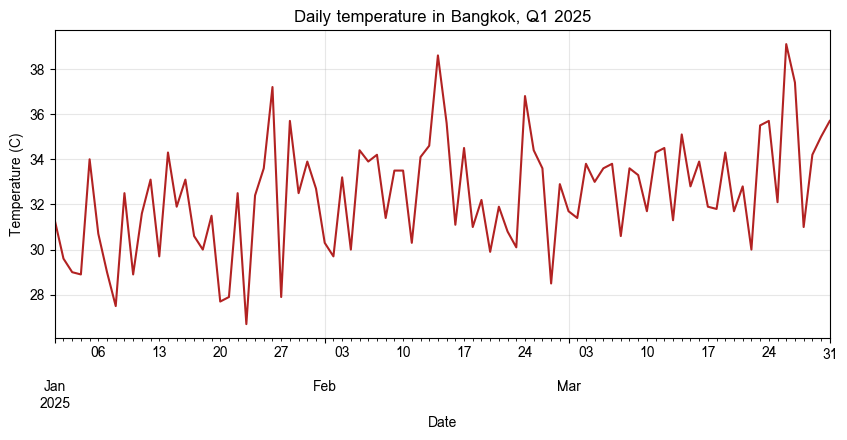

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns

# แนวปฏิบัติที่แนะนำคือสร้าง figure และ axes ขึ้นก่อน แล้วส่ง ax เข้าไปในคำสั่ง plot
bangkok = df[df["city"] == "Bangkok"].sort_values("date")

fig, ax = plt.subplots(figsize=(10, 4))
bangkok.plot(x="date", y="temperature_c", ax=ax, color="firebrick", legend=False)
ax.set_title("Daily temperature in Bangkok, Q1 2025")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (C)")
ax.grid(alpha=0.3)
plt.show()

### ตัวอย่างที่ 2 กราฟแท่งแนวตั้งและแนวนอน

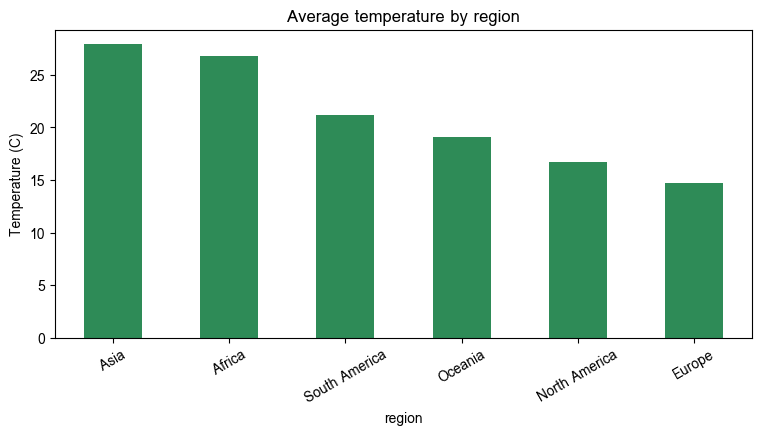

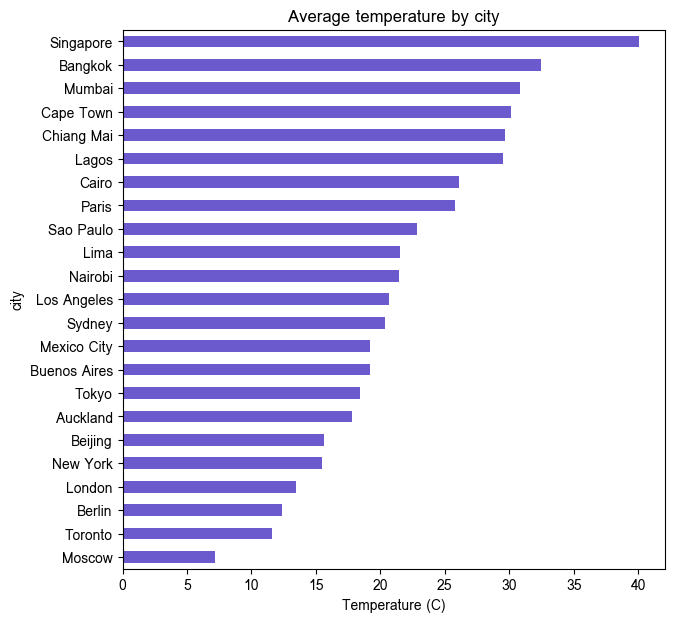

In [97]:
avg_by_region = df.groupby("region")["temperature_c"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 4))
avg_by_region.plot(kind="bar", ax=ax, color="seagreen")
ax.set_title("Average temperature by region")
ax.set_ylabel("Temperature (C)")
ax.tick_params(axis="x", rotation=30)
plt.show()

avg_by_city = df.groupby("city")["temperature_c"].mean().sort_values()
fig, ax = plt.subplots(figsize=(7, 7))
avg_by_city.plot(kind="barh", ax=ax, color="slateblue")
ax.set_title("Average temperature by city")
ax.set_xlabel("Temperature (C)")
plt.show()

### ตัวอย่างที่ 3 ฮิสโตแกรม กราฟจุด และ boxplot

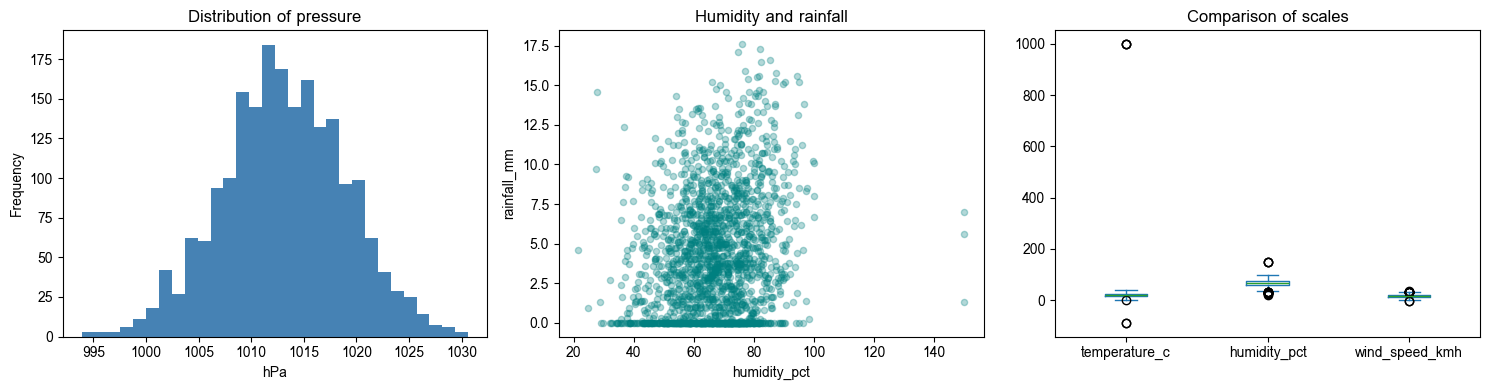

In [98]:
# การวางกราฟหลายรูปในภาพเดียว ให้สร้าง axes เป็นกริดแล้วส่งแต่ละช่องเข้าไปด้วยพารามิเตอร์ ax
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df["pressure_hpa"].plot(kind="hist", bins=30, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of pressure")
axes[0].set_xlabel("hPa")

df.plot(kind="scatter", x="humidity_pct", y="rainfall_mm", alpha=0.3, ax=axes[1], color="teal")
axes[1].set_title("Humidity and rainfall")

df[["temperature_c", "humidity_pct", "wind_speed_kmh"]].plot(kind="box", ax=axes[2])
axes[2].set_title("Comparison of scales")

plt.tight_layout()
plt.show()

### ตัวอย่างที่ 4 กราฟวงกลมและการนับสัดส่วน

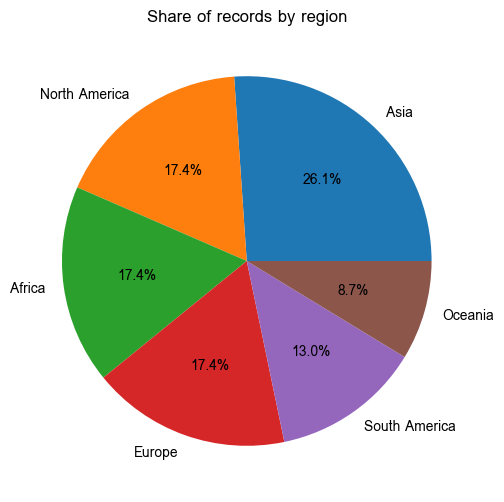

In [99]:
fig, ax = plt.subplots(figsize=(6, 6))
df["region"].value_counts().plot(kind="pie", ax=ax, autopct="%1.1f%%", ylabel="")
ax.set_title("Share of records by region")
plt.show()

### ตัวอย่างที่ 5 การวาดหลายคอลัมน์พร้อมกัน ด้วย `subplots` และ `secondary_y`

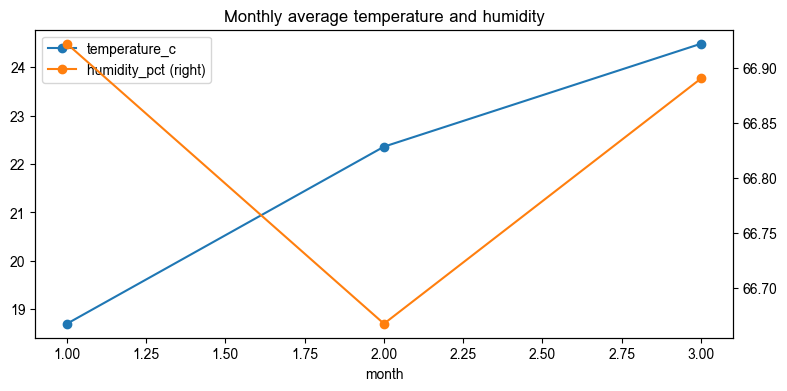

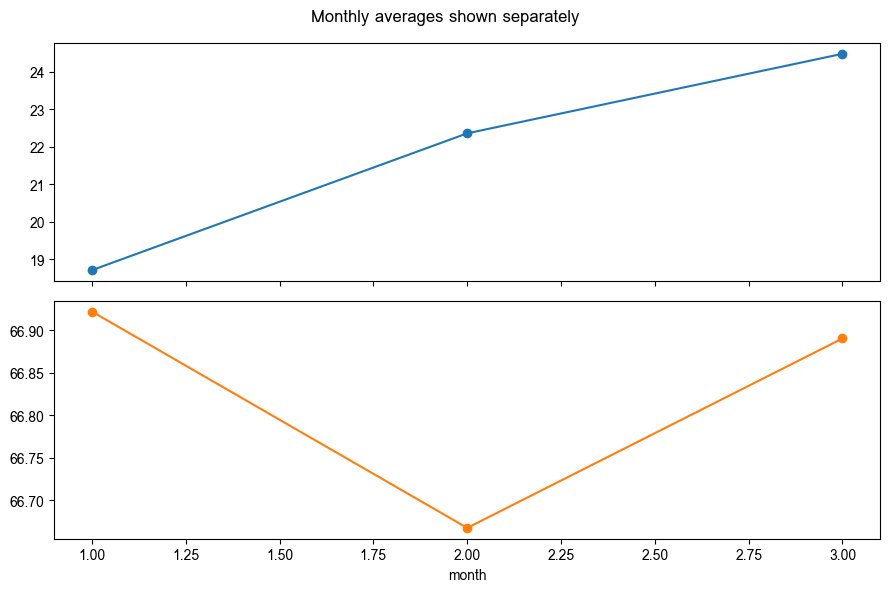

In [100]:
monthly = df.groupby("month")[["temperature_c", "humidity_pct"]].mean()

# secondary_y ใช้แกน y ด้านขวาสำหรับคอลัมน์ที่มีสเกลต่างกันมาก
fig, ax = plt.subplots(figsize=(9, 4))
monthly.plot(ax=ax, marker="o", secondary_y="humidity_pct")
ax.set_title("Monthly average temperature and humidity")
plt.show()

# subplots=True แยกแต่ละคอลัมน์ออกเป็นกราฟย่อย
axes = monthly.plot(subplots=True, layout=(2, 1), figsize=(9, 6), marker="o", legend=False)
plt.suptitle("Monthly averages shown separately")
plt.tight_layout()
plt.show()

### ตัวอย่างที่ 6 กราฟแท่งซ้อนจากตารางไขว้

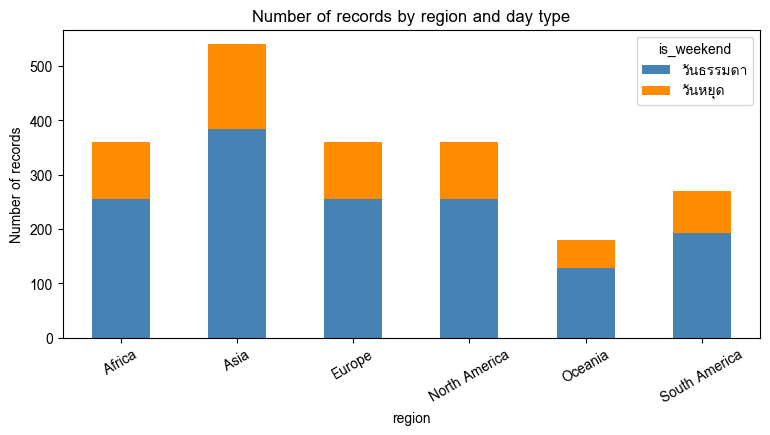

In [101]:
df["is_weekend"] = df["date"].dt.dayofweek >= 5
weekend_by_region = (df.groupby(["region", "is_weekend"]).size()
                       .unstack(fill_value=0)
                       .rename(columns={False: "วันธรรมดา", True: "วันหยุด"}))

fig, ax = plt.subplots(figsize=(9, 4))
weekend_by_region.plot(kind="bar", stacked=True, ax=ax, color=["steelblue", "darkorange"])
ax.set_title("Number of records by region and day type")
ax.set_ylabel("Number of records")
ax.tick_params(axis="x", rotation=30)
plt.show()

### ตัวอย่างที่ 7 กราฟเชิงสถิติด้วย seaborn

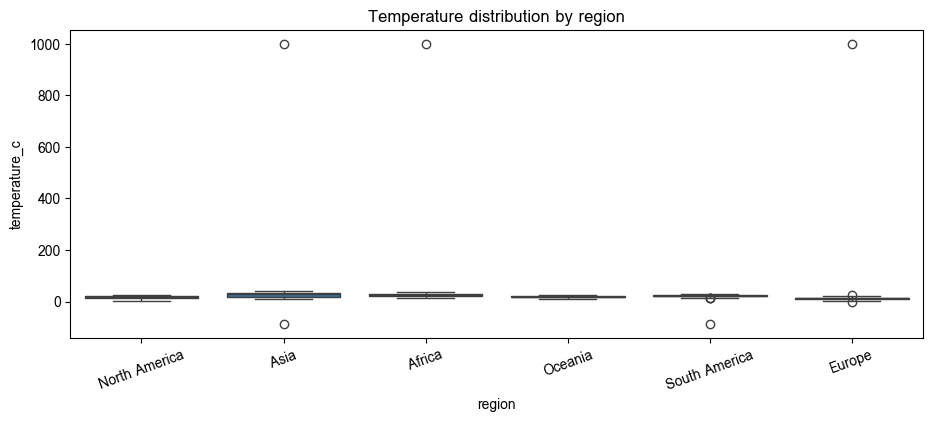

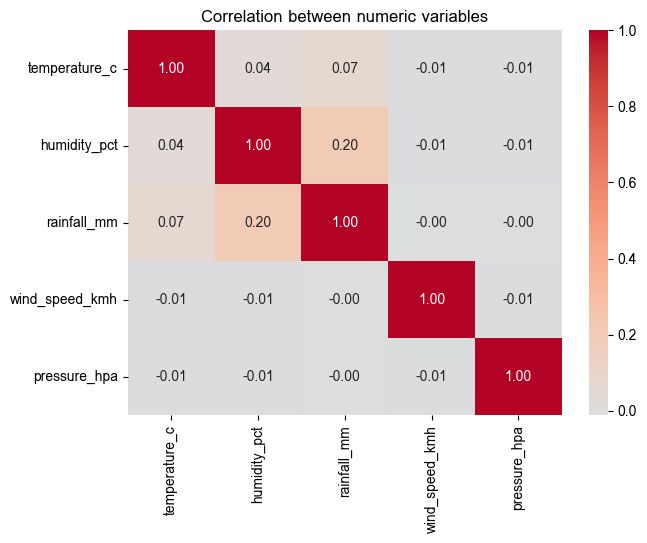

In [102]:
fig, ax = plt.subplots(figsize=(11, 4))
sns.boxplot(data=df, x="region", y="temperature_c", ax=ax)
ax.set_title("Temperature distribution by region")
ax.tick_params(axis="x", rotation=20)
plt.show()

numeric_cols = ["temperature_c", "humidity_pct", "rainfall_mm", "wind_speed_kmh", "pressure_hpa"]
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation between numeric variables")
plt.show()

### โจทย์ 17.1
สร้างกราฟสี่รูปจาก DataFrame โดยใช้ `.plot()` พร้อมกำหนดชื่อกราฟและชื่อแกนให้ครบทุกรูป

1. กราฟเส้นแสดงแนวโน้มอุณหภูมิรายวันของสามเมืองในรูปเดียวกัน พร้อมคำอธิบายสัญลักษณ์
2. กราฟแท่งแนวนอนแสดงปริมาณฝนรวมรายเมือง เรียงจากมากไปน้อย
3. ฮิสโตแกรมของ `wind_speed_kmh` โดยทดลองกำหนด `bins` สามค่าที่ต่างกันและอธิบายผลของการเลือก `bins`
4. กราฟจุดระหว่าง `population_millions` กับอุณหภูมิเฉลี่ยรายเมือง

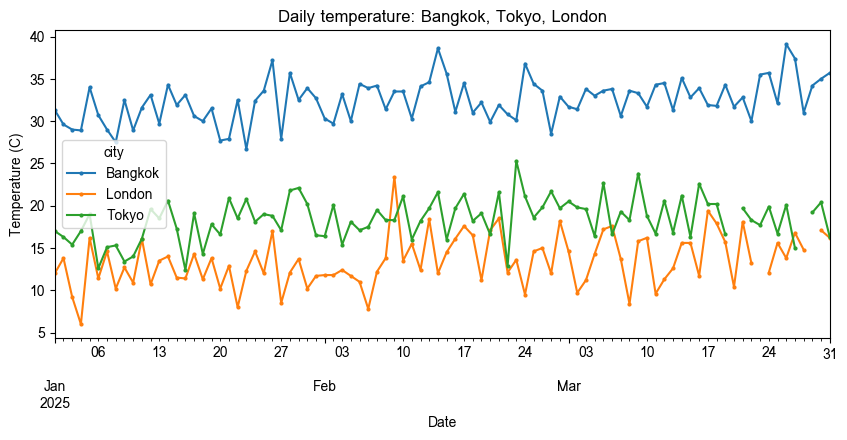

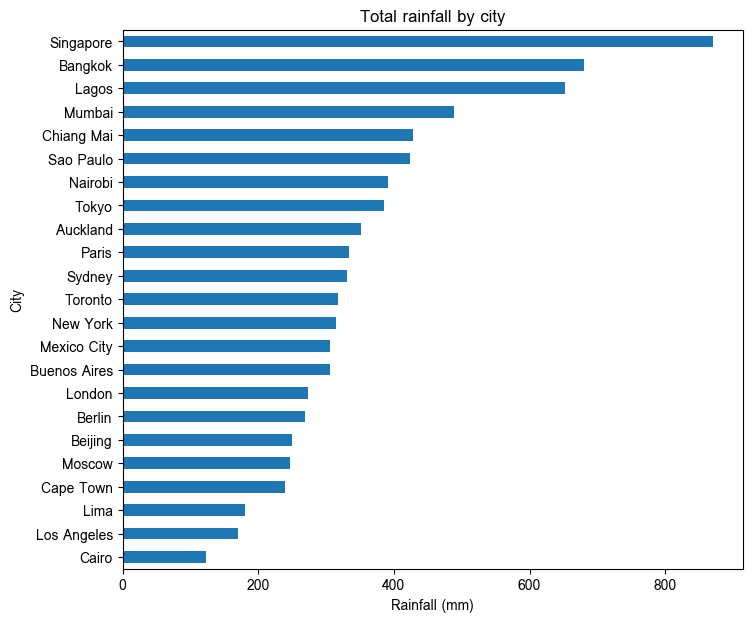

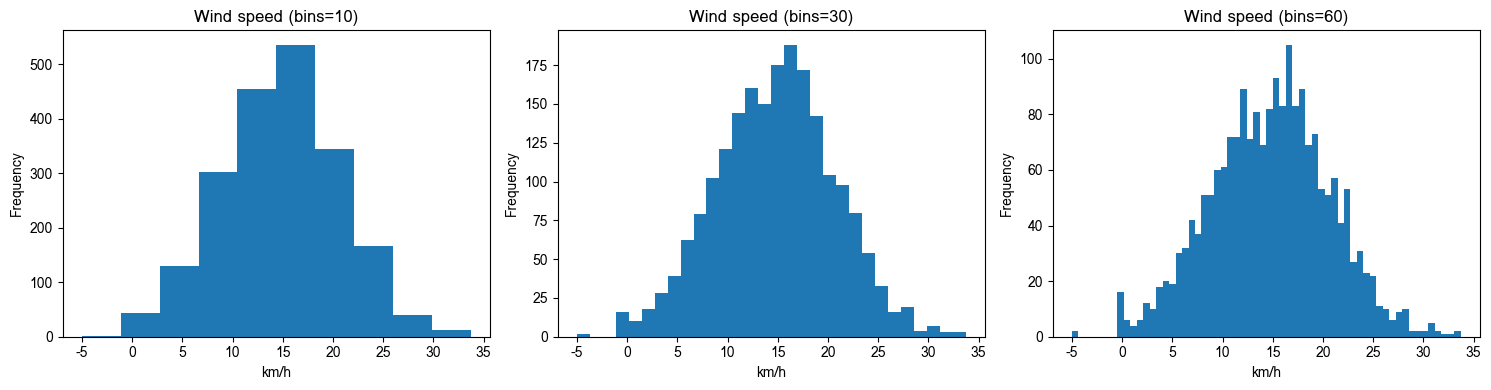

อธิบาย: bins น้อยทำให้เห็นรูปทรงโดยรวมชัดแต่รายละเอียดหาย ส่วน bins มากแสดงรายละเอียดมากขึ้นแต่กราฟอาจขรุขระและไวต่อ noise


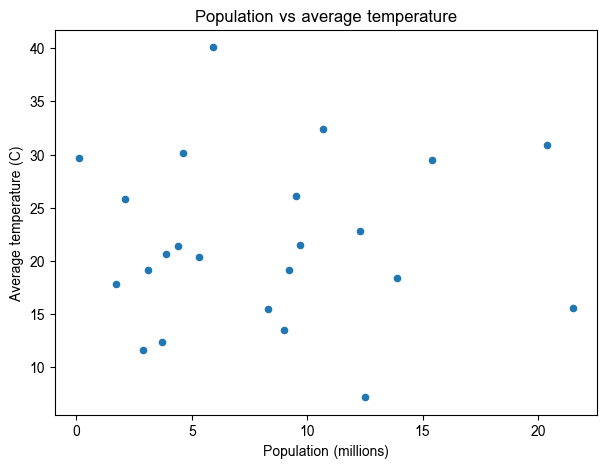

In [103]:
# คำตอบข้อ 17.1

import matplotlib.pyplot as plt

# 1) line: 3 เมือง
cities3 = [c for c in ["Bangkok", "Tokyo", "London"] if c in df["city"].unique()]
line_data = (df[df["city"].isin(cities3)]
             .pivot_table(index="date", columns="city", values="temperature_c", aggfunc="mean")
             .sort_index())
ax = line_data.plot(figsize=(10, 4), marker="o", markersize=2)
ax.set_title("Daily temperature: " + ", ".join(cities3))
ax.set_xlabel("Date"); ax.set_ylabel("Temperature (C)")
plt.show()

# 2) barh: ฝนรวมรายเมือง มากไปน้อย (barh จัดลำดับมากอยู่ด้านบนด้วย invert_yaxis)
rain_city = df.groupby("city")["rainfall_mm"].sum().sort_values(ascending=False)
ax = rain_city.plot(kind="barh", figsize=(8, 7))
ax.invert_yaxis(); ax.set_title("Total rainfall by city")
ax.set_xlabel("Rainfall (mm)"); ax.set_ylabel("City")
plt.show()

# 3) histogram ทดลอง bins 3 ค่า
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, b in zip(axes, [10, 30, 60]):
    df["wind_speed_kmh"].plot(kind="hist", bins=b, ax=ax)
    ax.set_title(f"Wind speed (bins={b})"); ax.set_xlabel("km/h"); ax.set_ylabel("Frequency")
plt.tight_layout(); plt.show()
print("อธิบาย: bins น้อยทำให้เห็นรูปทรงโดยรวมชัดแต่รายละเอียดหาย ส่วน bins มากแสดงรายละเอียดมากขึ้นแต่กราฟอาจขรุขระและไวต่อ noise")

# 4) scatter population vs avg temp
city_avg = df.groupby("city", as_index=False).agg(avg_temp=("temperature_c", "mean"), population_millions=("population_millions", "first"))
ax = city_avg.plot(kind="scatter", x="population_millions", y="avg_temp", figsize=(7, 5))
ax.set_title("Population vs average temperature")
ax.set_xlabel("Population (millions)"); ax.set_ylabel("Average temperature (C)")
plt.show()


### โจทย์ 17.2
นำผลลัพธ์ของโจทย์ 17.1 มาจัดวางในภาพเดียวกันด้วย `plt.subplots(2, 2)` พร้อมกำหนดชื่อรวมของภาพด้วย `plt.suptitle()`

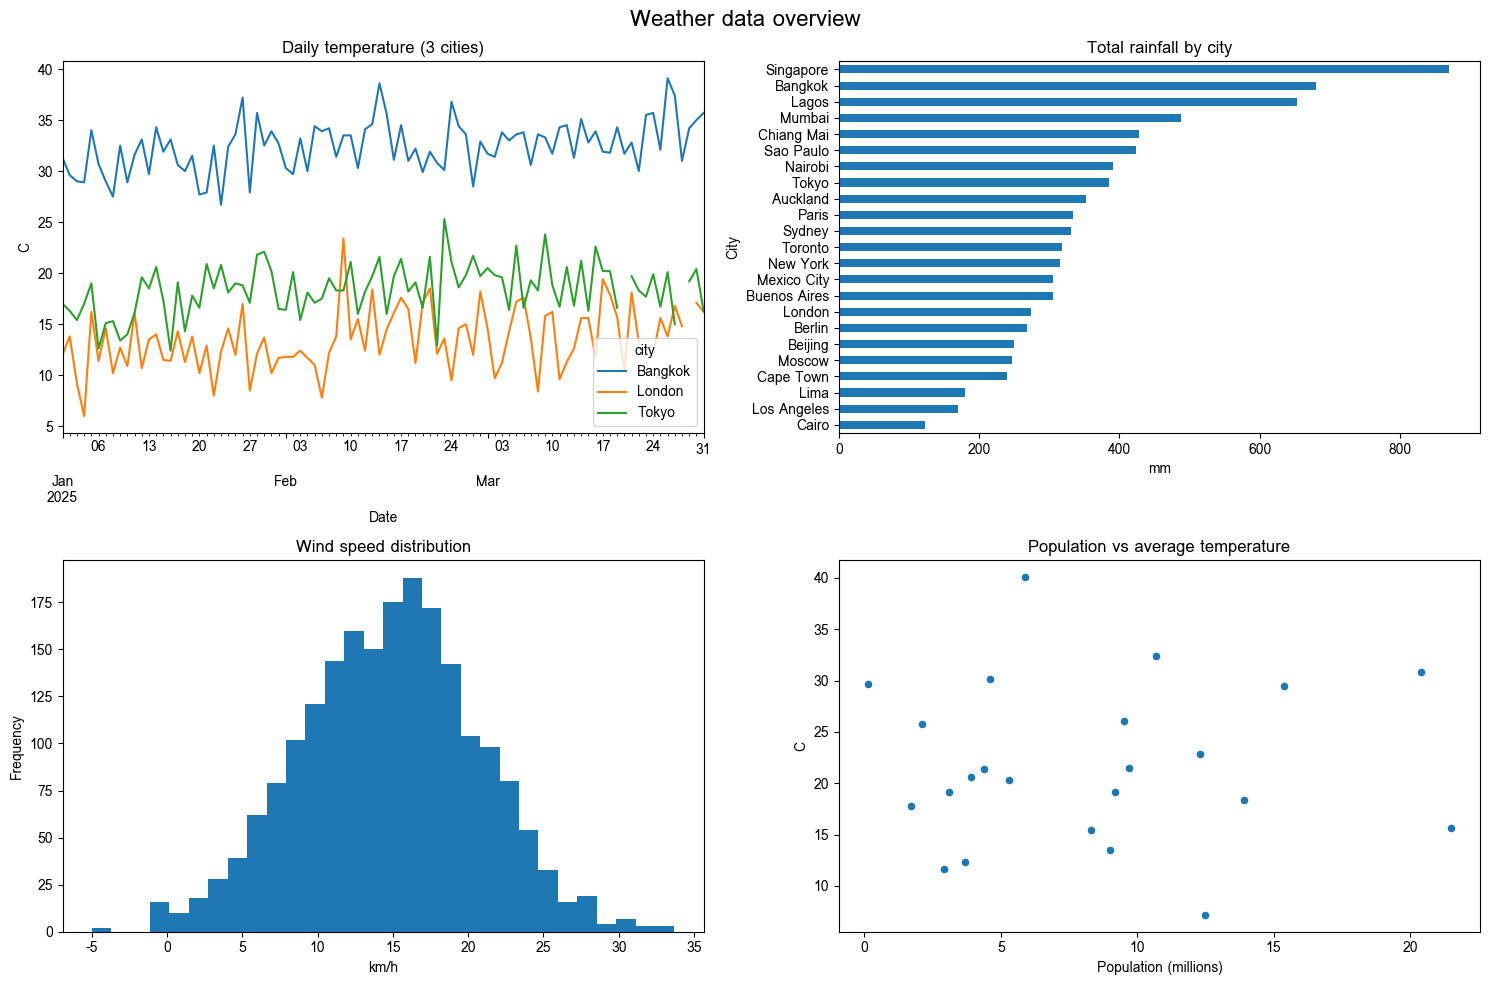

In [104]:
# คำตอบข้อ 17.2

cities3 = [c for c in ["Bangkok", "Tokyo", "London"] if c in df["city"].unique()]
line_data = (df[df["city"].isin(cities3)]
             .pivot_table(index="date", columns="city", values="temperature_c", aggfunc="mean")
             .sort_index())
rain_city = df.groupby("city")["rainfall_mm"].sum().sort_values(ascending=False)
city_avg = df.groupby("city", as_index=False).agg(avg_temp=("temperature_c", "mean"), population_millions=("population_millions", "first"))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
line_data.plot(ax=axes[0,0]); axes[0,0].set_title("Daily temperature (3 cities)"); axes[0,0].set_xlabel("Date"); axes[0,0].set_ylabel("C")
rain_city.plot(kind="barh", ax=axes[0,1]); axes[0,1].invert_yaxis(); axes[0,1].set_title("Total rainfall by city"); axes[0,1].set_xlabel("mm"); axes[0,1].set_ylabel("City")
df["wind_speed_kmh"].plot(kind="hist", bins=30, ax=axes[1,0]); axes[1,0].set_title("Wind speed distribution"); axes[1,0].set_xlabel("km/h"); axes[1,0].set_ylabel("Frequency")
city_avg.plot(kind="scatter", x="population_millions", y="avg_temp", ax=axes[1,1]); axes[1,1].set_title("Population vs average temperature"); axes[1,1].set_xlabel("Population (millions)"); axes[1,1].set_ylabel("C")
plt.suptitle("Weather data overview", fontsize=16)
plt.tight_layout(); plt.show()


### โจทย์ 17.3
สร้างกราฟแท่งซ้อนแสดงจำนวนวันในแต่ละช่วงปริมาณฝน โดยแบ่งช่วงด้วย `pd.cut()` และจำแนกตามภูมิภาค
จากนั้นสร้างกราฟแบบ `stacked=False` เปรียบเทียบ
**อธิบาย:** กราฟแท่งซ้อนเหมาะสมกว่าในกรณีใด และกราฟแท่งเรียงข้างกันเหมาะสมกว่าในกรณีใด

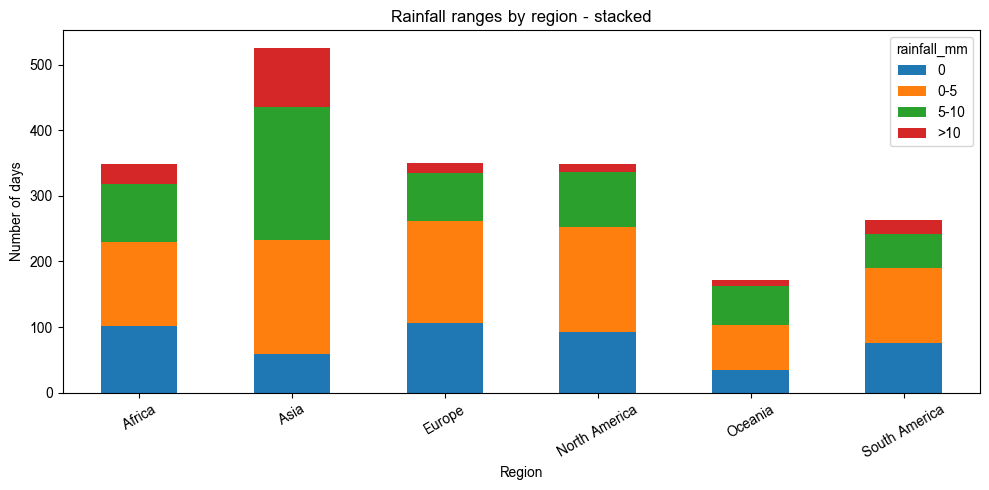

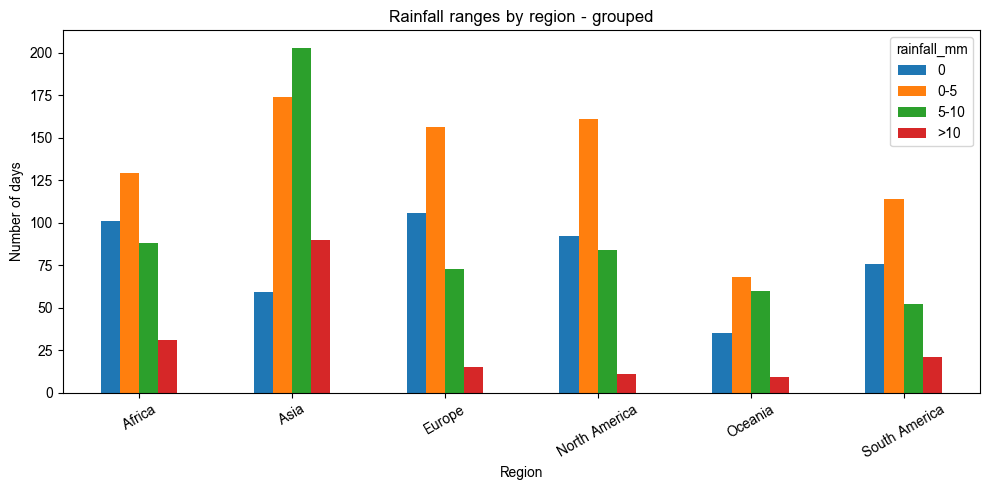

อธิบาย: stacked เหมาะเมื่อเน้นทั้งยอดรวมและองค์ประกอบของแต่ละภูมิภาคในพื้นที่กราฟจำกัด ส่วน grouped เหมาะเมื่ออยากเปรียบเทียบค่าของแต่ละช่วงฝนระหว่างภูมิภาคโดยตรง เพราะแท่งใช้ baseline เดียวกันจึงอ่านความต่างง่ายกว่า


In [105]:
# คำตอบข้อ 17.3

rain_bin = pd.cut(df["rainfall_mm"], bins=[-np.inf, 0, 5, 10, np.inf], labels=["0", "0-5", "5-10", ">10"])
rain_region = pd.crosstab(df["region"], rain_bin)

ax = rain_region.plot(kind="bar", stacked=True, figsize=(10, 5))
ax.set_title("Rainfall ranges by region - stacked"); ax.set_xlabel("Region"); ax.set_ylabel("Number of days")
plt.xticks(rotation=30); plt.tight_layout(); plt.show()

ax = rain_region.plot(kind="bar", stacked=False, figsize=(10, 5))
ax.set_title("Rainfall ranges by region - grouped"); ax.set_xlabel("Region"); ax.set_ylabel("Number of days")
plt.xticks(rotation=30); plt.tight_layout(); plt.show()
print("อธิบาย: stacked เหมาะเมื่อเน้นทั้งยอดรวมและองค์ประกอบของแต่ละภูมิภาคในพื้นที่กราฟจำกัด ส่วน grouped เหมาะเมื่ออยากเปรียบเทียบค่าของแต่ละช่วงฝนระหว่างภูมิภาคโดยตรง เพราะแท่งใช้ baseline เดียวกันจึงอ่านความต่างง่ายกว่า")


### โจทย์ 17.4
สร้างกราฟด้วย seaborn สองรูป ได้แก่ boxplot ของ `rainfall_mm` จำแนกตามภูมิภาคและแยกสีตาม `is_weekend`
และ heatmap ของสหสัมพันธ์ระหว่าง `temperature_c`, `humidity_pct`, `rainfall_mm` และ `population_millions`
พร้อมตีความผลที่ได้เป็นข้อความ

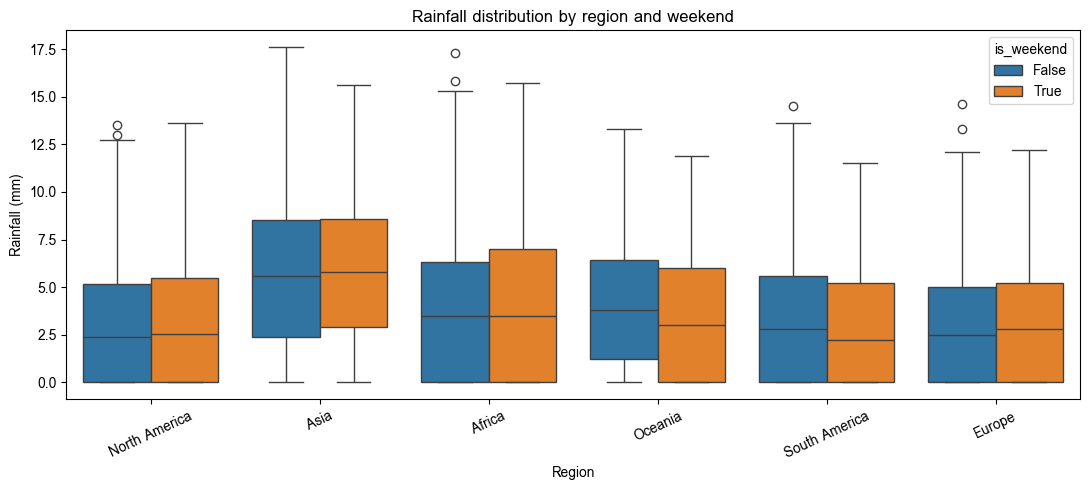

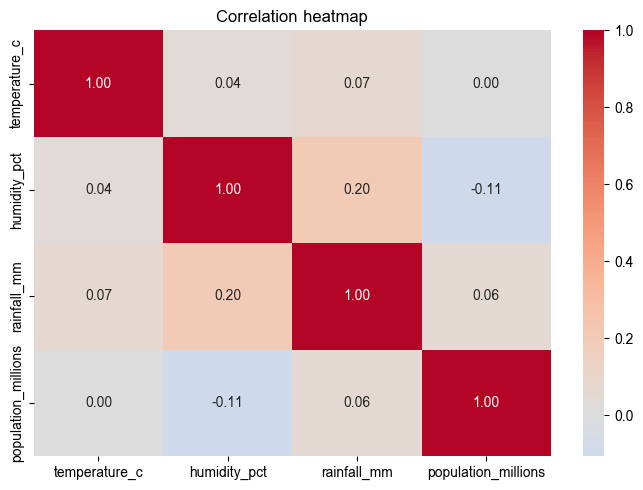

ค่ามัธยฐานฝนเพื่อช่วยตีความ boxplot


is_weekend,False,True
region,,
Africa,3.5,3.50
Asia,5.6,5.80
Europe,2.5,2.80
North America,2.4,2.55
Oceania,3.8,3.00
South America,2.8,2.25


ค่าสหสัมพันธ์


,temperature_c,humidity_pct,rainfall_mm,population_millions
temperature_c,1.000,0.038,0.068,0.003
humidity_pct,0.038,1.000,0.199,-0.106
rainfall_mm,0.068,0.199,1.000,0.061
population_millions,0.003,-0.106,0.061,1.000


ตีความ: boxplot ใช้ดูความแตกต่างของค่ากลาง การกระจาย และ outlier ของฝนระหว่างภูมิภาค/วันธรรมดากับวันหยุด ส่วน heatmap แสดงความสัมพันธ์เชิงเส้น โดยค่าใกล้ 1 หรือ -1 หมายถึงสัมพันธ์มากและค่าใกล้ 0 หมายถึงสัมพันธ์เชิงเส้นน้อย ทั้งนี้ correlation ไม่ได้ยืนยันเหตุและผล


In [106]:
# คำตอบข้อ 17.4

import seaborn as sns

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df, x="region", y="rainfall_mm", hue="is_weekend", ax=ax)
ax.set_title("Rainfall distribution by region and weekend")
ax.set_xlabel("Region"); ax.set_ylabel("Rainfall (mm)"); ax.tick_params(axis="x", rotation=25)
plt.tight_layout(); plt.show()

corr_cols = ["temperature_c", "humidity_pct", "rainfall_mm", "population_millions"]
corr = df[corr_cols].corr()
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", center=0, cmap="coolwarm", ax=ax)
ax.set_title("Correlation heatmap")
plt.tight_layout(); plt.show()

med = df.groupby(["region", "is_weekend"])["rainfall_mm"].median().unstack().round(2)
print("ค่ามัธยฐานฝนเพื่อช่วยตีความ boxplot")
display(med)
print("ค่าสหสัมพันธ์")
display(corr.round(3))
print("ตีความ: boxplot ใช้ดูความแตกต่างของค่ากลาง การกระจาย และ outlier ของฝนระหว่างภูมิภาค/วันธรรมดากับวันหยุด ส่วน heatmap แสดงความสัมพันธ์เชิงเส้น โดยค่าใกล้ 1 หรือ -1 หมายถึงสัมพันธ์มากและค่าใกล้ 0 หมายถึงสัมพันธ์เชิงเส้นน้อย ทั้งนี้ correlation ไม่ได้ยืนยันเหตุและผล")


---
## ข้อ 18 โจทย์ประยุกต์รวม

ให้ใช้ตารางที่รวมข้อมูลจากทั้ง 3 แหล่งและผ่านการทำความสะอาดแล้ว ตอบคำถามต่อไปนี้
แต่ละข้อต้องประกอบด้วย **ตารางหรือกราฟหนึ่งชิ้น** และ **ข้อสรุปเป็นข้อความสั้น ๆ**

**ข้อกำหนดเพิ่มเติม**

- ให้เขียนโปรแกรมในรูปแบบลำดับต่อเนื่องที่อ่านเข้าใจได้ ไม่ใช้ตัวแปรชั่วคราวจำนวนมากโดยไม่จำเป็น
- ห้ามใช้การวนซ้ำทีละแถว
- หากข้อสรุปขึ้นอยู่กับวิธีจัดการค่าว่างหรือค่าผิดปกติ ให้ระบุวิธีที่เลือกใช้ไว้ด้วย

1. ภูมิภาคใดมีสภาพอากาศแปรปรวนมากที่สุดในไตรมาสแรก เมื่อวัดจากส่วนเบี่ยงเบนมาตรฐานของอุณหภูมิรายวัน
   และความแปรปรวนดังกล่าวเกิดจากทุกเมืองในภูมิภาคนั้นเท่ากันหรือเกิดจากเมืองใดเมืองหนึ่งเป็นหลัก

,std_temp
region,
Asia,7.160363
Africa,4.884828
North America,4.521662
Europe,4.069546
Oceania,3.078532
South America,3.057691


,std_temp_in_top_region
city,
Beijing,2.874792
Chiang Mai,2.859373
Singapore,2.707959
Mumbai,2.544968
Tokyo,2.518006
Bangkok,2.490462


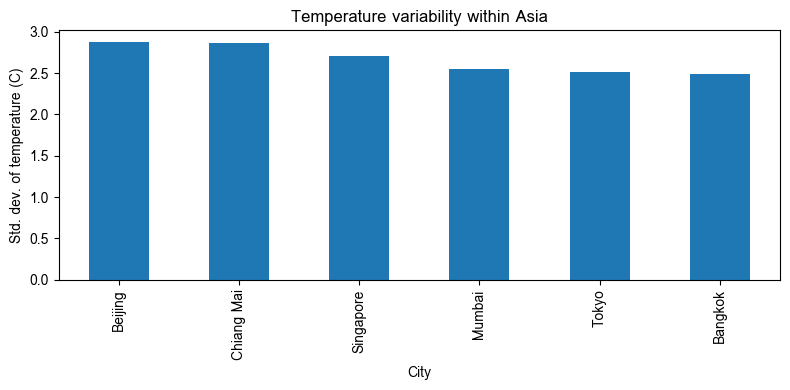

สรุป: ภูมิภาคที่แปรปรวนมากที่สุดคือ Asia (SD=7.16). ภายในภูมิภาคนี้เมืองที่แปรปรวนที่สุดคือ Beijing (SD=2.87) จึงควรดูระดับเมืองประกอบ ไม่สรุปจากค่า region อย่างเดียว


In [107]:
# คำตอบข้อ 18.1

analysis_df = df.assign(
    temperature_c=df["temperature_c"].where(df["temperature_c"].between(-60, 60)),
    humidity_pct=df["humidity_pct"].where(df["humidity_pct"].between(0, 100))
)
q1 = analysis_df[analysis_df["date"].dt.quarter == 1]
region_var = q1.groupby("region")["temperature_c"].std().sort_values(ascending=False)
most_var_region = region_var.index[0]
city_var = (q1[q1["region"] == most_var_region]
            .groupby("city")["temperature_c"].std()
            .sort_values(ascending=False))

display(region_var.rename("std_temp").to_frame())
display(city_var.rename("std_temp_in_top_region").to_frame())
ax = city_var.plot(kind="bar", figsize=(8,4), title=f"Temperature variability within {most_var_region}")
ax.set_xlabel("City"); ax.set_ylabel("Std. dev. of temperature (C)"); plt.tight_layout(); plt.show()
print(f"สรุป: ภูมิภาคที่แปรปรวนมากที่สุดคือ {most_var_region} (SD={region_var.iloc[0]:.2f}). ภายในภูมิภาคนี้เมืองที่แปรปรวนที่สุดคือ {city_var.index[0]} (SD={city_var.iloc[0]:.2f}) จึงควรดูระดับเมืองประกอบ ไม่สรุปจากค่า region อย่างเดียว")


2. เมืองที่มีฝนตกหนักบ่อยที่สุด 5 อันดับแรกเมื่อวัดด้วยสัดส่วน ให้เปรียบเทียบกับผลที่ได้เมื่อวัดด้วยจำนวนวัน
   และอธิบายว่าเหตุใดจึงให้ผลต่างกัน

Top 5 ตามจำนวนวัน


,heavy_days,valid_days,heavy_pct
city,,,
Singapore,44,90,48.888889
Bangkok,23,87,26.436782
Lagos,22,88,25.000000
Sao Paulo,11,88,12.500000
Buenos Aires,9,88,10.227273


Top 5 ตามสัดส่วน


,heavy_days,valid_days,heavy_pct
city,,,
Singapore,44,90,48.888889
Bangkok,23,87,26.436782
Lagos,22,88,25.000000
Sao Paulo,11,88,12.500000
Chiang Mai,9,85,10.588235


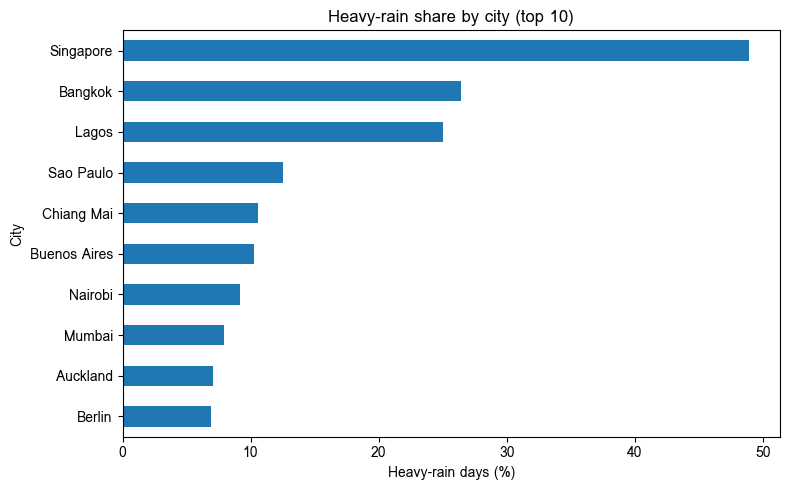

สรุป: การวัดด้วยจำนวนวันอาจให้ผลต่างจากสัดส่วนเมื่อจำนวนวันที่มีข้อมูลของแต่ละเมืองไม่เท่ากัน สัดส่วนจึงเหมาะกว่าในการเปรียบเทียบความถี่ระหว่างเมือง ส่วนจำนวนวันเหมาะกับการรายงานจำนวนเหตุการณ์จริง


In [108]:
# คำตอบข้อ 18.2

heavy = (analysis_df.groupby("city")["rainfall_mm"]
         .agg(heavy_days=lambda s: (s > 10).sum(), valid_days="count"))
heavy["heavy_pct"] = heavy["heavy_days"] / heavy["valid_days"] * 100
by_count = heavy.nlargest(5, "heavy_days")
by_pct = heavy.nlargest(5, "heavy_pct")

print("Top 5 ตามจำนวนวัน"); display(by_count)
print("Top 5 ตามสัดส่วน"); display(by_pct)
ax = heavy.sort_values("heavy_pct").tail(10)["heavy_pct"].plot(kind="barh", figsize=(8,5), title="Heavy-rain share by city (top 10)")
ax.set_xlabel("Heavy-rain days (%)"); ax.set_ylabel("City"); plt.tight_layout(); plt.show()
print("สรุป: การวัดด้วยจำนวนวันอาจให้ผลต่างจากสัดส่วนเมื่อจำนวนวันที่มีข้อมูลของแต่ละเมืองไม่เท่ากัน สัดส่วนจึงเหมาะกว่าในการเปรียบเทียบความถี่ระหว่างเมือง ส่วนจำนวนวันเหมาะกับการรายงานจำนวนเหตุการณ์จริง")


3. จำนวนประชากรของเมืองมีความสัมพันธ์กับอุณหภูมิหรือปริมาณฝนหรือไม่
   ให้คำนวณค่าสหสัมพันธ์ประกอบ พร้อมระบุข้อควรระวังในการตีความอย่างน้อยหนึ่งประการ

,city,population_millions,avg_temp,total_rain
0,Auckland,1.70,17.804444,351.9
1,Bangkok,10.70,32.438889,680.0
2,Beijing,21.50,15.598876,250.1
3,Berlin,3.70,12.383146,268.4
4,Buenos Aires,3.10,20.389773,305.1
5,Cairo,9.50,26.070455,122.4
6,Cape Town,4.60,19.153409,239.3
7,Chiang Mai,0.13,29.650000,428.1
8,Lagos,15.40,29.494253,652.8
9,Lima,9.70,21.490000,180.3


corr(population, avg_temp) = 0.159
corr(population, total_rain) = 0.128


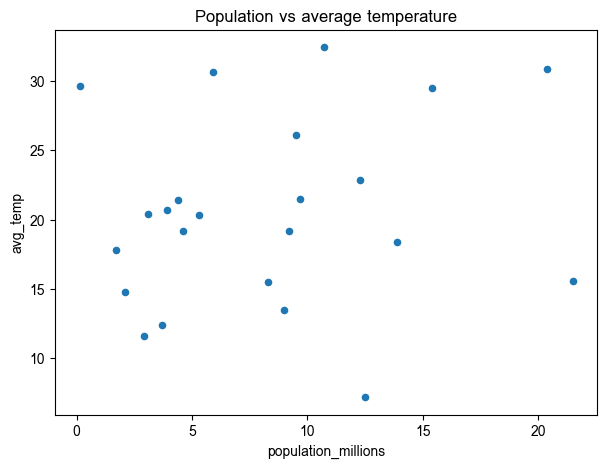

สรุป: พิจารณาขนาดและทิศทางของค่าสหสัมพันธ์ข้างต้น ไม่ควรตีความว่า population เป็นสาเหตุของอุณหภูมิหรือฝน เพราะ correlation ไม่ใช่ causation และมีตัวแปรแทรกซ้อน เช่น latitude, altitude, climate zone อีกทั้งตัวอย่างมีจำนวนเมืองจำกัด


In [109]:
# คำตอบข้อ 18.3

# ใช้หนึ่งแถวต่อเมือง เพื่อไม่ให้น้ำหนักเมืองจากข้อมูลรายวันซ้ำ 90 ครั้ง
city_corr = (analysis_df.groupby("city", as_index=False)
             .agg(population_millions=("population_millions", "first"),
                  avg_temp=("temperature_c", "mean"),
                  total_rain=("rainfall_mm", "sum")))
corr_pop_temp = city_corr["population_millions"].corr(city_corr["avg_temp"])
corr_pop_rain = city_corr["population_millions"].corr(city_corr["total_rain"])

display(city_corr)
print(f"corr(population, avg_temp) = {corr_pop_temp:.3f}")
print(f"corr(population, total_rain) = {corr_pop_rain:.3f}")
fig, ax = plt.subplots(figsize=(7,5))
city_corr.plot(kind="scatter", x="population_millions", y="avg_temp", ax=ax)
ax.set_title("Population vs average temperature"); plt.show()
print("สรุป: พิจารณาขนาดและทิศทางของค่าสหสัมพันธ์ข้างต้น ไม่ควรตีความว่า population เป็นสาเหตุของอุณหภูมิหรือฝน เพราะ correlation ไม่ใช่ causation และมีตัวแปรแทรกซ้อน เช่น latitude, altitude, climate zone อีกทั้งตัวอย่างมีจำนวนเมืองจำกัด")



4. เดือนใดของแต่ละภูมิภาคที่ควรหลีกเลี่ยงการเดินทางมากที่สุด
   ให้กำหนดเกณฑ์การตัดสินใจจากข้อมูลที่มีอยู่ และอธิบายเหตุผลของการเลือกเกณฑ์ดังกล่าว

,region,month,heavy_rain_pct,strong_wind_pct,extreme_temp_pct,risk_score
0,Africa,1,0.097,0.032,0.008,4.570
4,Asia,2,0.226,0.018,0.024,8.929
6,Europe,1,0.032,0.024,0.387,14.785
9,North America,1,0.032,0.024,0.145,6.720
14,Oceania,3,0.097,0.000,0.000,3.226
16,South America,2,0.083,0.036,0.000,3.968


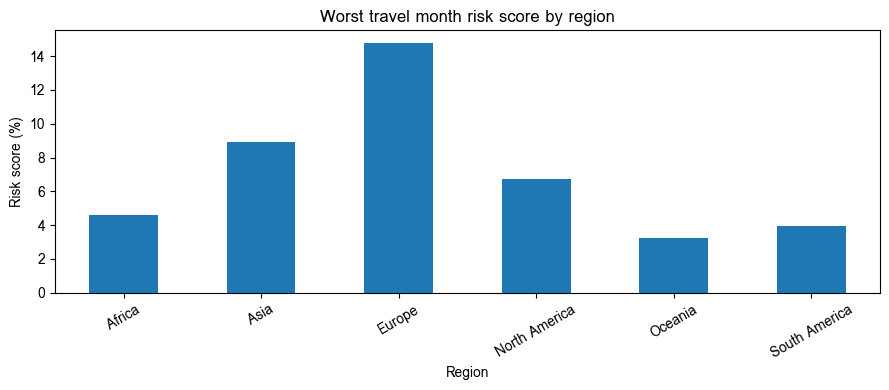

สรุป: กำหนด risk score เป็นค่าเฉลี่ยของสัดส่วนวันฝนหนัก (>10 mm), วันลมแรง (>25 km/h) และวันอุณหภูมิสุดขั้ว (<10 หรือ >35 C) เพราะทั้งสามปัจจัยกระทบความสะดวกและความปลอดภัยในการเดินทาง เกณฑ์นี้เป็นเกณฑ์ที่กำหนดเพื่อเปรียบเทียบภายในชุดข้อมูล ไม่ใช่มาตรฐานการท่องเที่ยวสากล


In [110]:
# คำตอบข้อ 18.4

# เกณฑ์: เดือนที่ควรหลีกเลี่ยง = มีสัดส่วนวันฝนหนัก + วันลมแรง + วันอุณหภูมิสุดขั้วสูง
travel = analysis_df.assign(
    heavy_rain=analysis_df["rainfall_mm"] > 10,
    strong_wind=analysis_df["wind_speed_kmh"] > 25,
    extreme_temp=(analysis_df["temperature_c"] < 10) | (analysis_df["temperature_c"] > 35)
)
monthly_risk = (travel.groupby(["region", "month"], as_index=False)
                .agg(heavy_rain_pct=("heavy_rain", "mean"),
                     strong_wind_pct=("strong_wind", "mean"),
                     extreme_temp_pct=("extreme_temp", "mean")))
monthly_risk["risk_score"] = monthly_risk[["heavy_rain_pct", "strong_wind_pct", "extreme_temp_pct"]].mean(axis=1) * 100
worst_idx = monthly_risk.groupby("region")["risk_score"].idxmax()
worst_month = monthly_risk.loc[worst_idx].sort_values("region")

display(worst_month.round(3))
ax = worst_month.set_index("region")["risk_score"].plot(kind="bar", figsize=(9,4), title="Worst travel month risk score by region")
ax.set_ylabel("Risk score (%)"); ax.set_xlabel("Region"); plt.xticks(rotation=30); plt.tight_layout(); plt.show()
print("สรุป: กำหนด risk score เป็นค่าเฉลี่ยของสัดส่วนวันฝนหนัก (>10 mm), วันลมแรง (>25 km/h) และวันอุณหภูมิสุดขั้ว (<10 หรือ >35 C) เพราะทั้งสามปัจจัยกระทบความสะดวกและความปลอดภัยในการเดินทาง เกณฑ์นี้เป็นเกณฑ์ที่กำหนดเพื่อเปรียบเทียบภายในชุดข้อมูล ไม่ใช่มาตรฐานการท่องเที่ยวสากล")


---

<center>จบแล้ว ขอแสดงความยินดีกับทุกคน

<center>> เขียนเองหนึ่งบรรทัด ได้ความเข้าใจมากกว่าอ่านผ่านตาสิบบรรทัด
> One line you write yourself teaches more than ten you only read.

> คนที่จัดการข้อมูลสองพันแถวได้อย่างสะอาดหมดจด คือคนเดียวกับที่จะจัดการข้อมูลสองล้านแถวได้อย่างมั่นใจ
> Whoever handles two thousand rows with care will handle two million with confidence.

<center>❤️❤️❤️❤️❤️ Keep Learning ❤️❤️❤️❤️❤️